# Retrieval-Oriented Oracle Headroom

This notebook estimates the retrieval headroom of budget-constrained dialogue-history selection over recency truncation. On a conversation-disjoint, depth-balanced TopiOCQA sample, candidate histories are rewritten with frozen IterCQR and evaluated with BM25 across B64, B128, B256, and B512. Here $q_t$ is the current query, $H_t$ its history, $h=t-1$ the history depth, and $B$ the total T5 input budget. The `recency` condition is the thesis baseline route $I_B$. Per-query values in the code column `MRR` are reciprocal ranks ($\mathrm{RR}$); their mean across queries is $\mathrm{MRR}$.

### Runtime and experiment setup

Loads the numerical, plotting, PyTorch, and ROCC components required for the oracle analysis. The project root is resolved automatically, persistent result and SQLite cache directories are created, and shared helpers configure progress reporting and deterministic random seeds. Computation uses CUDA when available and otherwise falls back to CPU.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import random
import sys
from collections import Counter
from dataclasses import asdict, replace
from pathlib import Path
from typing import Any, Iterable, Mapping, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from tqdm.auto import tqdm


def resolve_project_root(start: Path) -> Path:
    configured = os.environ.get("ROCC_ROOT") or os.environ.get("MASTER_THESIS_PROJECT_ROOT")
    if configured:
        candidate = Path(configured).expanduser().resolve()
        if not (candidate / "experiments" / "rocc").is_dir():
            raise FileNotFoundError(f"Configured ROCC checkout is missing: {candidate}")
        return candidate
    for candidate in (start, *start.parents):
        if (candidate / "experiments" / "rocc").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Open this notebook from your ROCC checkout, or set ROCC_ROOT to it. "
        "In Colab, first clone the public repository over HTTPS or authenticate "
        "your own private checkout; no private clone or deploy key is assumed."
    )


PROJECT_ROOT = resolve_project_root(Path.cwd())
os.environ["MASTER_THESIS_PROJECT_ROOT"] = str(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from experiments.rocc import (
    TURN_SELECTION_GENERATOR_FAMILIES,
    CachedIterCQRBM25Config,
    CachedIterCQRBM25Pipeline,
    TurnSelectionCandidateConfig,
    add_conversation_columns,
    build_depth_eligible_population,
    generate_turn_selection_candidates,
    load_itercqr_dataloaders,
    make_candidate_dataloader,
    select_depth_balanced_population,
    stable_sha1,
)

SHOW_PROGRESS = True
RESULT_DIR = PROJECT_ROOT / "experiments" / "results" / "03_oracle_headroom_analysis"
CACHE_DIR = PROJECT_ROOT / ".cache" / "master_thesis" / "03_oracle_headroom_analysis"
CACHE_DB_PATH = CACHE_DIR / "runtime_cache.sqlite3"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_PROTOCOL = "nb03_oracle_headroom_analysis_v2"
FINAL_MANIFEST_PATH = RESULT_DIR / "manifest.json"
POPULATION_IDS_PATH = RESULT_DIR / "population_ids.txt"
RESULT_FRAME_PATHS = {
    "train_population_summary": RESULT_DIR / "train_population_summary.csv",
    "population": RESULT_DIR / "population.csv",
    "sampling_summary": RESULT_DIR / "sampling_summary.csv",
    "generator_coverage": RESULT_DIR / "generator_coverage.csv",
    "entity_anchor_summary": RESULT_DIR / "entity_anchor_summary.csv",
    "serialization_summary": RESULT_DIR / "serialization_summary.csv",
    "cache_summary": RESULT_DIR / "cache_summary.csv",
    "dedup_summary": RESULT_DIR / "dedup_summary.csv",
    "budget_degradation": RESULT_DIR / "budget_degradation.csv",
    "space_oracle_summary": RESULT_DIR / "space_oracle_summary.csv",
    "control_relation_summary": RESULT_DIR / "control_relation_summary.csv",
    "control_relation_depth_summary": (
        RESULT_DIR / "control_relation_depth_summary.csv"
    ),
    "generator_summary": RESULT_DIR / "generator_summary.csv",
    "adaptive_null_refill_status": (
        RESULT_DIR / "adaptive_null_refill_status.csv"
    ),
    "refill_summary": RESULT_DIR / "refill_summary.csv",
    "mc_summary_all_budgets": RESULT_DIR / "mc_summary_all_budgets.csv",
    "bootstrap_summary": RESULT_DIR / "bootstrap_summary.csv",
    "topic_switch_bootstrap_summary": (
        RESULT_DIR / "topic_switch_bootstrap_summary.csv"
    ),
}


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(1024 * 1024):
            digest.update(chunk)
    return digest.hexdigest()


def sha256_text(value: str) -> str:
    return hashlib.sha256(value.encode("utf-8")).hexdigest()


def frame_sha256(frame: pd.DataFrame, *, sort_by: Sequence[str]) -> str:
    ordered = frame.sort_values(list(sort_by), kind="mergesort").reset_index(
        drop=True
    )
    payload = ordered.to_json(
        orient="split",
        index=False,
        date_format="iso",
        double_precision=15,
        force_ascii=False,
    )
    return sha256_text(payload)


def write_json(path: Path, value: Mapping[str, Any]) -> None:
    temporary = path.with_name(f".{path.name}.tmp")
    temporary.write_text(
        json.dumps(
            value,
            ensure_ascii=False,
            indent=2,
            sort_keys=True,
        )
        + "\n",
        encoding="utf-8",
    )
    temporary.replace(path)


def write_frame(path: Path, frame: pd.DataFrame) -> None:
    temporary = path.with_name(f".{path.name}.tmp")
    frame.to_csv(
        temporary,
        index=False,
        float_format="%.17g",
        lineterminator="\n",
    )
    temporary.replace(path)


def write_population_ids(path: Path, sample_ids: Sequence[str]) -> None:
    temporary = path.with_name(f".{path.name}.tmp")
    temporary.write_text(
        "\n".join(map(str, sample_ids)) + "\n",
        encoding="utf-8",
    )
    temporary.replace(path)


def load_result_frame(name: str) -> pd.DataFrame:
    return pd.read_csv(RESULT_FRAME_PATHS[name])


def load_complete_analysis_manifest(
    expected_identity: Mapping[str, Any],
) -> dict[str, Any] | None:
    if not FINAL_MANIFEST_PATH.is_file():
        return None
    manifest = json.loads(
        FINAL_MANIFEST_PATH.read_text(encoding="utf-8")
    )
    if manifest.get("schema_version") != 1:
        raise RuntimeError("The existing NB03 manifest schema drifted.")
    if manifest.get("protocol") != ANALYSIS_PROTOCOL:
        return None
    if manifest.get("complete") is not True:
        raise RuntimeError("The existing NB03 manifest is incomplete.")
    if manifest.get("identity") != dict(expected_identity):
        raise RuntimeError("The existing NB03 analysis identity drifted.")

    expected_paths = {
        str(path.relative_to(RESULT_DIR))
        for path in RESULT_FRAME_PATHS.values()
    } | {str(POPULATION_IDS_PATH.relative_to(RESULT_DIR))}
    recorded_files = manifest.get("files")
    if not isinstance(recorded_files, dict):
        raise RuntimeError("The existing NB03 manifest has no file hashes.")
    if set(recorded_files) != expected_paths:
        raise RuntimeError("The existing NB03 result-file set drifted.")
    for relative, expected_hash in recorded_files.items():
        path = RESULT_DIR / relative
        if not path.is_file():
            raise RuntimeError(f"Complete NB03 artifact is missing: {relative}")
        if sha256_file(path) != expected_hash:
            raise RuntimeError(f"NB03 result artifact drifted: {relative}")
    return manifest


REUSE_COMPLETE_ANALYSIS = False
existing_final_manifest: dict[str, Any] | None = None


def progress(iterable: Iterable[Any] | None = None, **kwargs: Any):
    kwargs.setdefault("disable", not SHOW_PROGRESS)
    kwargs.setdefault("dynamic_ncols", True)
    return tqdm(iterable, **kwargs)


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#39424e",
        "axes.labelcolor": "#20262e",
        "axes.titlecolor": "#20262e",
        "grid.color": "#d9dee5",
        "grid.linewidth": 0.8,
        "font.size": 10,
    }
)

print("device:", DEVICE)
print("cache:", CACHE_DIR)
print("results:", RESULT_DIR)


device: cuda:0
cache: <project>/.cache/master_thesis/03_oracle_headroom_analysis
results: <project>/experiments/results/03_oracle_headroom_analysis


### Experimental configuration

Defines the deterministic TopiOCQA training-split experiment with 600 conversation-disjoint queries, sampled as 100 queries from each of six history-depth bins. Candidate histories are evaluated at B64, B128, B256, and B512, with B64 designated as the primary budget.

IterCQR rewriting is combined with BM25 retrieval to depth $k_{\mathrm{ret}}=1{,}000$, enabling evaluation through $\mathrm{Recall}@1000$ (`R@1000` in the output). Generator candidates, reference masks, and exhaustive or sampled control masks form the selection space. Monte Carlo tests use $N_{\mathrm{MC}}=10{,}000$ repetitions and bootstrap confidence intervals use $N_{\mathrm{boot}}=10{,}000$ resamples, while fixed support and refill thresholds control the matched-null analysis.

In [2]:
SEED = 13
SPLIT = "train"
BUDGETS = (64, 128, 256, 512)
PRIMARY_BUDGET = 64
SAMPLE_PER_BIN = 100
DEPTH_BIN_ORDER = ("d02_04", "d05_06", "d07_08", "d09_10", "d11_14", "d15_plus")
DEPTH_SELECTION_ORDER = ("d15_plus", "d11_14", "d09_10", "d07_08", "d05_06", "d02_04")
EXPECTED_POPULATION_SIZE = SAMPLE_PER_BIN * len(DEPTH_BIN_ORDER)

DATA_DIR = PROJECT_ROOT / "experiments" / "data" / "topiocqa"
MODEL_DIR = PROJECT_ROOT / "experiments" / "model" / "IterCQR" / "IterCQR Model"
BM25_INDEX_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "data"
    / "pyserini_bm25_lucene_topiocqa"
    / "lucene_index"
)

if not (BM25_INDEX_DIR / "segments_1").is_file():
    raise FileNotFoundError(
        f"NB03 needs the original TopiOCQA BM25 index: {BM25_INDEX_DIR / 'segments_1'}. "
        "The index fingerprint is checked even when saved results exist. Restore the "
        "complete matching index to reuse those results; a rebuilt index can have a "
        "different fingerprint and requires a fresh run."
    )

REWRITE_BATCH_SIZE = 16
RETRIEVAL_BATCH_SIZE = 64
RETRIEVAL_WORKERS = max(1, min(8, (os.cpu_count() or 2) // 2))
RETRIEVAL_TOP_K = 1000
EVAL_KS = (3, 10, 100, 1000)
MC_REPLICATES = 10_000
MC_ROBUST_REPLICATES = 1_000
MC_CHUNK_SIZE = 250
NULL_CONTROL_MIN_UNIQUE_REWRITES = 10
NULL_CONTROL_REWRITE_BUFFER = 6
NULL_REFILL_BATCH_SIZE = 16
NULL_REFILL_MAX_MASKS_PER_CARDINALITY = 128
BOOTSTRAP_REPLICATES = 10_000
BOOTSTRAP_CHUNK_SIZE = 250
MAX_NULL_SUPPORT_EXCLUSION_RATE = 0.05
ALPHA = 0.05

DESCRIPTIVE_ONLY_GENERATOR_FAMILY = "spacy_query_entity_overlap"
PRIMARY_GENERATOR_FAMILIES = tuple(
    family
    for family in TURN_SELECTION_GENERATOR_FAMILIES
    if family != DESCRIPTIVE_ONLY_GENERATOR_FAMILY
)

candidate_config = TurnSelectionCandidateConfig(
    generator_families=PRIMARY_GENERATOR_FAMILIES,
    max_candidates_per_generator=8,
    include_references=True,
    include_control_space=True,
    control_exhaustive_max_depth=8,
    control_samples_per_cardinality=10,
    spacy_model="en_core_web_sm",
    seed=SEED,
)

seed_everything(SEED)

### TopiOCQA training population

The training split is loaded with `include_history=True` because the study evaluates context selection over complete conversational inputs. The 512-token limit reproduces the canonical IterCQR baseline configuration, while `raw_input_length` retains the input length before final truncation and therefore indicates how much budget pressure each query creates.

Only the already available query and dialogue resources are required. Corpus downloading is disabled because no retrieval is performed at this stage.

The token lengths are merged with the original turn metadata so that every query can be analyzed jointly by conversation, turn position, history depth, topic switch, and input length. These fields are required for the subsequent depth-balanced sample.

The assertions guard against silent data errors. They ensure that each turn is represented exactly once, token lengths were assigned correctly, topic-switch labels are available, and every selected query has at least one gold passage for later retrieval-based evaluation.

In [3]:
itercqr_data = load_itercqr_dataloaders(
    dataset_name="topiocqa",
    splits=(SPLIT,),
    batch_size=REWRITE_BATCH_SIZE,
    data_dir=DATA_DIR,
    model_dir=MODEL_DIR,
    force_download=False,
    progress=SHOW_PROGRESS,
    topiocqa_download_corpus=False,
    max_input_tokens=512,
    include_history=True,
)

train_frame = itercqr_data.frame.loc[itercqr_data.frame["split"].eq(SPLIT)].copy()
train_dataset = itercqr_data.dataloaders[SPLIT].dataset

token_length_rows: list[dict[str, Any]] = []
for example in progress(
    train_dataset.examples,
    total=len(train_dataset.examples),
    desc="collect raw token lengths",
    unit="query",
):
    token_length_rows.append(
        {
            "sample_id": str(example.sample_id),
            "conv_id": example.metadata.get("conv_id"),
            "turn_id": example.metadata.get("turn_id"),
            "raw_input_length": int(example.raw_input_length),
        }
    )

token_lengths = pd.DataFrame(token_length_rows)
assert token_lengths["sample_id"].is_unique
assert not token_lengths[["conv_id", "turn_id"]].duplicated().any()

train_frame = train_frame.merge(
    token_lengths,
    on=["conv_id", "turn_id"],
    how="left",
    validate="one_to_one",
)
train_frame = add_conversation_columns(train_frame)
train_frame["topic_switch"] = train_frame["topic_switch"].astype(bool)

def has_gold_passage(value: Any) -> bool:
    return isinstance(value, (list, tuple, set)) and len(value) > 0

assert train_frame["sample_id"].notna().all()
assert train_frame["sample_id"].is_unique
assert train_frame["raw_input_length"].notna().all()
assert train_frame["raw_input_length"].gt(0).all()
assert train_frame["topic_switch"].notna().all()
assert train_frame["positive_ctx_passage_ids"].map(has_gold_passage).all()

display(
    pd.DataFrame(
        [
            {
                "rows": len(train_frame),
                "conversations": train_frame["conv_id"].nunique(),
                "raw_tokens_mean": train_frame["raw_input_length"].mean(),
                "raw_tokens_max": train_frame["raw_input_length"].max(),
            }
        ]
    ).round(2)
)


IterCQR dataloading:   0%|          | 0/4 [00:00<?, ?step/s]

prepare TopiOCQA:   0%|          | 0/2 [00:00<?, ?file/s]

collect raw token lengths:   0%|          | 0/45450 [00:00<?, ?query/s]

,rows,conversations,raw_tokens_mean,raw_tokens_max
0,45450,3509,180.15,1109


The validated TopiOCQA training population contains 45,450 turns from 3,509 conversations. Before applying the global IterCQR input limit, the complete serialized query-history inputs contain 180.15 tokens on average and reach up to 1,109 tokens.

The maximum therefore exceeds the canonical 512-token limit and confirms that truncation is necessary for some conversations. The substantially smaller budgets of 64, 128, and 256 tokens create additional context pressure, which motivates comparing recency truncation with retrieval-oriented history selection.

### Oracle granularity and diagnostic sample

At the start of the oracle analysis, the appropriate selection granularity is unknown:

- **V1:** complete question–answer turns
- **V2:** separate question and answer units
- **V3:** individual tokens or token spans

The oracle is initially evaluated at V1 because the candidate space grows exponentially. For history depth $h$, V1 permits $2^h$ subsets, while V2 already permits $2^{2h}$. At depth 15, this means 32,768 turn subsets versus more than one billion Q/A subsets, including the empty selection. Evaluating every non-empty V1 mask at all four budgets would require $4(2^{15}-1)=131{,}068$ candidate-budget evaluations before deduplication. V3 is substantially larger still. Since every candidate requires IterCQR rewriting, BM25 retrieval, and evaluation, V2 and V3 are infeasible for the initial oracle search.

The oracle therefore estimates headroom within a bounded V1 candidate and control space. The later transition to V3 is motivated by the subsequent empirical findings rather than assumed in advance.

Even the bounded V1 oracle is too expensive to apply to all 45,450 TopiOCQA training turns. Every candidate history mask requires construction of a new IterCQR input, rewrite generation, BM25 retrieval, and comparison with the gold passages. The oracle is therefore evaluated on a deterministic diagnostic sample of 600 queries.

Only queries with a history depth of at least two are eligible. Queries without history provide nothing to select, while queries with only one previous turn offer no meaningful choice between alternative turns. The remaining population is divided into six depth bins: 2–4, 5–6, 7–8, 9–10, 11–14, and 15 or more previous turns. Exactly 100 queries are selected from each bin. This sample is intentionally depth-balanced rather than representative of the natural training distribution. Its purpose is to prevent common short histories from dominating the oracle analysis and to provide sufficient coverage of difficult long-history cases.

Each selected query comes from a different conversation. This prevents several correlated turns from the same dialogue from dominating the sample and broadens the conversational coverage. The deepest bins are filled first because only sufficiently long conversations can contribute to them. Those same conversations also contain shallower eligible turns, so filling shallow bins first could consume conversations needed for the scarce deep-history cases.

A fixed seed makes the selection reproducible. Topic-switch rates and raw IterCQR input lengths are examined only after sampling. They are not selection criteria, but diagnostics used to identify whether depth balancing introduced additional systematic differences between the eligible population and the final 600-query cohort.

select depth-balanced population:   0%|          | 0/6 [00:00<?, ?bin/s]

balance exact depths in d15_plus:   0%|          | 0/100 [00:00<?, ?query/s]

balance exact depths in d11_14:   0%|          | 0/100 [00:00<?, ?query/s]

balance exact depths in d09_10:   0%|          | 0/100 [00:00<?, ?query/s]

balance exact depths in d07_08:   0%|          | 0/100 [00:00<?, ?query/s]

balance exact depths in d05_06:   0%|          | 0/100 [00:00<?, ?query/s]

balance exact depths in d02_04:   0%|          | 0/100 [00:00<?, ?query/s]

,depth_bin,n,conversations,topic_switch_rate,mean_raw_input_length,std_raw_input_length,raw_input_ci95_half_width,raw_input_ci95_low,raw_input_ci95_high,cohort
0,d02_04,10527,3509,0.245,86.850,37.875,0.724,86.127,87.574,eligible_train_population
1,d05_06,6883,3462,0.345,154.239,49.620,1.172,153.066,155.411,eligible_train_population
2,d07_08,6707,3374,0.357,208.982,61.499,1.472,207.510,210.454,eligible_train_population
3,d09_10,5757,3285,0.332,261.335,71.680,1.852,259.483,263.187,eligible_train_population
4,d11_14,6270,2025,0.316,337.857,90.241,2.234,335.623,340.090,eligible_train_population
5,d15_plus,2288,880,0.297,440.291,109.449,4.485,435.806,444.775,eligible_train_population
6,d02_04,100,100,0.180,90.710,41.744,8.182,82.528,98.892,depth_balanced_sample
7,d05_06,100,100,0.330,156.250,53.936,10.572,145.678,166.822,depth_balanced_sample
8,d07_08,100,100,0.420,215.360,65.725,12.882,202.478,228.242,depth_balanced_sample
9,d09_10,100,100,0.280,281.610,89.320,17.507,264.103,299.117,depth_balanced_sample


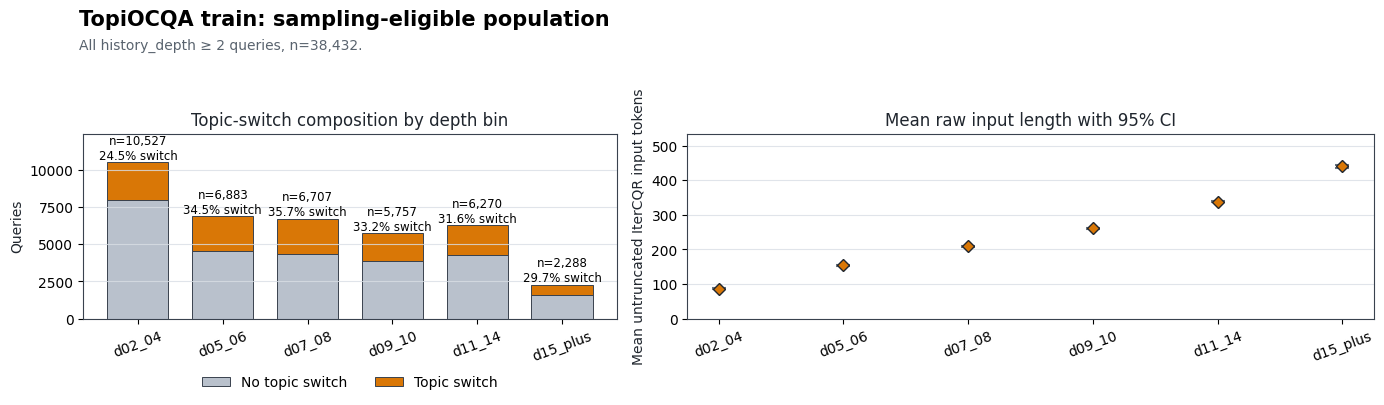

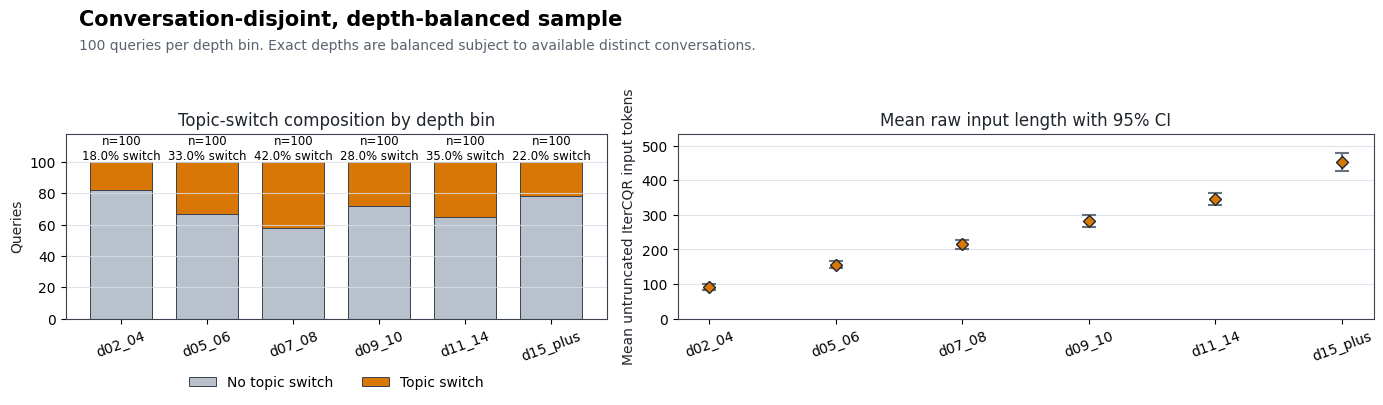

,complete_analysis_reused,population_sha256,result_dir
0,False,147e62c8a7f071356afd7da51dc2b61547837e321a43cb...,/experiments/...


In [4]:
DEPTH_BOUNDS = {
    "d02_04": (2, 4),
    "d05_06": (5, 6),
    "d07_08": (7, 8),
    "d09_10": (9, 10),
    "d11_14": (11, 14),
    "d15_plus": (15, None),
}

eligible_population = build_depth_eligible_population(
    train_frame,
    depth_bounds=DEPTH_BOUNDS,
    depth_bin_order=DEPTH_BIN_ORDER,
)
population_frame = select_depth_balanced_population(
    eligible_population,
    depth_bin_order=DEPTH_BIN_ORDER,
    selection_order=DEPTH_SELECTION_ORDER,
    samples_per_bin=SAMPLE_PER_BIN,
    seed=SEED,
    progress=SHOW_PROGRESS,
)
population_ids = population_frame["sample_id"].astype(str).tolist()

assert len(population_frame) == EXPECTED_POPULATION_SIZE
assert (
    population_frame["sample_id"].nunique()
    == EXPECTED_POPULATION_SIZE
)
assert (
    population_frame["conv_id"].nunique()
    == EXPECTED_POPULATION_SIZE
)
assert (
    population_frame.groupby(
        "conv_id",
        observed=True,
    ).size().max()
    == 1
)
assert (
    population_frame.groupby(
        "depth_bin",
        observed=True,
    ).size().eq(SAMPLE_PER_BIN).all()
)
assert population_frame["history_depth"].ge(2).all()
assert population_frame[
    "positive_ctx_passage_ids"
].map(has_gold_passage).all()


def cohort_summary(
    frame: pd.DataFrame,
    cohort: str,
) -> pd.DataFrame:
    summary = (
        frame.groupby("depth_bin", observed=True)
        .agg(
            n=("sample_id", "size"),
            conversations=("conv_id", "nunique"),
            topic_switch_rate=("topic_switch", "mean"),
            mean_raw_input_length=(
                "raw_input_length",
                "mean",
            ),
            std_raw_input_length=(
                "raw_input_length",
                "std",
            ),
        )
        .reindex(DEPTH_BIN_ORDER)
        .reset_index()
    )

    summary["raw_input_ci95_half_width"] = (
        1.96
        * summary["std_raw_input_length"]
        / np.sqrt(summary["n"])
    )
    summary["raw_input_ci95_low"] = (
        summary["mean_raw_input_length"]
        - summary["raw_input_ci95_half_width"]
    )
    summary["raw_input_ci95_high"] = (
        summary["mean_raw_input_length"]
        + summary["raw_input_ci95_half_width"]
    )
    summary["cohort"] = cohort
    return summary


sampling_summary = pd.concat(
    [
        cohort_summary(
            eligible_population,
            "eligible_train_population",
        ),
        cohort_summary(
            population_frame,
            "depth_balanced_sample",
        ),
    ],
    ignore_index=True,
)

display(sampling_summary.round(3))

TOPIC_COLORS = {
    False: "#b9c1cc",
    True: "#d97706",
}
RAW_TOKEN_CI_YLIM = (
    0,
    float(
        sampling_summary[
            "raw_input_ci95_high"
        ].max()
    )
    * 1.12,
)


def plot_sampling_diagnostic(
    frame: pd.DataFrame,
    title: str,
    subtitle: str,
) -> None:
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5.2),
        gridspec_kw={
            "width_ratios": [1.05, 1.35],
        },
    )

    counts = (
        frame.groupby(
            ["depth_bin", "topic_switch"],
            observed=True,
        )
        .size()
        .unstack(fill_value=0)
        .reindex(
            index=DEPTH_BIN_ORDER,
            columns=[False, True],
            fill_value=0,
        )
    )

    x = np.arange(len(DEPTH_BIN_ORDER))
    bottom = np.zeros(
        len(DEPTH_BIN_ORDER),
        dtype=float,
    )

    for switch_value, label in (
        (False, "No topic switch"),
        (True, "Topic switch"),
    ):
        values = counts[
            switch_value
        ].to_numpy()

        axes[0].bar(
            x,
            values,
            bottom=bottom,
            width=0.72,
            color=TOPIC_COLORS[switch_value],
            edgecolor="#39424e",
            linewidth=0.7,
            label=label,
        )
        bottom += values

    totals = counts.sum(axis=1).to_numpy()
    switch_rates = np.divide(
        counts[True].to_numpy(),
        totals,
        out=np.zeros_like(
            totals,
            dtype=float,
        ),
        where=totals > 0,
    )

    for index, (
        total,
        switch_rate,
    ) in enumerate(
        zip(
            totals,
            switch_rates,
            strict=True,
        )
    ):
        axes[0].text(
            index,
            total,
            (
                f"n={int(total):,}\n"
                f"{switch_rate:.1%} switch"
            ),
            ha="center",
            va="bottom",
            fontsize=8.5,
        )

    axes[0].set_xticks(
        x,
        DEPTH_BIN_ORDER,
        rotation=20,
    )
    axes[0].set_ylim(
        0,
        max(totals) * 1.18,
    )
    axes[0].set_ylabel("Queries")
    axes[0].set_title(
        "Topic-switch composition by depth bin"
    )
    axes[0].legend(
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.24),
        ncol=2,
    )
    axes[0].grid(
        axis="y",
        alpha=0.8,
    )
    axes[0].grid(
        axis="x",
        visible=False,
    )

    length_summary = (
        cohort_summary(frame, "")
        .set_index("depth_bin")
        .reindex(DEPTH_BIN_ORDER)
    )

    means = length_summary[
        "mean_raw_input_length"
    ].to_numpy()
    ci95_low = length_summary[
        "raw_input_ci95_low"
    ].to_numpy()
    ci95_high = length_summary[
        "raw_input_ci95_high"
    ].to_numpy()

    axes[1].errorbar(
        x,
        means,
        yerr=np.vstack(
            [
                means - ci95_low,
                ci95_high - means,
            ]
        ),
        fmt="D",
        linestyle="none",
        markersize=6,
        markerfacecolor="#d97706",
        markeredgecolor="#20262e",
        color="#315f86",
        ecolor="#65727f",
        elinewidth=1.5,
        capsize=5,
        capthick=1.5,
    )

    axes[1].set_xticks(
        x,
        DEPTH_BIN_ORDER,
        rotation=20,
    )
    axes[1].set_ylim(
        *RAW_TOKEN_CI_YLIM
    )
    axes[1].set_ylabel(
        "Mean untruncated IterCQR input tokens"
    )
    axes[1].set_title(
        "Mean raw input length with 95% CI"
    )
    axes[1].grid(
        axis="y",
        alpha=0.8,
    )
    axes[1].grid(
        axis="x",
        visible=False,
    )

    fig.suptitle(
        title,
        x=0.06,
        y=0.99,
        ha="left",
        fontsize=15,
        fontweight="bold",
    )
    fig.text(
        0.06,
        0.935,
        subtitle,
        ha="left",
        va="top",
        color="#59636e",
    )
    fig.tight_layout(
        rect=(0, 0.12, 1, 0.89)
    )
    plt.show()


plot_sampling_diagnostic(
    eligible_population,
    "TopiOCQA train: sampling-eligible population",
    (
        "All history_depth ≥ 2 queries, "
        f"n={len(eligible_population):,}."
    ),
)
plot_sampling_diagnostic(
    population_frame,
    "Conversation-disjoint, depth-balanced sample",
    (
        f"{SAMPLE_PER_BIN} queries per depth bin. "
        "Exact depths are balanced subject to "
        "available distinct conversations."
    ),
)


population_sha256 = sha256_text("\n".join(sorted(population_ids)))
population_frame_sha256 = frame_sha256(
    population_frame,
    sort_by=("sample_id",),
)
ANALYSIS_IDENTITY = {
    "schema_version": 1,
    "protocol": ANALYSIS_PROTOCOL,
    "split": SPLIT,
    "population_sha256": population_sha256,
    "population_frame_sha256": population_frame_sha256,
    "model_sha256": sha256_file(MODEL_DIR / "pytorch_model.bin"),
    "model_config_sha256": sha256_file(MODEL_DIR / "config.json"),
    "tokenizer_sha256": sha256_file(MODEL_DIR / "spiece.model"),
    "bm25_index_segments_sha256": sha256_file(BM25_INDEX_DIR / "segments_1"),
    "seed": SEED,
    "budgets": list(BUDGETS),
    "primary_budget": PRIMARY_BUDGET,
    "sample_per_bin": SAMPLE_PER_BIN,
    "depth_bin_order": list(DEPTH_BIN_ORDER),
    "depth_selection_order": list(DEPTH_SELECTION_ORDER),
    "candidate_config": json.loads(
        json.dumps(asdict(candidate_config), sort_keys=True)
    ),
    "retrieval_top_k": RETRIEVAL_TOP_K,
    "eval_ks": list(EVAL_KS),
    "bm25_k1": 0.9,
    "bm25_b": 0.4,
    "mc_replicates": MC_REPLICATES,
    "mc_robust_replicates": MC_ROBUST_REPLICATES,
    "mc_chunk_size": MC_CHUNK_SIZE,
    "null_control_min_unique_rewrites": NULL_CONTROL_MIN_UNIQUE_REWRITES,
    "null_control_rewrite_buffer": NULL_CONTROL_REWRITE_BUFFER,
    "null_refill_max_masks_per_cardinality": (
        NULL_REFILL_MAX_MASKS_PER_CARDINALITY
    ),
    "null_refill_batch_size": NULL_REFILL_BATCH_SIZE,
    "bootstrap_replicates": BOOTSTRAP_REPLICATES,
    "bootstrap_chunk_size": BOOTSTRAP_CHUNK_SIZE,
    "max_null_support_exclusion_rate": MAX_NULL_SUPPORT_EXCLUSION_RATE,
    "alpha": ALPHA,
}
existing_final_manifest = load_complete_analysis_manifest(
    ANALYSIS_IDENTITY
)
REUSE_COMPLETE_ANALYSIS = existing_final_manifest is not None
display(
    pd.DataFrame(
        [
            {
                "complete_analysis_reused": REUSE_COMPLETE_ANALYSIS,
                "population_sha256": population_sha256,
                "result_dir": str(RESULT_DIR),
            }
        ]
    )
)


Of the 45,450 TopiOCQA training queries, 38,432 have at least two previous turns and are eligible for the V1 oracle. The natural distribution is strongly depth-imbalanced. The shallowest bin contains 10,527 queries, while only 2,288 queries reach a history depth of 15 or more. This supports both depth balancing and the decision to allocate the scarce deepest conversations first.

The final sample contains exactly 100 queries and 100 distinct conversations in every depth bin. It therefore removes the natural dominance of shallow histories and creates equal diagnostic coverage across all six levels of conversational complexity.

Raw IterCQR input length increases consistently with history depth. In the eligible population, the mean rises from 86.85 tokens at depths 2–4 to 440.29 tokens at depths 15 or more. The corresponding sample means are 90.71 and 452.44 tokens. The sample therefore preserves the central relationship between history depth and input-budget pressure.

Topic switches were not used for sampling. Their rates therefore vary between the eligible population and the 100-query bins. Across all bins, the sample contains approximately 29.7% topic-switch queries compared with approximately 31.0% in the eligible population.

### V1 candidate and control space

Each V1 candidate is represented by a binary mask over the previous conversation turns. A value of one retains the complete question–answer turn, while zero removes it. Mask positions run from the oldest to the most recent history turn. Candidate generation uses only the current query and its history. Gold passages and retrieval results are not used at this stage.

The implementation defines five candidate generators. Four enter the primary oracle analysis. `spacy_query_entity_overlap` is retained as a descriptive generator but excluded from the primary generator set.

| Generator | Operation | Example |
|---|---|---|
| `recent_variants` | Produces increasingly long windows of the immediately preceding history turns. | At depth 5: `00001`, `00011`, `00111`, `01111`, and `11111`. |
| `position_anchor` | Tests fixed positional hypotheses using the oldest 1, 2, 3, 5, or 8 turns and combinations of the first turn with the most recent 1, 2, or 4 turns. | At depth 6, `100000` retains the first turn, while `100011` retains the first and two most recent turns. |
| `lexical_overlap` | Ranks turns by lexical overlap with the current query and creates masks from increasingly large ranked prefixes. It abstains when no overlap exists. | For “What is the population of Berlin?”, a turn containing “Berlin” or “population” receives priority. |
| `spacy_recent_entity` | Ranks entity-bearing turns from most to least recent. The entity does not need to occur in the current query. | If the newest entity-bearing turn contains “Berlin” and the preceding one contains “Einstein”, the first mask retains the Berlin turn and the next retains both. |

Each primary generator may contribute at most eight unique masks per query. Different generators can produce the same mask. Such duplicates are evaluated only once, while the complete provenance is retained so that every originating family and role remains traceable.

Two fixed references are added for every query:

- **Recency:** retain the complete history before budget truncation.
- **Query only:** remove the complete history.

A separate control space provides the comparison distribution required for the later Monte Carlo analysis. For histories with depth $h\leq h_{\mathrm{enum}}=8$, all $2^h-1$ non-empty masks are included; at the limit this is $2^8-1=255$. The empty mask is already represented by the query-only reference.

For deeper histories, exhaustive enumeration becomes too expensive. The control space is therefore approximated by deterministically sampling $\min\{10,\binom{h}{h_{\mathrm{sel}}}\}$ distinct masks for each retained-turn count $h_{\mathrm{sel}}\in\{1,\ldots,h\}$. This preserves coverage across selection cardinalities without allowing the number of candidates to grow exponentially.

The provenance expansion separates generator, reference, and control origins after mask deduplication. The assertions verify that:

- all primary generator families are represented
- no generator exceeds eight unique masks per query
- both references occur exactly once per query
- shallow control spaces contain all non-empty masks
- deep control spaces contain at most ten masks per cardinality
- every query in the 600-query sample is represented

measure candidate token lengths:   0%|          | 0/600 [00:00<?, ?sample/s]

generate turn candidates:   0%|          | 0/600 [00:00<?, ?sample/s]

,generator_family,coverage,mean_k,median_k,max_k,abstentions
0,lexical_overlap,0.510,1.130,1.0,8,294
1,position_anchor,1.000,6.947,8.0,8,0
2,recent_variants,1.000,6.668,8.0,8,0
3,spacy_recent_entity,0.992,5.765,6.0,8,5


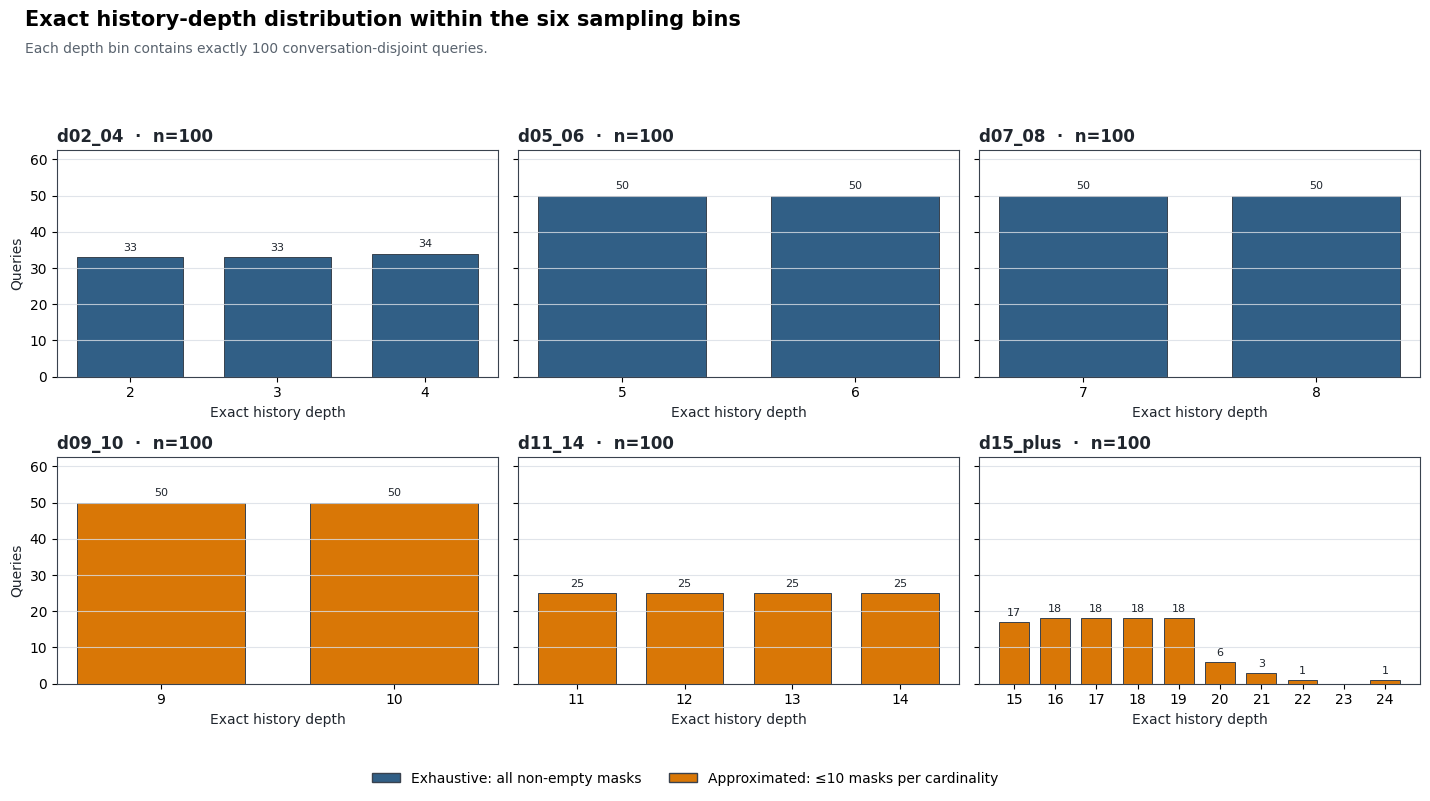

In [5]:
if REUSE_COMPLETE_ANALYSIS:
    generator_coverage = load_result_frame("generator_coverage")
    display(generator_coverage.round(3))
else:
    candidate_pool = generate_turn_selection_candidates(
        data=itercqr_data,
        split=SPLIT,
        config=candidate_config,
        sample_ids=population_ids,
        progress=SHOW_PROGRESS,
    )
    candidate_frame = candidate_pool.candidates.copy()

    provenance_base = candidate_frame[
        [
            "candidate_id",
            "sample_id",
            "mask",
            "mask_true_count",
            "history_turn_count",
            "candidate_provenance",
        ]
    ].explode("candidate_provenance", ignore_index=True)
    provenance_detail = pd.json_normalize(
        provenance_base.pop("candidate_provenance")
    ).add_prefix("provenance_")
    candidate_provenance = pd.concat(
        [provenance_base.reset_index(drop=True), provenance_detail],
        axis=1,
    )

    generator_provenance = candidate_provenance.loc[
        candidate_provenance["provenance_role"].eq("generator")
    ].copy()
    reference_provenance = candidate_provenance.loc[
        candidate_provenance["provenance_role"].eq("reference")
    ].copy()
    control_provenance = candidate_provenance.loc[
        candidate_provenance["provenance_role"].eq("control")
    ].drop_duplicates(["sample_id", "mask"])

    assert set(generator_provenance["provenance_family"]) == set(
        PRIMARY_GENERATOR_FAMILIES
    )
    generator_mask_counts = generator_provenance.groupby(
        ["sample_id", "provenance_family"],
        observed=True,
    )["mask"].nunique()
    assert generator_mask_counts.le(candidate_config.max_candidates_per_generator).all()

    for reference_family in ("recency", "query_only"):
        counts = (
            reference_provenance.loc[
                reference_provenance["provenance_family"].eq(reference_family)
            ]
            .groupby("sample_id", observed=True)["mask"]
            .nunique()
            .reindex(population_ids, fill_value=0)
        )
        assert counts.eq(1).all()

    control_counts = (
        control_provenance.groupby("sample_id", observed=True)["mask"]
        .nunique()
        .rename("actual_control_masks")
        .reset_index()
        .merge(
            population_frame[["sample_id", "history_depth"]],
            on="sample_id",
            how="left",
            validate="one_to_one",
        )
    )
    shallow = control_counts["history_depth"].le(
        candidate_config.control_exhaustive_max_depth
    )
    expected_shallow = (2 ** control_counts.loc[shallow, "history_depth"]) - 1
    assert np.array_equal(
        control_counts.loc[shallow, "actual_control_masks"].to_numpy(),
        expected_shallow.to_numpy(),
    )

    deep_control_cardinality = (
        control_provenance.merge(
            population_frame[["sample_id", "history_depth"]],
            on="sample_id",
            how="left",
            validate="many_to_one",
        )
        .loc[lambda frame: frame["history_depth"].gt(candidate_config.control_exhaustive_max_depth)]
        .groupby(["sample_id", "mask_true_count"], observed=True)["mask"]
        .nunique()
    )
    assert deep_control_cardinality.le(
        candidate_config.control_samples_per_cardinality
    ).all()

    generator_grid = pd.MultiIndex.from_product(
        [population_ids, PRIMARY_GENERATOR_FAMILIES],
        names=["sample_id", "generator_family"],
    )
    generator_k = (
        generator_provenance.groupby(
            ["sample_id", "provenance_family"],
            observed=True,
        )["mask"]
        .nunique()
        .rename_axis(["sample_id", "generator_family"])
        .reindex(generator_grid, fill_value=0)
        .rename("raw_k")
        .reset_index()
    )
    generator_coverage = (
        generator_k.assign(covered=lambda frame: frame["raw_k"].gt(0))
        .groupby("generator_family", observed=True)
        .agg(
            coverage=("covered", "mean"),
            mean_k=("raw_k", "mean"),
            median_k=("raw_k", "median"),
            max_k=("raw_k", "max"),
            abstentions=("covered", lambda values: int((~values).sum())),
        )
        .reset_index()
    )

    assert set(candidate_frame["sample_id"]) == set(population_ids)
    assert {"generator", "reference", "control"}.issubset(
        set().union(*candidate_frame["candidate_roles"].map(set))
    )

    display(generator_coverage.round(3))

    from matplotlib.patches import Patch

    control_depth_frame = control_counts.merge(
        population_frame[["sample_id", "depth_bin"]],
        on="sample_id",
        how="left",
        validate="one_to_one",
    )
    control_depth_distribution = (
        control_depth_frame.groupby(
            ["depth_bin", "history_depth"],
            observed=True,
        )
        .size()
        .rename("queries")
        .reset_index()
    )
    queries_per_bin = (
        control_depth_frame.groupby("depth_bin", observed=True)["sample_id"]
        .nunique()
        .reindex(DEPTH_BIN_ORDER)
    )
    assert queries_per_bin.eq(SAMPLE_PER_BIN).all()

    control_mode_colors = {
        "exhaustive": "#315f86",
        "approximated": "#d97706",
    }
    max_query_count = int(control_depth_distribution["queries"].max())
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

    for ax, depth_bin in zip(axes.flat, DEPTH_BIN_ORDER, strict=True):
        lower, upper = DEPTH_BOUNDS[depth_bin]
        if upper is None:
            upper = int(
                control_depth_frame.loc[
                    control_depth_frame["depth_bin"].eq(depth_bin),
                    "history_depth",
                ].max()
            )
        exact_depths = list(range(lower, upper + 1))
        bin_distribution = (
            control_depth_distribution.loc[
                control_depth_distribution["depth_bin"].eq(depth_bin)
            ]
            .set_index("history_depth")["queries"]
            .reindex(exact_depths, fill_value=0)
        )
        control_modes = [
            (
                "exhaustive"
                if depth <= candidate_config.control_exhaustive_max_depth
                else "approximated"
            )
            for depth in exact_depths
        ]
        x = np.arange(len(exact_depths))
        bars = ax.bar(
            x,
            bin_distribution.to_numpy(),
            width=0.72,
            color=[control_mode_colors[mode] for mode in control_modes],
            edgecolor="#39424e",
            linewidth=0.7,
        )
        ax.bar_label(
            bars,
            labels=[
                str(int(value)) if value > 0 else ""
                for value in bin_distribution
            ],
            padding=3,
            fontsize=8,
            color="#20262e",
        )
        ax.set_xticks(
            x,
            [str(depth) for depth in exact_depths],
            rotation=90 if len(exact_depths) > 10 else 0,
        )
        ax.set_ylim(0, max_query_count * 1.25)
        ax.set_xlabel("Exact history depth")
        ax.set_title(
            f"{depth_bin}  ·  n={int(queries_per_bin.loc[depth_bin])}",
            loc="left",
            fontweight="bold",
        )
        ax.grid(axis="y", alpha=0.8)
        ax.grid(axis="x", visible=False)

    for ax in axes[:, 0]:
        ax.set_ylabel("Queries")

    fig.suptitle(
        "Exact history-depth distribution within the six sampling bins",
        x=0.06,
        y=0.995,
        ha="left",
        fontsize=15,
        fontweight="bold",
    )
    fig.text(
        0.06,
        0.955,
        (
            f"Each depth bin contains exactly {SAMPLE_PER_BIN} "
            "conversation-disjoint queries."
        ),
        ha="left",
        va="top",
        color="#59636e",
    )
    fig.legend(
        handles=[
            Patch(
                facecolor=control_mode_colors["exhaustive"],
                edgecolor="#39424e",
                label="Exhaustive: all non-empty masks",
            ),
            Patch(
                facecolor=control_mode_colors["approximated"],
                edgecolor="#39424e",
                label=(
                    "Approximated: "
                    f"≤{candidate_config.control_samples_per_cardinality} "
                    "masks per cardinality"
                ),
            ),
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=2,
        frameon=False,
    )
    fig.tight_layout(rect=(0.04, 0.08, 1, 0.91))
    plt.show()


`coverage` is the proportion of the 600 queries for which a generator produces at least one mask. Position and recency cover every query and contribute approximately seven masks per query. `spacy_recent_entity` covers 595 queries, while `lexical_overlap` covers only 51% and abstains 294 times when no non-stopword overlap exists.

The exact depths are balanced within all closed bins: 33–34 queries per depth for 2–4, 50 per depth for the two-depth bins, and 25 per depth for 11–14. The open-ended `d15_plus` bin extends to depth 24 but becomes less uniform as sufficiently deep conversations become scarce. Blue bars denote exhaustive enumeration of all non-empty masks at depths up to eight. Orange bars denote the cardinality-stratified approximation used above this threshold.

### Entity-anchor

TopiOCQA was deliberately collected so that follow-up questions are context-dependent, use coreference, and exhibit little lexical overlap ([Adlakha et al., 2022](https://aclanthology.org/2022.tacl-1.27/)). The diagnostic measures how often the current query has an exactly matching spaCy entity in its own history.

| Diagnostic family | Operation | Example with an entity anchor | Example without an entity anchor |
|---|---|---|---|
| `spacy_query_entity_overlap` | Extracts spaCy entities from the current query and the question-answer texts in the history. A candidate is created only when at least one normalized entity matches exactly. History turns are ordered by the number of matches. | Query: “Where was **Barack Obama** born?” History: “**Barack Obama** was the 44th president.” → The history turn has an exact anchor and is selected. | Query: “What was his private life like?” → The elliptical query contains no explicit entity that can be matched against the history. The generator abstains. |

Coverage is the share of queries for which at least one such entity anchor, and therefore one candidate, is found. Low coverage indicates that the current query frequently does not repeat the required entity explicitly. A purely surface-based, query-conditioned entity heuristic cannot make a selection for these queries.

`spacy_query_entity_overlap` is the fifth generator family in the candidate API, but it is used exclusively as a dataset diagnostic in this notebook. Its candidates are excluded from the rewrite, retrieval, and inferential headroom analyses.


In [6]:
if REUSE_COMPLETE_ANALYSIS:
    entity_anchor_summary = load_result_frame("entity_anchor_summary")
    display(entity_anchor_summary.round(4))
else:
    entity_anchor_config = TurnSelectionCandidateConfig(
        generator_families=(DESCRIPTIVE_ONLY_GENERATOR_FAMILY,),
        max_candidates_per_generator=8,
        include_references=False,
        include_control_space=False,
        spacy_model=candidate_config.spacy_model,
        seed=SEED,
    )
    entity_anchor_pool = generate_turn_selection_candidates(
        data=itercqr_data,
        split=SPLIT,
        config=entity_anchor_config,
        sample_ids=eligible_population["sample_id"].astype(str).tolist(),
        progress=SHOW_PROGRESS,
    )
    entity_anchor_candidates = entity_anchor_pool.candidates.copy()
    entity_anchor_covered_ids = set(
        entity_anchor_candidates["sample_id"].astype(str).unique()
    )


    def entity_anchor_diagnostic(
        frame: pd.DataFrame,
        population_name: str,
    ) -> dict[str, Any]:
        frame_ids = set(frame["sample_id"].astype(str))
        covered_queries = len(frame_ids & entity_anchor_covered_ids)
        total_queries = len(frame_ids)
        return {
            "population": population_name,
            "queries": total_queries,
            "queries_with_exact_entity_anchor": covered_queries,
            "entity_anchor_coverage": covered_queries / total_queries,
            "queries_without_exact_entity_anchor": total_queries - covered_queries,
            "no_entity_anchor_rate": 1 - (covered_queries / total_queries),
        }


    entity_anchor_summary = pd.DataFrame(
        [
            entity_anchor_diagnostic(
                eligible_population,
                "eligible TopiOCQA train population",
            ),
            entity_anchor_diagnostic(
                population_frame,
                "conversation-disjoint analysis sample",
            ),
        ]
    )
    full_population_no_anchor_rate = float(
        entity_anchor_summary.loc[
            entity_anchor_summary["population"].eq(
                "eligible TopiOCQA train population"
            ),
            "no_entity_anchor_rate",
        ].iloc[0]
    )

    assert set(entity_anchor_config.generator_families) == {
        DESCRIPTIVE_ONLY_GENERATOR_FAMILY
    }
    assert entity_anchor_candidates["candidate_roles"].map(
        lambda roles: set(roles) == {"generator"}
    ).all()
    assert 0.0 <= full_population_no_anchor_rate <= 1.0

    display(entity_anchor_summary.round(4))


measure candidate token lengths:   0%|          | 0/38432 [00:00<?, ?sample/s]

generate turn candidates:   0%|          | 0/38432 [00:00<?, ?sample/s]

,population,queries,queries_with_exact_entity_anchor,entity_anchor_coverage,queries_without_exact_entity_anchor,no_entity_anchor_rate
0,eligible TopiOCQA train population,38432,272,0.0071,38160,0.9929
1,conversation-disjoint analysis sample,600,7,0.0117,593,0.9883


Exact query–history entity overlap is extremely rare: only 272 of 38,432 eligible queries (0.71%) and 7 of 600 sampled queries (1.17%) contain a matching entity anchor. The sample therefore preserves this scarcity.

History turns often contain entities, as shown by the high coverage of `spacy_recent_entity`, but these entities rarely match the current query explicitly. Exact entity matching is therefore unsuitable as a primary query-conditioned selector. This motivates a learned teacher capable of identifying semantic and coreferential relevance beyond surface-form matches.

### Budget-specific candidate serialization

The cached pipeline fixes the IterCQR checkpoint, BM25 index, hardware, batch sizes, retrieval depth, and evaluation cutoffs. Its SQLite cache allows identical serialized inputs, rewrites, and retrieval results to be reused across later evaluations.

Every V1 candidate mask is materialized independently at budgets 64, 128, 256, and 512. Only `max_input_tokens` changes between runs. The canonical IterCQR serialization and recency-preserving budget truncation remain unchanged. For each candidate-budget pair, the code records the final token length, the length before global truncation, and whether truncation occurred.

Each token sequence is registered under a reusable `input_key`. Different candidate masks can become identical after budget truncation, particularly when their differences occur outside the retained budget. Such inputs share one key and therefore require only one rewrite and retrieval execution.

In [7]:
if REUSE_COMPLETE_ANALYSIS:
    serialization_summary = load_result_frame("serialization_summary")
    display(serialization_summary.round(3))
else:
    cached_pipeline = CachedIterCQRBM25Pipeline(
        config=CachedIterCQRBM25Config(
            cache_db=CACHE_DB_PATH,
            model_dir=MODEL_DIR,
            bm25_index_dir=BM25_INDEX_DIR,
            device=DEVICE,
            rewrite_batch_size=REWRITE_BATCH_SIZE,
            retrieval_batch_size=RETRIEVAL_BATCH_SIZE,
            retrieval_workers=RETRIEVAL_WORKERS,
            retrieval_top_k=RETRIEVAL_TOP_K,
            eval_ks=EVAL_KS,
            progress=SHOW_PROGRESS,
        ),
        tokenizer=itercqr_data.tokenizer,
    )

    serialized_rows: list[dict[str, Any]] = []
    budget_bar = progress(
        total=len(BUDGETS),
        desc="serialize budgets",
        unit="budget",
    )
    for budget in BUDGETS:
        budget_data = replace(
            itercqr_data,
            tokenization_config=replace(
                itercqr_data.tokenization_config,
                max_input_tokens=int(budget),
            ),
        )
        candidate_loader = make_candidate_dataloader(
            data=budget_data,
            split=SPLIT,
            candidates=candidate_frame,
            batch_size=REWRITE_BATCH_SIZE,
        )
        dataset = candidate_loader.dataset
        batch_starts = range(0, len(dataset), REWRITE_BATCH_SIZE)
        inner = progress(
            batch_starts,
            total=math.ceil(len(dataset) / REWRITE_BATCH_SIZE),
            desc=f"materialize B{budget}",
            unit="batch",
            leave=False,
        )
        for start in inner:
            examples = [
                dataset[index]
                for index in range(
                    start,
                    min(
                        start + REWRITE_BATCH_SIZE,
                        len(dataset),
                    ),
                )
            ]
            token_sequences = [
                list(map(int, example.input_ids))
                for example in examples
            ]
            input_keys = cached_pipeline.register_token_inputs(
                token_sequences
            )
            for example, input_key in zip(
                examples,
                input_keys,
                strict=True,
            ):
                metadata = example.metadata
                serialized_rows.append(
                    {
                        "candidate_id": str(
                            metadata["candidate_id"]
                        ),
                        "sample_id": str(
                            metadata["original_sample_id"]
                        ),
                        "conv_id": metadata.get("conv_id"),
                        "turn_id": metadata.get("turn_id"),
                        "budget": int(budget),
                        "input_key": input_key,
                        "input_length": int(example.input_length),
                        "raw_input_length": int(
                            example.raw_input_length
                        ),
                        "was_truncated": bool(
                            example.was_truncated
                        ),
                    }
                )
        budget_bar.update(1)
    budget_bar.close()

    serialized_candidates = pd.DataFrame(serialized_rows)
    assert len(serialized_candidates) == len(candidate_frame) * len(BUDGETS)
    assert not serialized_candidates.duplicated(["candidate_id", "budget"]).any()
    assert serialized_candidates["input_length"].le(serialized_candidates["budget"]).all()
    assert serialized_candidates["raw_input_length"].ge(
        serialized_candidates["input_length"]
    ).all()

    serialization_summary = (
        serialized_candidates.groupby("budget", observed=True)
        .agg(
            candidate_inputs=("candidate_id", "size"),
            unique_token_inputs=("input_key", "nunique"),
            mean_input_length=("input_length", "mean"),
            truncation_rate=("was_truncated", "mean"),
        )
        .reset_index()
    )
    serialization_summary["deduplication_rate"] = 1 - (
        serialization_summary["unique_token_inputs"]
        / serialization_summary["candidate_inputs"]
    )
    serialization_summary["expected_rewrite_batches"] = np.ceil(
        serialization_summary["unique_token_inputs"] / REWRITE_BATCH_SIZE
    ).astype(int)
    display(serialization_summary.round(3))


serialize budgets:   0%|          | 0/4 [00:00<?, ?budget/s]

materialize B64:   0%|          | 0/4210 [00:00<?, ?batch/s]

materialize B128:   0%|          | 0/4210 [00:00<?, ?batch/s]

materialize B256:   0%|          | 0/4210 [00:00<?, ?batch/s]

materialize B512:   0%|          | 0/4210 [00:00<?, ?batch/s]

,budget,candidate_inputs,unique_token_inputs,mean_input_length,truncation_rate,deduplication_rate,expected_rewrite_batches
0,64,67359,29023,60.252,0.835,0.569,1814
1,128,67359,53902,101.048,0.620,0.200,3369
2,256,67359,65595,134.430,0.512,0.026,4100
3,512,67359,67330,144.247,0.493,0.000,4209


All four budgets contain the same 67,359 candidate masks, ensuring that only the available token budget changes between conditions.

At B64, 83.5% of candidate inputs are truncated and many originally different masks collapse to the same serialized sequence. Only 29,023 inputs remain unique, producing a 56.9% deduplication rate and reducing the required rewrite workload from approximately 4,210 to 1,814 batches. At B128, deduplication falls to 20.0%, and at B256 to 2.6%.

At B512, 67,330 of 67,359 inputs are unique. The displayed deduplication rate rounds to zero, although 29 duplicate sequences remain. Mean input length reaches only 144.25 tokens because many candidate masks intentionally retain small history subsets. The remaining 49.3% truncation rate records token removal by either the 32-token field limits or the total budget; it does not mean that 49.3% of candidates exceed 512 tokens.

> **Note:** `mean_input_length` is below the respective budget because many candidate inputs are intrinsically shorter.

### Cached rewrite and BM25 evaluation

The gold passage IDs of the 600 sampled queries are first indexed by `sample_id`. The cached pipeline then processes every serialized candidate-budget row.

This is the first stage at which the IterCQR model and BM25 retriever may be loaded. Missing token inputs are rewritten with IterCQR and stored in SQLite. Identical normalized rewrites are deduplicated before BM25 retrieval. Missing rankings are retrieved to the configured depth and cached, after which each query–rewrite pair is evaluated against its query-specific gold passages.

`serialized_with_rewrite` contains every candidate-budget row together with its generated rewrite and cache keys. `retrieval_metric_pairs` contains the retrieval metrics for the distinct query–rewrite pairs.

In [8]:
if REUSE_COMPLETE_ANALYSIS:
    cache_summary = load_result_frame("cache_summary")
    display(cache_summary)
else:
    gold_by_sample = population_frame.set_index("sample_id")[
        "positive_ctx_passage_ids"
    ].to_dict()
    cached_evaluation = cached_pipeline.run(
        serialized_candidates,
        gold_by_sample=gold_by_sample,
    )
    serialized_with_rewrite = (
        cached_evaluation.serialized_with_rewrite
    )
    retrieval_metric_pairs = (
        cached_evaluation.retrieval_metric_pairs
    )

    display(
        pd.DataFrame(
            [
                {
                    "candidate_budget_rows": len(
                        serialized_with_rewrite
                    ),
                    "unique_inputs": cached_evaluation.unique_inputs,
                    "rewrite_cache_misses": (
                        cached_evaluation.rewrite_cache_misses
                    ),
                    "unique_rewrites": (
                        cached_evaluation.unique_rewrites
                    ),
                    "retrieval_cache_misses": (
                        cached_evaluation.retrieval_cache_misses
                    ),
                    "scored_query_rewrites": (
                        cached_evaluation.scored_query_rewrites
                    ),
                }
            ]
        )
    )


load rewrites cache keys:   0%|          | 0/452579 [00:00<?, ?key/s]

load rewrite cache:   0%|          | 0/136 [00:00<?, ?batch/s]

load retrievals cache keys:   0%|          | 0/393120 [00:00<?, ?key/s]

score retrieved rankings:   0%|          | 0/59023 [00:00<?, ?query-rewrite/s]

,candidate_budget_rows,unique_inputs,rewrite_cache_misses,unique_rewrites,retrieval_cache_misses,scored_query_rewrites
0,269436,108448,0,59005,0,59023


The four budget conditions produce 269,436 candidate-budget rows. These collapse to 108,448 distinct token inputs because identical serialized sequences are reused both within and across budgets. The distinct inputs produce 59,005 normalized rewrites, showing that different history selections can also lead IterCQR to generate the same query.

Both cache-miss counts are zero. All required rewrites and BM25 rankings were already stored in SQLite, so neither IterCQR inference nor BM25 retrieval was executed during this run. The 59,023 scored query–rewrite pairs slightly exceed the 59,005 unique rewrite strings because the same rewrite can occur for different queries and must then be evaluated against different gold passages.

### Retrieval metrics and rewrite-level deduplication

The retrieval metrics are joined back to every candidate-budget row using `sample_id` and `rewrite_key`. Both fields are required because the same normalized rewrite can occur for different queries, but its reciprocal rank must be calculated against the gold passages of the corresponding sample. The first assertion ensures that every candidate received a valid retrieval evaluation.

Candidate provenance is then attached. A candidate may belong to several generator, reference, or control origins, so the merge intentionally expands it into one row per provenance record. This allows later analyses to attribute the same evaluated candidate to every method that produced it.

Different turn masks can produce the same normalized IterCQR rewrite. Counting these duplicates separately would give a family multiple copies of the same effective retrieval query and could artificially increase its apparent candidate support or its probability of containing a high-scoring result. Rewrites are therefore deduplicated within each combination of sample, budget, provenance role, and generator family.

Duplicates are preserved across different roles and families because each family must retain credit for independently producing the rewrite.

In [9]:
if REUSE_COMPLETE_ANALYSIS:
    dedup_summary = load_result_frame("dedup_summary")
    display(dedup_summary.round(3))
else:
    candidate_evaluated = (
        serialized_with_rewrite.merge(
            retrieval_metric_pairs,
            on=["sample_id", "rewrite_key"],
            how="left",
            validate="many_to_one",
        )
    )
    assert candidate_evaluated["MRR"].notna().all()

    provenance_eval = candidate_evaluated.merge(
        candidate_provenance[
            [
                "candidate_id",
                "sample_id",
                "mask",
                "mask_true_count",
                "history_turn_count",
                "provenance_role",
                "provenance_family",
                "provenance_origin",
                "provenance_rank",
            ]
        ],
        on=["candidate_id", "sample_id"],
        how="left",
        validate="many_to_many",
    )
    assert provenance_eval["provenance_role"].notna().all()

    rewrite_dedup_eval = (
        provenance_eval.sort_values(
            [
                "sample_id",
                "budget",
                "provenance_role",
                "provenance_family",
                "rewrite_norm",
                "provenance_rank",
                "mask",
            ],
            kind="mergesort",
        )
        .drop_duplicates(
            [
                "sample_id",
                "budget",
                "provenance_role",
                "provenance_family",
                "rewrite_norm",
            ],
            keep="first",
        )
        .reset_index(drop=True)
    )

    recency_counts = (
        rewrite_dedup_eval.loc[
            rewrite_dedup_eval["provenance_role"].eq("reference")
            & rewrite_dedup_eval["provenance_family"].eq("recency")
        ]
        .groupby(["sample_id", "budget"], observed=True)
        .size()
    )
    assert len(recency_counts) == EXPECTED_POPULATION_SIZE * len(BUDGETS)
    assert recency_counts.eq(1).all()
    assert set(provenance_eval["sample_id"]) == set(population_ids)
    assert provenance_eval["MRR"].between(0, 1).all()

    dedup_summary = (
        provenance_eval.groupby(
            ["budget", "provenance_role"],
            observed=True,
        )
        .size()
        .rename("rows_before_rewrite_dedup")
        .to_frame()
        .join(
            rewrite_dedup_eval.groupby(
                ["budget", "provenance_role"],
                observed=True,
            )
            .size()
            .rename("rows_after_rewrite_dedup")
        )
        .reset_index()
    )
    dedup_summary["deduplication_rate"] = 1 - (
        dedup_summary["rows_after_rewrite_dedup"]
        / dedup_summary["rows_before_rewrite_dedup"]
    )
    display(dedup_summary.round(3))


,budget,provenance_role,rows_before_rewrite_dedup,rows_after_rewrite_dedup,deduplication_rate
0,64,control,61280,22958,0.625
1,64,generator,12306,7236,0.412
2,64,reference,1200,1200,0.000
3,128,control,61280,34377,0.439
4,128,generator,12306,8940,0.274
5,128,reference,1200,1200,0.000
6,256,control,61280,35948,0.413
7,256,generator,12306,9774,0.206
8,256,reference,1200,1200,0.000
9,512,control,61280,35919,0.414


> **B64 example:** Of 61,280 control masks, 22,958 distinct effective rewrites remain after rewrite deduplication. The remaining 38,322 rewrites, or 62.5%, are redundant and removed.


Rewrite collapse is strongest at B64. After normalization, 62.5% of control rows and 41.2% of generator rows duplicate another rewrite from the same query, budget, role, and family. Tight truncation therefore causes many distinct turn masks to become functionally identical.

Deduplication decreases as more context becomes available, but it does not disappear. At B256 and B512, approximately 41% of control rows and 20% of generator rows still collapse. Different retained histories can therefore produce the same IterCQR rewrite even at larger budgets, either because some inputs remain truncated or because the rewriter is insensitive to their differences.

The reference rows remain unchanged because recency and query-only each contribute exactly one row per query and budget, and duplicates are intentionally preserved across different reference families. The higher control deduplication reflects its much larger and more redundant mask space.

### Recency degradation and V1 control-space headroom

The canonical Recency reference is isolated for every query and budget. Because the same 600 queries occur at all four budgets, degradation is calculated as a paired per-query difference from B512. B512 acts only as the internal full-budget reference. This analysis quantifies the loss caused by tighter Recency truncation but does not yet measure whether selection can exceed B512.

The control-space analysis compares every evaluated V1 mask with the Recency result of the same query and budget. Masks are classified as producing lower, equal, or higher reciprocal rank ($\mathrm{RR}$). The best available control mask is then determined for each query-budget pair.

The space oracle is defined as the better of Recency and the best evaluated control mask:

$$
\operatorname{SpaceOracle}(q_t,B)=\max\left(\mathrm{RR}_{I_B}(q_t),\max_{\widehat H_t\ \mathrm{evaluated}}\mathrm{RR}(q_t,\widehat H_t,B)\right).
$$

Here $\mathrm{RR}(q_t,\widehat H_t,B)$ is the reciprocal rank obtained after budgeting and rewriting the selected history. Averaging these query-level oracle scores gives the space-oracle $\mathrm{MRR}$.

Headroom is the paired difference between this oracle and Recency. Including Recency as a fallback ensures that oracle headroom cannot be negative. Since the best mask is selected retrospectively using gold-evaluated retrieval outcomes, the space oracle represents a diagnostic upper bound for any selector restricted to the evaluated masks and cannot be deployed at inference time.

Queries with depth up to eight have an exhaustive non-empty V1 mask space. Their space-oracle result is exact within this definition. Deeper histories use the cardinality-stratified control sample, so their best observed result and headroom are lower bounds on what the complete V1 space might contain.

Two query-weighted summaries are reported:

- **Query-weighted headroom:** every query contributes once through its best available mask.
- **Effective-selection outcome shares:** masks that serialize to the same budget-truncated `input_key` are collapsed within each query and budget. Negative, neutral, and positive shares are calculated within every query before being averaged across queries.

This normalization describes the distribution of distinct selector inputs without allowing deeper histories or truncation-induced duplicates to dominate the estimate. It is not the proportion of improvable queries: one query may contain both beneficial and harmful effective selections. The final plot applies the same query weighting separately within every budget and history-depth bin. All results in this stage are descriptive. Inferential testing follows later.

,budget,recency_mrr,delta_vs_B512,relative_delta_vs_B512_pct
0,64,0.1370,-0.0489,-26.32
1,128,0.1670,-0.0189,-10.18
2,256,0.1847,-0.0012,-0.65
3,512,0.1860,0.0000,0.00


> **Conclusion:** History compression is most relevant at B64. Recency MRR is 26.32% below B512, whereas the loss at B256 is only 0.65%. B64 therefore represents the strongest budget bottleneck and the largest potential use case for targeted history selection. This comparison quantifies only the loss relative to B512; the possible headroom above B512 quality remains unknown here. Whether targeted history compression can even outperform B512 is addressed only by the following oracle-headroom analysis.

> **Important scope:** These values are based exclusively on the informed, depth-balanced, conversation-disjoint sample of 600 queries from the sampling-eligible TopiOCQA training population. They are neither full-development-set results nor population-weighted estimates; deviations from an evaluation on the complete development split are therefore expected.

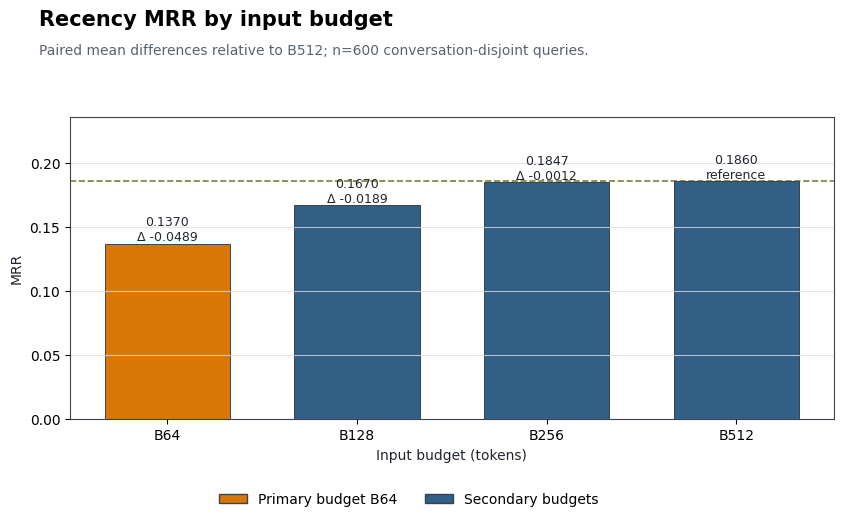

,budget,control_mode,queries,recency_mrr,space_oracle_mrr,space_oracle_headroom
0,64,approximated,300,0.1161,0.3652,0.2491
1,64,exhaustive,300,0.1580,0.3528,0.1949
2,128,approximated,300,0.1462,0.4173,0.2710
3,128,exhaustive,300,0.1878,0.3752,0.1873
4,256,approximated,300,0.1853,0.4339,0.2486
5,256,exhaustive,300,0.1842,0.3752,0.1910
6,512,approximated,300,0.1877,0.4335,0.2458
7,512,exhaustive,300,0.1842,0.3752,0.1910


> **Finding:** The control space exhibits substantial descriptive headroom over the Recency IterCQR baseline. At B64 it is 0.1949 MRR in the exhaustive subset and at least 0.2491 MRR in the approximated subset. The mask space is complete up to history depth 8; for deeper queries, the observed value is a lower bound on the possible space-oracle headroom.

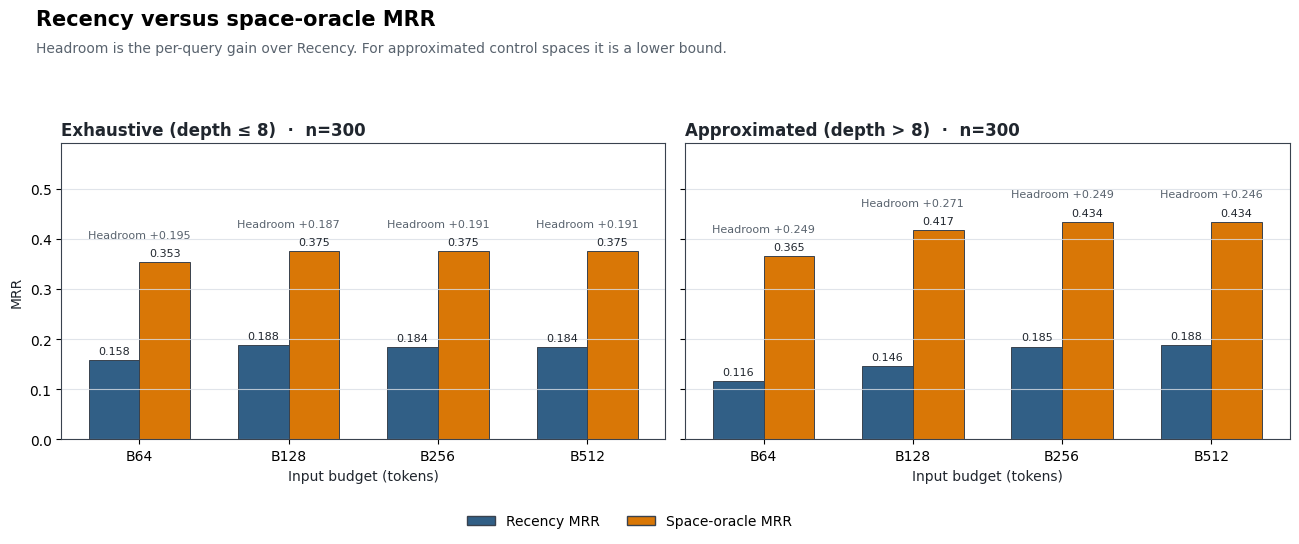

In [10]:
if REUSE_COMPLETE_ANALYSIS:
    budget_degradation = load_result_frame("budget_degradation")
    space_oracle_summary = load_result_frame("space_oracle_summary")
    control_relation_summary = load_result_frame("control_relation_summary")
    control_relation_depth_summary = load_result_frame(
        "control_relation_depth_summary"
    )
    display(
        budget_degradation.round(
            {
                "recency_mrr": 4,
                "delta_vs_B512": 4,
                "relative_delta_vs_B512_pct": 2,
            }
        )
    )
    display(space_oracle_summary.round(4))
    display(control_relation_summary.round(4))
else:
    from matplotlib.patches import Patch

    METRIC_COLUMNS = ["MRR", "nDCG@3", "R@10", "R@100", "R@1000"]

    recency_rows = rewrite_dedup_eval.loc[
        rewrite_dedup_eval["provenance_role"].eq("reference")
        & rewrite_dedup_eval["provenance_family"].eq("recency")
    ].copy()

    query_only_rows = rewrite_dedup_eval.loc[
        rewrite_dedup_eval["provenance_role"].eq("reference")
        & rewrite_dedup_eval["provenance_family"].eq("query_only")
    ].copy()

    recency_wide = recency_rows.pivot(
        index="sample_id",
        columns="budget",
        values="MRR",
    ).reindex(
        index=population_ids,
        columns=BUDGETS,
    )
    assert recency_wide.notna().all().all()

    b512_recency_mrr = float(recency_wide[512].mean())
    assert b512_recency_mrr > 0.0

    budget_degradation_rows: list[dict[str, Any]] = []
    for budget in BUDGETS:
        paired_delta = recency_wide[budget] - recency_wide[512]
        mean_delta = float(paired_delta.mean())
        budget_degradation_rows.append(
            {
                "budget": budget,
                "recency_mrr": float(recency_wide[budget].mean()),
                "delta_vs_B512": mean_delta,
                "relative_delta_vs_B512_pct": (
                    100.0 * mean_delta / b512_recency_mrr
                ),
            }
        )

    budget_degradation = pd.DataFrame(budget_degradation_rows)
    display(
        budget_degradation.round(
            {
                "recency_mrr": 4,
                "delta_vs_B512": 4,
                "relative_delta_vs_B512_pct": 2,
            }
        )
    )

    b64_relative_loss_pct = abs(
        float(
            budget_degradation.loc[
                budget_degradation["budget"].eq(64),
                "relative_delta_vs_B512_pct",
            ].iloc[0]
        )
    )
    b256_relative_loss_pct = abs(
        float(
            budget_degradation.loc[
                budget_degradation["budget"].eq(256),
                "relative_delta_vs_B512_pct",
            ].iloc[0]
        )
    )

    display(
        Markdown(
            f'> **Conclusion:** History compression is most relevant at B64. Recency MRR is {b64_relative_loss_pct:.2f}% below B512, whereas the loss at B256 is only {b256_relative_loss_pct:.2f}%. B64 therefore represents the strongest budget bottleneck and the largest potential use case for targeted history selection. This comparison quantifies only the loss relative to B512; the possible headroom above B512 quality remains unknown here. Whether targeted history compression can even outperform B512 is addressed only by the following oracle-headroom analysis.\n\n> **Important scope:** These values are based exclusively on the informed, depth-balanced, conversation-disjoint sample of 600 queries from the sampling-eligible TopiOCQA training population. They are neither full-development-set results nor population-weighted estimates; deviations from an evaluation on the complete development split are therefore expected.'
        )
    )

    BLUE = "#315f86"
    ORANGE = "#d97706"
    INK = "#20262e"
    REFERENCE = "#75813b"

    budget_plot = budget_degradation.sort_values("budget").reset_index(drop=True)
    x = np.arange(len(budget_plot))

    fig, ax = plt.subplots(figsize=(8.8, 5.2))

    bars = ax.bar(
        x,
        budget_plot["recency_mrr"],
        width=0.66,
        color=[
            ORANGE if budget == PRIMARY_BUDGET else BLUE
            for budget in budget_plot["budget"]
        ],
        edgecolor="#39424e",
        linewidth=0.7,
    )

    b512_mrr = float(
        budget_plot.loc[
            budget_plot["budget"].eq(512),
            "recency_mrr",
        ].iloc[0]
    )
    ax.axhline(
        b512_mrr,
        color=REFERENCE,
        linestyle="--",
        linewidth=1.2,
        zorder=0,
    )

    for bar, row in zip(
        bars,
        budget_plot.itertuples(index=False),
        strict=True,
    ):
        delta_label = (
            "reference"
            if row.budget == 512
            else f"Δ {row.delta_vs_B512:+.4f}"
        )
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{row.recency_mrr:.4f}\n{delta_label}",
            ha="center",
            va="bottom",
            fontsize=9,
            color=INK,
        )

    ax.set_xticks(
        x,
        [f"B{budget}" for budget in budget_plot["budget"]],
    )
    ax.set_ylim(
        0,
        max(0.01, float(budget_plot["recency_mrr"].max()) * 1.27),
    )
    ax.set_xlabel("Input budget (tokens)")
    ax.set_ylabel("MRR")
    ax.grid(axis="y", alpha=0.8)
    ax.grid(axis="x", visible=False)

    fig.suptitle(
        "Recency MRR by input budget",
        x=0.08,
        y=0.99,
        ha="left",
        fontsize=15,
        fontweight="bold",
    )
    fig.text(
        0.08,
        0.925,
        (
            f"Paired mean differences relative to B512; "
            f"n={EXPECTED_POPULATION_SIZE} conversation-disjoint queries."
        ),
        ha="left",
        va="top",
        color="#59636e",
    )
    fig.legend(
        handles=[
            Patch(
                facecolor=ORANGE,
                edgecolor="#39424e",
                label=f"Primary budget B{PRIMARY_BUDGET}",
            ),
            Patch(
                facecolor=BLUE,
                edgecolor="#39424e",
                label="Secondary budgets",
            ),
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=2,
        frameon=False,
    )
    fig.tight_layout(rect=(0.03, 0.09, 1, 0.88))
    plt.show()

    relation_order = ("negative", "neutral", "positive")

    control_input_eval = (
        provenance_eval.loc[
            provenance_eval["provenance_role"].eq("control")
            & provenance_eval["provenance_family"].eq("mask_space")
        ]
        .sort_values(
            ["sample_id", "budget", "input_key", "mask"],
            kind="mergesort",
        )
        .drop_duplicates(["sample_id", "budget", "input_key"])
        .merge(
            recency_rows[["sample_id", "budget", "MRR"]].rename(
                columns={"MRR": "recency_rr"}
            ),
            on=["sample_id", "budget"],
            how="left",
            validate="many_to_one",
        )
    )

    control_input_eval["relation_to_recency"] = np.select(
        [
            control_input_eval["MRR"].gt(
                control_input_eval["recency_rr"]
            ),
            control_input_eval["MRR"].lt(
                control_input_eval["recency_rr"]
            ),
        ],
        ["positive", "negative"],
        default="neutral",
    )

    query_relation_counts = (
        control_input_eval.groupby(
            ["sample_id", "budget", "relation_to_recency"],
            observed=True,
        )
        .size()
        .unstack(fill_value=0)
        .reindex(columns=relation_order, fill_value=0)
    )
    assert len(query_relation_counts) == (
        EXPECTED_POPULATION_SIZE * len(BUDGETS)
    )
    assert query_relation_counts.sum(axis=1).gt(0).all()

    query_relation_shares = query_relation_counts.div(
        query_relation_counts.sum(axis=1),
        axis=0,
    )
    control_query_relation = (
        query_relation_counts.rename_axis(
            columns="relation_to_recency"
        )
        .stack(future_stack=True)
        .rename("effective_inputs")
        .to_frame()
        .join(
            query_relation_shares.rename_axis(
                columns="relation_to_recency"
            )
            .stack(future_stack=True)
            .rename("query_share")
        )
        .reset_index()
        .merge(
            population_frame[["sample_id", "depth_bin"]],
            on="sample_id",
            how="left",
            validate="many_to_one",
        )
    )
    assert control_query_relation["depth_bin"].notna().all()

    control_best = (
        rewrite_dedup_eval.loc[
            rewrite_dedup_eval["provenance_role"].eq("control")
            & rewrite_dedup_eval["provenance_family"].eq("mask_space")
        ]
        .groupby(
            ["sample_id", "budget"],
            observed=True,
        )["MRR"]
        .max()
        .rename("best_control_rr")
        .reset_index()
    )

    space_query = (
        recency_rows[["sample_id", "budget", "MRR"]]
        .rename(columns={"MRR": "recency_rr"})
        .merge(
            control_best,
            on=["sample_id", "budget"],
            how="left",
            validate="one_to_one",
        )
        .merge(
            population_frame[
                [
                    "sample_id",
                    "conv_id",
                    "history_depth",
                    "depth_bin",
                    "topic_switch",
                ]
            ],
            on="sample_id",
            how="left",
            validate="many_to_one",
        )
    )

    assert space_query["best_control_rr"].notna().all()

    space_query["space_oracle_rr"] = np.maximum(
        space_query["recency_rr"],
        space_query["best_control_rr"],
    )
    space_query["space_oracle_headroom"] = (
        space_query["space_oracle_rr"]
        - space_query["recency_rr"]
    )
    space_query["control_mode"] = np.where(
        space_query["history_depth"].le(
            candidate_config.control_exhaustive_max_depth
        ),
        "exhaustive",
        "approximated",
    )

    control_relation_summary = (
        control_query_relation.groupby(
            ["budget", "relation_to_recency"],
            observed=True,
        )
        .agg(
            queries=("sample_id", "nunique"),
            effective_inputs=("effective_inputs", "sum"),
            share=("query_share", "mean"),
        )
        .reset_index()
    )
    assert np.allclose(
        control_relation_summary.groupby("budget", observed=True)[
            "share"
        ].sum(),
        1.0,
    )
    control_relation_depth_summary = (
        control_query_relation.groupby(
            ["budget", "depth_bin", "relation_to_recency"],
            observed=True,
        )
        .agg(
            queries=("sample_id", "nunique"),
            effective_inputs=("effective_inputs", "sum"),
            share=("query_share", "mean"),
        )
        .reset_index()
    )
    assert np.allclose(
        control_relation_depth_summary.groupby(
            ["budget", "depth_bin"],
            observed=True,
        )["share"].sum(),
        1.0,
    )

    space_oracle_summary = (
        space_query.groupby(
            ["budget", "control_mode"],
            observed=True,
        )
        .agg(
            queries=("sample_id", "size"),
            recency_mrr=("recency_rr", "mean"),
            space_oracle_mrr=("space_oracle_rr", "mean"),
            space_oracle_headroom=("space_oracle_headroom", "mean"),
        )
        .reset_index()
    )
    display(space_oracle_summary.round(4))

    b64_space_headroom = (
        space_oracle_summary.loc[
            space_oracle_summary["budget"].eq(PRIMARY_BUDGET)
        ]
        .set_index("control_mode")["space_oracle_headroom"]
    )
    b64_exhaustive_headroom = float(b64_space_headroom.loc["exhaustive"])
    b64_approximated_headroom = float(b64_space_headroom.loc["approximated"])

    display(
        Markdown(
            f'> **Finding:** The control space exhibits substantial descriptive headroom over the Recency IterCQR baseline. At B{PRIMARY_BUDGET} it is {b64_exhaustive_headroom:.4f} MRR in the exhaustive subset and at least {b64_approximated_headroom:.4f} MRR in the approximated subset. The mask space is complete up to history depth 8; for deeper queries, the observed value is a lower bound on the possible space-oracle headroom.'
        )
    )

    control_mode_order = ("exhaustive", "approximated")
    space_ymax = max(
        0.01,
        float(space_oracle_summary["space_oracle_mrr"].max()) * 1.36,
    )
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), sharey=True)

    for ax, control_mode in zip(axes, control_mode_order, strict=True):
        mode_frame = (
            space_oracle_summary.loc[
                space_oracle_summary["control_mode"].eq(control_mode)
            ]
            .set_index("budget")
            .reindex(BUDGETS)
            .reset_index()
        )
        assert mode_frame[
            ["recency_mrr", "space_oracle_mrr", "space_oracle_headroom"]
        ].notna().all().all()

        x = np.arange(len(mode_frame))
        width = 0.34
        recency_bars = ax.bar(
            x - width / 2,
            mode_frame["recency_mrr"],
            width=width,
            color=BLUE,
            edgecolor="#39424e",
            linewidth=0.7,
            label="Recency",
        )
        oracle_bars = ax.bar(
            x + width / 2,
            mode_frame["space_oracle_mrr"],
            width=width,
            color=ORANGE,
            edgecolor="#39424e",
            linewidth=0.7,
            label="Space oracle",
        )
        ax.bar_label(
            recency_bars,
            labels=[f"{value:.3f}" for value in mode_frame["recency_mrr"]],
            padding=3,
            fontsize=8,
            color=INK,
        )
        ax.bar_label(
            oracle_bars,
            labels=[f"{value:.3f}" for value in mode_frame["space_oracle_mrr"]],
            padding=3,
            fontsize=8,
            color=INK,
        )
        for index, row in enumerate(mode_frame.itertuples(index=False)):
            ax.text(
                index,
                max(row.recency_mrr, row.space_oracle_mrr) + 0.045,
                f"Headroom +{row.space_oracle_headroom:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
                color="#59636e",
            )

        mode_label = (
            f"Exhaustive (depth ≤ {candidate_config.control_exhaustive_max_depth})"
            if control_mode == "exhaustive"
            else f"Approximated (depth > {candidate_config.control_exhaustive_max_depth})"
        )
        query_count = int(mode_frame["queries"].iloc[0])
        ax.set_title(
            f"{mode_label}  ·  n={query_count}",
            loc="left",
            fontweight="bold",
        )
        ax.set_xticks(x, [f"B{budget}" for budget in mode_frame["budget"]])
        ax.set_ylim(0, space_ymax)
        ax.set_xlabel("Input budget (tokens)")
        ax.grid(axis="y", alpha=0.8)
        ax.grid(axis="x", visible=False)

    axes[0].set_ylabel("MRR")
    fig.suptitle(
        "Recency versus space-oracle MRR",
        x=0.06,
        y=0.995,
        ha="left",
        fontsize=15,
        fontweight="bold",
    )
    fig.text(
        0.06,
        0.935,
        (
            "Headroom is the per-query gain over Recency. "
            "For approximated control spaces it is a lower bound."
        ),
        ha="left",
        va="top",
        color="#59636e",
    )
    fig.legend(
        handles=[
            Patch(
                facecolor=BLUE,
                edgecolor="#39424e",
                label="Recency MRR",
            ),
            Patch(
                facecolor=ORANGE,
                edgecolor="#39424e",
                label="Space-oracle MRR",
            ),
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=2,
        frameon=False,
    )
    fig.tight_layout(rect=(0.03, 0.09, 1, 0.88))
    plt.show()


,budget,relation_to_recency,queries,effective_inputs,share
0,64,negative,600,11743,0.4112
1,64,neutral,600,10323,0.4074
2,64,positive,600,4500,0.1814
3,128,negative,600,22281,0.4416
4,128,neutral,600,18086,0.3755
5,128,positive,600,9226,0.1829
6,256,negative,600,28189,0.4647
7,256,neutral,600,21936,0.3721
8,256,positive,600,9480,0.1632
9,512,negative,600,29474,0.4723


> **Finding:** At B64, the mean within-query shares are 41.12% below Recency, 40.74% equal to Recency, and 18.14% above Recency across 26,566 distinct effective inputs.

> **Weighting:** Inputs that become identical after budget truncation are counted once per query and budget. The three shares are computed within each query first and then averaged across all 600 queries, so every query receives equal weight. `neutral` means equal MRR, not necessarily the same rewrite or ranking.

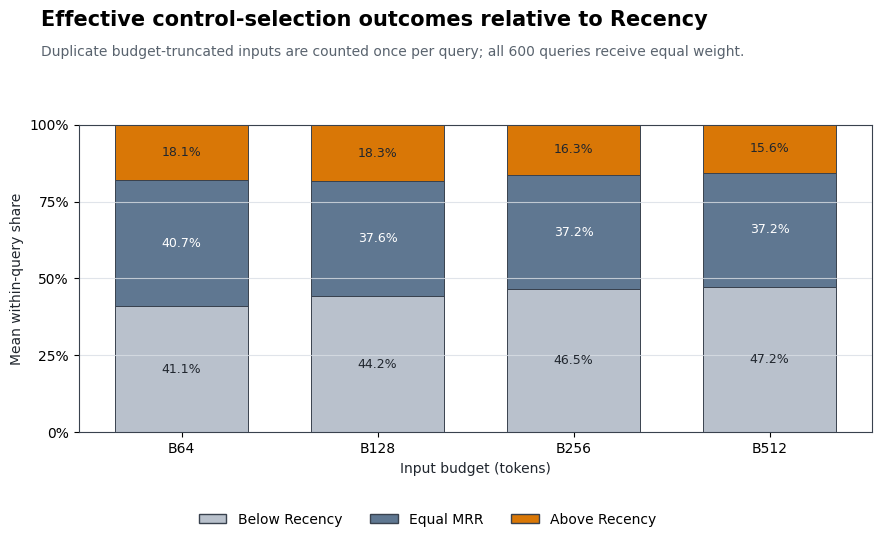

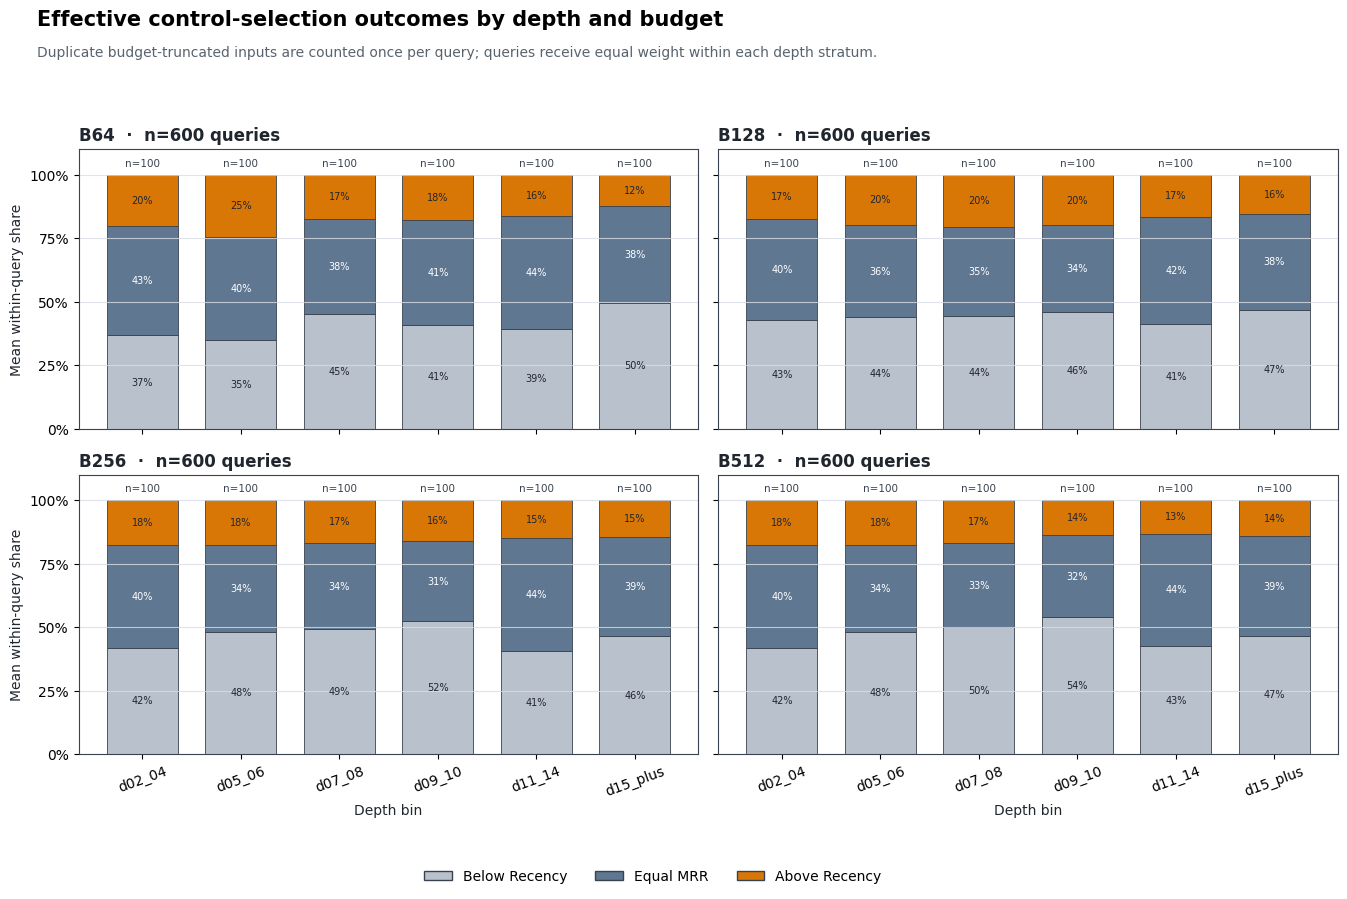

In [11]:
from matplotlib.patches import Patch

INK = "#20262e"
relation_order = ("negative", "neutral", "positive")

display(control_relation_summary.round(4))

relation_colors = {
    "negative": "#b9c1cc",
    "neutral": "#5f7791",
    "positive": "#d97706",
}
relation_labels = {
    "negative": "Below Recency",
    "neutral": "Equal MRR",
    "positive": "Above Recency",
}

b64_relation = (
    control_relation_summary.loc[
        control_relation_summary["budget"].eq(PRIMARY_BUDGET)
    ]
    .set_index("relation_to_recency")["share"]
    .reindex(relation_order, fill_value=0.0)
)
b64_effective_input_count = int(
    control_relation_summary.loc[
        control_relation_summary["budget"].eq(PRIMARY_BUDGET),
        "effective_inputs",
    ].sum()
)
display(
    Markdown(
        f"> **Finding:** At B{PRIMARY_BUDGET}, the mean within-query shares are {b64_relation['negative']:.2%} below Recency, {b64_relation['neutral']:.2%} equal to Recency, and {b64_relation['positive']:.2%} above Recency across {b64_effective_input_count:,} distinct effective inputs.\n\n> **Weighting:** Inputs that become identical after budget truncation are counted once per query and budget. The three shares are computed within each query first and then averaged across all 600 queries, so every query receives equal weight. `neutral` means equal MRR, not necessarily the same rewrite or ranking."
    )
)

relation_share_wide = (
    control_relation_summary.pivot(
        index="budget",
        columns="relation_to_recency",
        values="share",
    )
    .reindex(index=BUDGETS, columns=relation_order)
    .fillna(0.0)
)

fig, ax = plt.subplots(figsize=(9.2, 5.4))
x = np.arange(len(relation_share_wide))
bottom = np.zeros(len(relation_share_wide), dtype=float)
for relation in relation_order:
    values = relation_share_wide[relation].to_numpy(dtype=float)
    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        width=0.68,
        color=relation_colors[relation],
        edgecolor="#39424e",
        linewidth=0.7,
        label=relation_labels[relation],
    )
    for bar, value, lower in zip(bars, values, bottom, strict=True):
        if value >= 0.05:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                lower + value / 2,
                f"{value:.1%}",
                ha="center",
                va="center",
                fontsize=9,
                color=INK if relation != "neutral" else "white",
            )
    bottom += values

ax.set_xticks(x, [f"B{budget}" for budget in relation_share_wide.index])
ax.set_ylim(0, 1)
ax.set_yticks(
    [0.0, 0.25, 0.5, 0.75, 1.0],
    ["0%", "25%", "50%", "75%", "100%"],
)
ax.set_xlabel("Input budget (tokens)")
ax.set_ylabel("Mean within-query share")
ax.grid(axis="y", alpha=0.8)
ax.grid(axis="x", visible=False)
fig.suptitle(
    "Effective control-selection outcomes relative to Recency",
    x=0.08,
    y=0.99,
    ha="left",
    fontsize=15,
    fontweight="bold",
)
fig.text(
    0.08,
    0.925,
    (
        "Duplicate budget-truncated inputs are counted once per query; "
        "all 600 queries receive equal weight."
    ),
    ha="left",
    va="top",
    color="#59636e",
)
fig.legend(
    handles=[
        Patch(
            facecolor=relation_colors[relation],
            edgecolor="#39424e",
            label=relation_labels[relation],
        )
        for relation in relation_order
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=3,
    frameon=False,
)
fig.tight_layout(rect=(0.03, 0.10, 1, 0.88))
plt.show()

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
    sharex=True,
    sharey=True,
)
for ax, budget in zip(axes.flat, BUDGETS, strict=True):
    panel = (
        control_relation_depth_summary.loc[
            control_relation_depth_summary["budget"].eq(budget)
        ]
        .pivot(
            index="depth_bin",
            columns="relation_to_recency",
            values="share",
        )
        .reindex(index=DEPTH_BIN_ORDER, columns=relation_order)
        .fillna(0.0)
    )
    bar_query_counts = (
        control_relation_depth_summary.loc[
            control_relation_depth_summary["budget"].eq(budget)
        ]
        .groupby("depth_bin", observed=True)["queries"]
        .max()
        .reindex(DEPTH_BIN_ORDER, fill_value=0)
        .astype(int)
    )
    x = np.arange(len(DEPTH_BIN_ORDER))
    bottom = np.zeros(len(DEPTH_BIN_ORDER), dtype=float)
    for relation in relation_order:
        values = panel[relation].to_numpy(dtype=float)
        bars = ax.bar(
            x,
            values,
            bottom=bottom,
            width=0.72,
            color=relation_colors[relation],
            edgecolor="#39424e",
            linewidth=0.6,
        )
        for bar, value, lower in zip(bars, values, bottom, strict=True):
            if value >= 0.08:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    lower + value / 2,
                    f"{value:.0%}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color=INK if relation != "neutral" else "white",
                )
        bottom += values

    for index, count in enumerate(bar_query_counts.to_numpy()):
        ax.text(
            index,
            1.025,
            f"n={count:,}",
            ha="center",
            va="bottom",
            fontsize=7.5,
            color="#39424e",
            clip_on=False,
        )

    query_count = int(
        control_relation_depth_summary.loc[
            control_relation_depth_summary["budget"].eq(budget)
        ]
        .groupby("depth_bin", observed=True)["queries"]
        .max()
        .sum()
    )
    ax.set_title(
        f"B{budget}  ·  n={query_count:,} queries",
        loc="left",
        fontweight="bold",
    )
    ax.set_xticks(x, DEPTH_BIN_ORDER, rotation=20)
    ax.set_ylim(0, 1.10)
    ax.set_yticks(
        [0.0, 0.25, 0.5, 0.75, 1.0],
        ["0%", "25%", "50%", "75%", "100%"],
    )
    ax.grid(axis="y", alpha=0.8)
    ax.grid(axis="x", visible=False)

for ax in axes[:, 0]:
    ax.set_ylabel("Mean within-query share")
for ax in axes[-1, :]:
    ax.set_xlabel("Depth bin")

fig.suptitle(
    "Effective control-selection outcomes by depth and budget",
    x=0.06,
    y=0.995,
    ha="left",
    fontsize=15,
    fontweight="bold",
)
fig.text(
    0.06,
    0.955,
    (
        "Duplicate budget-truncated inputs are counted once per query; "
        "queries receive equal weight within each depth stratum."
    ),
    ha="left",
    va="top",
    color="#59636e",
)
fig.legend(
    handles=[
        Patch(
            facecolor=relation_colors[relation],
            edgecolor="#39424e",
            label=relation_labels[relation],
        )
        for relation in relation_order
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=3,
    frameon=False,
)
fig.tight_layout(rect=(0.03, 0.08, 1, 0.92))
plt.show()


Recency is highly sensitive to the smallest input budget. MRR decreases from 0.1860 at B512 to 0.1370 at B64, a relative loss of 26.32%. B256 nearly reproduces B512, confirming that B64 represents the strongest context bottleneck.

The V1 mask space contains substantial retrieval headroom. At B64, exhaustive evaluation for histories up to depth eight yields 0.1949 MRR headroom over Recency. For deeper histories, the sampled control space yields at least 0.2491 headroom. Since the best mask is selected retrospectively using gold-evaluated retrieval outcomes, these oracle values demonstrate available signal rather than deployable performance. The approximated result is additionally a lower bound relative to the complete V1 mask space.

After budget-identical inputs are collapsed, beneficial effective selections remain a minority, while negative and neutral outcomes dominate. Valuable selections therefore exist, but arbitrary history removal remains unreliable. The depth-stratified results show how this decision difficulty changes across the sampled depth range.

Oracle headroom is **query-weighted**. The best available mask is first selected separately for every query, after which the 600 query-specific gains are averaged. Every query therefore contributes exactly once, regardless of the size of its control space.

The control-selection shares are also **query-weighted**. Nominal masks that serialize to the same budget-truncated IterCQR input are counted once within each query and budget. The negative, neutral, and positive shares are then computed separately for every query before the 600 query-specific distributions are averaged. This prevents deep histories and duplicated truncated inputs from dominating the result.

The plots therefore describe the distribution of distinct effective selection decisions under each budget. Different effective inputs remain separate even when the deterministic rewriter happens to produce the same rewrite, because the normalization is applied at the selector-input boundary rather than retrospectively at the rewrite output.

All results are descriptive and refer only to the conversation-disjoint, depth-balanced 600-query TopiOCQA training sample.

### Generator-specific oracle headroom

This analysis determines how much retrieval headroom each candidate-generator family exposes at the primary budget B64. For every query, budget, and generator family, the generated masks are evaluated through IterCQR and BM25. Rewrites that normalize to the same text are counted only once.

`raw_k` is the number of distinct masks proposed by a generator. `effective_k_rewrite` is the number of distinct normalized rewrites that remain after budget-constrained serialization and IterCQR rewriting. Their difference measures how often different masks collapse to the same effective rewrite.

For each query and generator family, the rewrite with the highest reciprocal rank is selected retrospectively. Ties are resolved deterministically by generator rank and mask. Let $\mathcal Z_{q_t,g}^{B}$ denote the distinct normalized rewrites proposed by generator $g$ for query $q_t$ at budget $B$. The family-specific oracle retains the baseline $I_B$ whenever no generated rewrite performs better:

$$
\operatorname{Oracle}_{q_t,g}^{B}
=
\max\left(
\mathrm{RR}_{I_B}(q_t),
\max_{z \in \mathcal Z_{q_t,g}^{B}}\mathrm{RR}(q_t,z)
\right)
$$

$$
\operatorname{Headroom}_{q_t,g}^{B}
=
\operatorname{Oracle}_{q_t,g}^{B}
-
\mathrm{RR}_{I_B}(q_t)
$$

A generator that abstains therefore receives the Recency result and zero headroom. Coverage, candidate counts, oracle MRR, and headroom are averaged over all 600 queries, so every query has equal weight.

Since the winning rewrite is selected using gold-evaluated retrieval outcomes, the generator oracle represents a diagnostic upper bound and is not a deployable method. It shows whether a small, structured generator family contains useful selection hypotheses and whether its limited candidate space could support a learnable selector.

,generator_family,queries,coverage,recency_mrr,generator_oracle_mrr,headroom,mean_raw_k,mean_effective_k
0,lexical_overlap,600,0.5100,0.137,0.1544,0.0173,1.1300,1.0317
1,position_anchor,600,1.0000,0.137,0.2303,0.0933,6.9467,6.2233
2,recent_variants,600,1.0000,0.137,0.1854,0.0484,6.6683,2.4867
3,spacy_recent_entity,600,0.9917,0.137,0.1950,0.0580,5.7650,2.3183


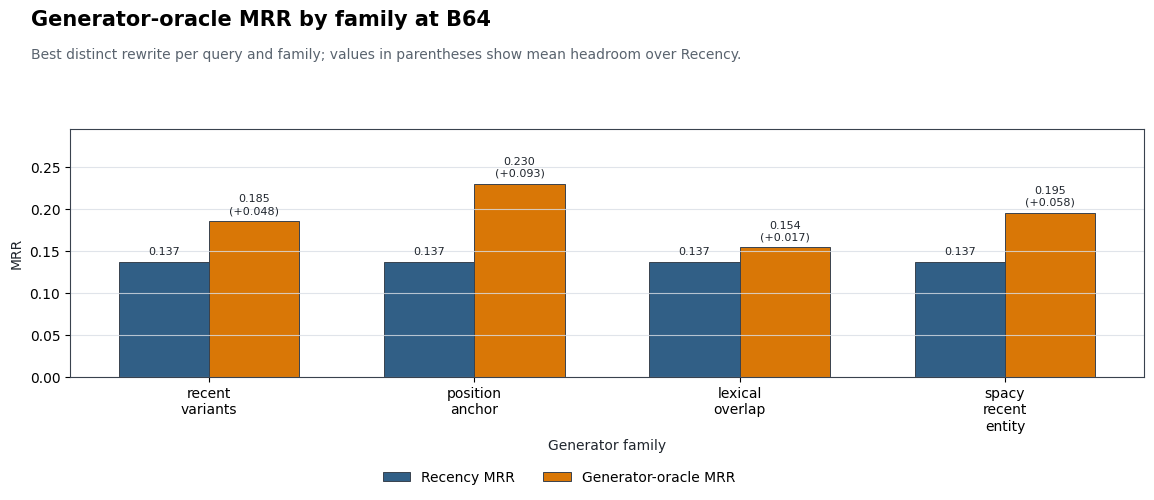

In [12]:
if REUSE_COMPLETE_ANALYSIS:
    generator_summary = load_result_frame("generator_summary")
    display(generator_summary.round(4))
else:
    generator_rewrites = rewrite_dedup_eval.loc[
        rewrite_dedup_eval["provenance_role"].eq("generator")
        & rewrite_dedup_eval["provenance_family"].isin(
            PRIMARY_GENERATOR_FAMILIES
        )
    ].copy()

    raw_k = (
        provenance_eval.loc[
            provenance_eval["provenance_role"].eq("generator")
            & provenance_eval["provenance_family"].isin(
                PRIMARY_GENERATOR_FAMILIES
            )
        ]
        .groupby(
            ["sample_id", "budget", "provenance_family"],
            observed=True,
        )["mask"]
        .nunique()
        .rename("raw_k")
        .reset_index()
    )
    effective_k = (
        generator_rewrites.groupby(
            ["sample_id", "budget", "provenance_family"],
            observed=True,
        )
        .size()
        .rename("effective_k_rewrite")
        .reset_index()
    )
    generator_best = (
        generator_rewrites.sort_values(
            [
                "sample_id",
                "budget",
                "provenance_family",
                "MRR",
                "provenance_rank",
                "mask",
            ],
            ascending=[True, True, True, False, True, True],
            kind="mergesort",
        )
        .drop_duplicates(
            ["sample_id", "budget", "provenance_family"],
            keep="first",
        )
        .rename(
            columns={
                "provenance_family": "generator_family",
                "mask": "winner_mask",
                "rewrite_norm": "winner_rewrite",
                **{
                    metric: f"generator_{metric}"
                    for metric in METRIC_COLUMNS
                },
            }
        )
    )

    generator_grid = pd.DataFrame(
        [
            {
                "sample_id": sample_id,
                "budget": budget,
                "generator_family": family,
            }
            for sample_id in population_ids
            for budget in BUDGETS
            for family in PRIMARY_GENERATOR_FAMILIES
        ]
    )
    recency_for_generator = recency_rows[
        ["sample_id", "budget", *METRIC_COLUMNS]
    ].rename(
        columns={metric: f"recency_{metric}" for metric in METRIC_COLUMNS}
    )
    generator_query = (
        generator_grid.merge(
            recency_for_generator,
            on=["sample_id", "budget"],
            how="left",
            validate="many_to_one",
        )
        .merge(
            generator_best[
                [
                    "sample_id",
                    "budget",
                    "generator_family",
                    "winner_mask",
                    "winner_rewrite",
                    *[f"generator_{metric}" for metric in METRIC_COLUMNS],
                ]
            ],
            on=["sample_id", "budget", "generator_family"],
            how="left",
            validate="one_to_one",
        )
        .merge(
            raw_k.rename(columns={"provenance_family": "generator_family"}),
            on=["sample_id", "budget", "generator_family"],
            how="left",
            validate="one_to_one",
        )
        .merge(
            effective_k.rename(columns={"provenance_family": "generator_family"}),
            on=["sample_id", "budget", "generator_family"],
            how="left",
            validate="one_to_one",
        )
        .merge(
            population_frame[
                [
                    "sample_id",
                    "conv_id",
                    "history_depth",
                    "depth_bin",
                    "topic_switch",
                ]
            ],
            on="sample_id",
            how="left",
            validate="many_to_one",
        )
    )
    generator_query[["raw_k", "effective_k_rewrite"]] = (
        generator_query[["raw_k", "effective_k_rewrite"]]
        .fillna(0)
        .astype(int)
    )
    generator_query["covered"] = generator_query["raw_k"].gt(0)
    generator_query["oracle_rr"] = np.fmax(
        generator_query["recency_MRR"],
        generator_query["generator_MRR"],
    )
    generator_query["headroom"] = (
        generator_query["oracle_rr"] - generator_query["recency_MRR"]
    )

    assert len(generator_query) == (
        EXPECTED_POPULATION_SIZE
        * len(BUDGETS)
        * len(PRIMARY_GENERATOR_FAMILIES)
    )
    assert generator_query["recency_MRR"].notna().all()
    assert generator_query["headroom"].ge(0).all()

    generator_summary = (
        generator_query.loc[generator_query["budget"].eq(PRIMARY_BUDGET)]
        .groupby("generator_family", observed=True)
        .agg(
            queries=("sample_id", "size"),
            coverage=("covered", "mean"),
            recency_mrr=("recency_MRR", "mean"),
            generator_oracle_mrr=("oracle_rr", "mean"),
            headroom=("headroom", "mean"),
            mean_raw_k=("raw_k", "mean"),
            mean_effective_k=("effective_k_rewrite", "mean"),
        )
        .reset_index()
    )
    display(generator_summary.round(4))

    generator_plot = (
        generator_summary.set_index("generator_family")
        .reindex(PRIMARY_GENERATOR_FAMILIES)
        .reset_index()
    )
    x = np.arange(len(generator_plot))
    bar_width = 0.34

    fig, ax = plt.subplots(figsize=(12, 5.8))
    recency_bars = ax.bar(
        x - bar_width / 2,
        generator_plot["recency_mrr"],
        width=bar_width,
        color=BLUE,
        edgecolor="#39424e",
        linewidth=0.7,
        label="Recency MRR",
    )
    oracle_bars = ax.bar(
        x + bar_width / 2,
        generator_plot["generator_oracle_mrr"],
        width=bar_width,
        color=ORANGE,
        edgecolor="#39424e",
        linewidth=0.7,
        label="Generator-oracle MRR",
    )

    ax.bar_label(
        recency_bars,
        labels=[f"{value:.3f}" for value in generator_plot["recency_mrr"]],
        padding=4,
        fontsize=8,
        color=INK,
    )
    ax.bar_label(
        oracle_bars,
        labels=[
            f"{oracle:.3f}\n(+{headroom:.3f})"
            for oracle, headroom in zip(
                generator_plot["generator_oracle_mrr"],
                generator_plot["headroom"],
                strict=True,
            )
        ],
        padding=4,
        fontsize=8,
        color=INK,
    )

    max_mrr = float(
        generator_plot[["recency_mrr", "generator_oracle_mrr"]]
        .to_numpy()
        .max()
    )
    ax.set_ylim(0, max(0.05, max_mrr * 1.28))
    ax.set_xticks(
        x,
        [
            str(family).replace("_", "\n")
            for family in generator_plot["generator_family"]
        ],
    )
    ax.set_ylabel("MRR")
    ax.set_xlabel("Generator family")
    ax.grid(axis="y", alpha=0.8)
    ax.grid(axis="x", visible=False)

    fig.suptitle(
        f"Generator-oracle MRR by family at B{PRIMARY_BUDGET}",
        x=0.06,
        y=0.99,
        ha="left",
        fontsize=15,
        fontweight="bold",
    )
    fig.text(
        0.06,
        0.925,
        (
            "Best distinct rewrite per query and family; values in parentheses "
            "show mean headroom over Recency."
        ),
        ha="left",
        va="top",
        color="#59636e",
    )
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.15),
        ncol=2,
    )
    fig.tight_layout(rect=(0.03, 0.20, 1, 0.87))
    plt.show()


At B64, `position_anchor` exposes the largest generator-specific oracle headroom: MRR increases from 0.1370 to 0.2303, corresponding to a gain of 0.0933. It covers every query and retains 6.22 distinct rewrites from 6.95 proposed masks on average.

`spacy_recent_entity` provides 0.0580 headroom with 99.17% coverage, while `recent_variants` provides 0.0484 with complete coverage. Both show substantial mask-to-rewrite collapse at B64: approximately six proposed masks produce only 2.3–2.5 distinct rewrites per query. `lexical_overlap` has the smallest headroom at 0.0173 and covers only 51% of queries. Abstentions fall back to Recency and therefore contribute zero headroom.

The family comparison is influenced by the number of effective candidates. `position_anchor` receives more opportunities to contain a high-RR rewrite than the other generators. Its larger oracle gain therefore demonstrates useful positional hypotheses, but does not by itself establish a superior deployable selector. A cardinality-adjusted comparison is required to separate generator quality from this best-of-many opportunity.

### Cardinality-matched null reservoirs

Generator-oracle headroom increases mechanically with the number of available candidates. A fair null comparison must therefore reproduce both the number of distinct generator rewrites and their mask cardinalities. Cardinality is retained because selecting one history turn is not directly comparable with selecting five turns.

For query $q_t$, budget $B$, generator $g$, and retained-turn count $h_{\mathrm{sel}}$, let $K_{q_t,B,g,h_{\mathrm{sel}}}$ denote the number of distinct generator rewrites. Summing these counts over $h_{\mathrm{sel}}$ gives the implementation's `effective_k_rewrite`; this local candidate count is distinct from the metric cutoff $k$. The desired control reservoir is

$$
N_{\mathrm{pool}}(q_t,B,g,h_{\mathrm{sel}})
=
\min\left[
\binom{h}{h_{\mathrm{sel}}},
\max\left(10,\;K_{q_t,B,g,h_{\mathrm{sel}}}+6\right)
\right]
$$

where $h$ is the history depth. The reservoir must contain at least $K_{q_t,B,g,h_{\mathrm{sel}}}$ rewrites for the matched comparison. The larger target provides additional draws for the subsequent Monte Carlo analysis.

The initial reservoir is constructed from the evaluated control-mask space. Distinctness is defined at rewrite level because different masks that produce the same normalized rewrite do not provide independent retrieval opportunities. If one rewrite can be produced at several cardinalities, a deterministic bipartite matching assigns it to only one pool. Required slots are filled before optional buffer slots.

Histories up to depth eight already contain every non-empty V1 mask. For deeper histories, the sampled control space may not provide enough distinct rewrites. Missing reservoirs are therefore refilled adaptively:

1. Missing rewrite counts are identified separately for each query, budget, generator family, and cardinality.
2. Previously unseen masks with the required cardinality are sampled using deterministic, stratum-specific random seeds.
3. Existing evaluations are reused when the same mask has already been processed.
4. New masks are serialized under the exact budget and evaluated through the cached IterCQR–BM25 pipeline.
5. Sampling continues until the target is met, the mask space is exhausted, or the limit of 128 additional masks per cardinality is reached.

The refill candidates are controls only and never enter the generator oracle.


In [13]:
if REUSE_COMPLETE_ANALYSIS:
    adaptive_null_refill_status = load_result_frame(
        "adaptive_null_refill_status"
    )
    refill_summary = load_result_frame("refill_summary")
    display(refill_summary)
else:
    MATCHED_NULL_REFILL_FAMILY = "matched_null_refill"

    generator_requirements_all_budgets: dict[
        tuple[int, str, str],
        dict[int, int],
    ] = {}
    for (budget, sample_id, family), group in generator_rewrites.groupby(
        ["budget", "sample_id", "provenance_family"],
        observed=True,
    ):
        generator_requirements_all_budgets[
            (int(budget), str(sample_id), str(family))
        ] = {
            int(cardinality): int(count)
            for cardinality, count in group["mask_true_count"].value_counts().items()
        }


    def null_reservoir_targets(
        requirements: dict[int, int],
        *,
        history_depth: int,
    ) -> dict[int, int]:
        return {
            cardinality: min(
                math.comb(history_depth, cardinality),
                max(
                    NULL_CONTROL_MIN_UNIQUE_REWRITES,
                    required + NULL_CONTROL_REWRITE_BUFFER,
                ),
            )
            for cardinality, required in requirements.items()
        }


    def add_null_control_membership(
        records_by_query_budget: dict[
            tuple[int, str],
            dict[str, dict[str, Any]],
        ],
        row: dict[str, Any],
    ) -> None:
        query_key = (int(row["budget"]), str(row["sample_id"]))
        rewrite_key = str(row["rewrite_key"])
        records = records_by_query_budget.setdefault(query_key, {})
        record = records.setdefault(
            rewrite_key,
            {
                "reward": float(row["MRR"]),
                "rewrite_norm": str(row["rewrite_norm"]),
                "cardinalities": set(),
            },
        )
        if not math.isclose(
            float(record["reward"]),
            float(row["MRR"]),
            rel_tol=0.0,
            abs_tol=1e-12,
        ):
            raise AssertionError(
                "A query-rewrite pair has inconsistent retrieval rewards."
            )
        record["cardinalities"].add(int(row["mask_true_count"]))


    def allocate_unique_control_rewrites(
        *,
        records: dict[str, dict[str, Any]],
        requirements: dict[int, int],
        desired_counts: dict[int, int],
        salt: str,
    ) -> tuple[
        dict[int, list[str]],
        dict[int, int],
        dict[int, int],
    ]:
        """Allocate globally distinct rewrites to cardinality-specific pools."""

        required = {
            int(cardinality): int(count)
            for cardinality, count in requirements.items()
            if int(count) > 0
        }
        desired = {
            cardinality: max(
                required[cardinality],
                int(desired_counts.get(cardinality, required[cardinality])),
            )
            for cardinality in required
        }
        if not required:
            return {}, {}, {}

        eligible_by_cardinality = {
            cardinality: sorted(
                [
                    rewrite_key
                    for rewrite_key, record in records.items()
                    if cardinality in record["cardinalities"]
                ],
                key=lambda rewrite_key: stable_sha1(
                    f"{salt}:{cardinality}:{rewrite_key}"
                ),
            )
            for cardinality in required
        }
        required_slots = [
            (cardinality, slot_index, "required")
            for cardinality in sorted(
                required,
                key=lambda value: (
                    len(eligible_by_cardinality[value]),
                    value,
                ),
            )
            for slot_index in range(required[cardinality])
        ]
        buffer_slots = [
            (cardinality, slot_index, "buffer")
            for cardinality in sorted(
                required,
                key=lambda value: (
                    len(eligible_by_cardinality[value]),
                    value,
                ),
            )
            for slot_index in range(
                required[cardinality],
                desired[cardinality],
            )
        ]
        slots = required_slots + buffer_slots
        match_by_rewrite: dict[str, int] = {}

        def augment(slot_index: int, seen_rewrites: set[str]) -> bool:
            cardinality = slots[slot_index][0]
            for rewrite_key in eligible_by_cardinality[cardinality]:
                if rewrite_key in seen_rewrites:
                    continue
                seen_rewrites.add(rewrite_key)
                previous_slot = match_by_rewrite.get(rewrite_key)
                if previous_slot is None or augment(
                    previous_slot,
                    seen_rewrites,
                ):
                    match_by_rewrite[rewrite_key] = slot_index
                    return True
            return False

        for slot_index in range(len(required_slots)):
            augment(slot_index, set())

        matched_slots = set(match_by_rewrite.values())
        missing_required = Counter(
            slots[slot_index][0]
            for slot_index in range(len(required_slots))
            if slot_index not in matched_slots
        )

        if not missing_required:
            for slot_index in range(
                len(required_slots),
                len(slots),
            ):
                augment(slot_index, set())

        matched_slots = set(match_by_rewrite.values())
        missing_desired = Counter(
            slots[slot_index][0]
            for slot_index in range(len(slots))
            if slot_index not in matched_slots
        )
        pools = {cardinality: [] for cardinality in required}
        for rewrite_key, slot_index in match_by_rewrite.items():
            pools[slots[slot_index][0]].append(rewrite_key)

        assigned_rewrites = set(match_by_rewrite)
        remaining_rewrites = sorted(
            set().union(*map(set, eligible_by_cardinality.values()))
            - assigned_rewrites,
            key=lambda rewrite_key: stable_sha1(
                f"{salt}:remaining:{rewrite_key}"
            ),
        )
        for rewrite_key in remaining_rewrites:
            eligible_cardinalities = [
                cardinality
                for cardinality in required
                if rewrite_key in eligible_by_cardinality[cardinality]
            ]
            if not eligible_cardinalities:
                continue
            chosen_cardinality = min(
                eligible_cardinalities,
                key=lambda cardinality: (
                    len(pools[cardinality])
                    / max(1, desired[cardinality]),
                    stable_sha1(
                        f"{salt}:assign:{rewrite_key}:{cardinality}"
                    ),
                ),
            )
            pools[chosen_cardinality].append(rewrite_key)

        for cardinality in pools:
            pools[cardinality] = sorted(
                pools[cardinality],
                key=lambda rewrite_key: stable_sha1(
                    f"{salt}:pool:{cardinality}:{rewrite_key}"
                ),
            )
        assigned = [
            rewrite_key
            for rewrite_keys in pools.values()
            for rewrite_key in rewrite_keys
        ]
        assert len(assigned) == len(set(assigned))
        return (
            pools,
            dict(missing_required),
            dict(missing_desired),
        )


    original_null_control_eval = (
        provenance_eval.loc[
            provenance_eval["budget"].isin(BUDGETS)
            & provenance_eval["provenance_role"].eq("control")
            & provenance_eval["provenance_family"].eq("mask_space"),
            [
                "candidate_id",
                "budget",
                "sample_id",
                "mask",
                "mask_true_count",
                "rewrite_key",
                "rewrite_norm",
                "MRR",
            ],
        ]
        .drop_duplicates(
            [
                "budget",
                "sample_id",
                "mask",
                "rewrite_key",
            ]
        )
        .reset_index(drop=True)
    )
    original_null_control_eval["sample_id"] = original_null_control_eval[
        "sample_id"
    ].astype(str)

    null_control_records_all_budgets: dict[
        tuple[int, str],
        dict[str, dict[str, Any]],
    ] = {}
    for row in original_null_control_eval.to_dict("records"):
        add_null_control_membership(
            null_control_records_all_budgets,
            row,
        )

    existing_mask_eval = (
        provenance_eval.loc[
            provenance_eval["budget"].isin(BUDGETS),
            [
                "candidate_id",
                "budget",
                "sample_id",
                "mask",
                "mask_true_count",
                "rewrite_key",
                "rewrite_norm",
                "MRR",
            ],
        ]
        .drop_duplicates(["budget", "sample_id", "mask"])
        .copy()
    )
    existing_mask_eval["sample_id"] = existing_mask_eval[
        "sample_id"
    ].astype(str)
    existing_mask_lookup = {
        (int(row.budget), str(row.sample_id), str(row.mask)): row
        for row in existing_mask_eval.itertuples(index=False)
    }
    candidate_templates = (
        candidate_frame.sort_values(
            ["sample_id", "candidate_id"],
            kind="mergesort",
        )
        .drop_duplicates("sample_id")
        .set_index("sample_id")
    )
    candidate_templates.index = candidate_templates.index.astype(str)


    def build_refill_candidate_frame(
        specs: Sequence[dict[str, Any]],
    ) -> pd.DataFrame:
        rows: list[dict[str, Any]] = []
        for rank, spec in enumerate(specs, start=1):
            sample_id = str(spec["sample_id"])
            budget = int(spec["budget"])
            mask = str(spec["mask"])
            cardinality = int(spec["mask_true_count"])
            digest = stable_sha1(
                f"{MATCHED_NULL_REFILL_FAMILY}:{budget}:{sample_id}:{mask}"
            )[:16]
            candidate_id = (
                f"{sample_id}::{MATCHED_NULL_REFILL_FAMILY}_"
                f"B{budget}_{digest}"
            )
            origin = (
                f"adaptive_B{budget}_c{cardinality}_"
                f"{digest}"
            )
            row = candidate_templates.loc[sample_id].to_dict()
            row.update(
                {
                    "candidate_id": candidate_id,
                    "sample_id": sample_id,
                    "mask": mask,
                    "mask_true_count": cardinality,
                    "mask_false_count": len(mask) - cardinality,
                    "mask_ratio": cardinality / len(mask),
                    "candidate_roles": ["control"],
                    "candidate_origins": [origin],
                    "candidate_origin_count": 1,
                    "generator_origins": [],
                    "generator_origin_count": 0,
                    "candidate_family": [MATCHED_NULL_REFILL_FAMILY],
                    "candidate_provenance": [
                        {
                            "role": "control",
                            "family": MATCHED_NULL_REFILL_FAMILY,
                            "origin": origin,
                            "rank": rank,
                        }
                    ],
                    "budget_family": "control",
                    "duplicate_count": 0,
                }
            )
            rows.append(row)
        return pd.DataFrame(rows).reindex(columns=candidate_frame.columns)


    def evaluate_new_refill_candidates(
        specs: Sequence[dict[str, Any]],
    ) -> pd.DataFrame:
        if not specs:
            return pd.DataFrame(
                columns=[
                    "candidate_id",
                    "budget",
                    "sample_id",
                    "mask",
                    "mask_true_count",
                    "rewrite_key",
                    "rewrite_norm",
                    "MRR",
                    "refill_source",
                    "control_family",
                ]
            )

        refill_candidates = build_refill_candidate_frame(specs)
        spec_frame = pd.DataFrame(specs)[
            ["budget", "sample_id", "mask", "mask_true_count"]
        ].copy()
        spec_frame["sample_id"] = spec_frame["sample_id"].astype(str)
        spec_frame["candidate_id"] = spec_frame.apply(
            lambda row: (
                f"{row['sample_id']}::{MATCHED_NULL_REFILL_FAMILY}_"
                f"B{int(row['budget'])}_"
                + stable_sha1(
                    ":".join(
                        [
                            MATCHED_NULL_REFILL_FAMILY,
                            str(int(row["budget"])),
                            str(row["sample_id"]),
                            str(row["mask"]),
                        ]
                    )
                )[:16]
            ),
            axis=1,
        )

        serialized_rows: list[dict[str, Any]] = []
        materialize_bar = progress(
            total=len(refill_candidates),
            desc="materialize matched-null refill",
            unit="mask",
        )
        for budget_value in sorted(spec_frame["budget"].unique()):
            budget = int(budget_value)
            budget_ids = set(
                spec_frame.loc[
                    spec_frame["budget"].eq(budget),
                    "candidate_id",
                ].astype(str)
            )
            budget_candidates = refill_candidates.loc[
                refill_candidates["candidate_id"].isin(budget_ids)
            ].copy()
            budget_data = replace(
                itercqr_data,
                tokenization_config=replace(
                    itercqr_data.tokenization_config,
                    max_input_tokens=budget,
                ),
            )
            candidate_loader = make_candidate_dataloader(
                data=budget_data,
                split=SPLIT,
                candidates=budget_candidates,
                batch_size=REWRITE_BATCH_SIZE,
            )
            dataset = candidate_loader.dataset
            for start in range(
                0,
                len(dataset),
                REWRITE_BATCH_SIZE,
            ):
                examples = [
                    dataset[index]
                    for index in range(
                        start,
                        min(
                            start + REWRITE_BATCH_SIZE,
                            len(dataset),
                        ),
                    )
                ]
                token_sequences = [
                    list(map(int, example.input_ids))
                    for example in examples
                ]
                input_keys = cached_pipeline.register_token_inputs(
                    token_sequences
                )
                for example, input_key in zip(
                    examples,
                    input_keys,
                    strict=True,
                ):
                    serialized_rows.append(
                        {
                            "candidate_id": str(
                                example.metadata["candidate_id"]
                            ),
                            "budget": budget,
                            "sample_id": str(
                                example.metadata[
                                    "original_sample_id"
                                ]
                            ),
                            "input_key": input_key,
                        }
                    )
                materialize_bar.update(len(examples))
        materialize_bar.close()

        serialized = pd.DataFrame(serialized_rows).merge(
            spec_frame,
            on=["candidate_id", "budget", "sample_id"],
            how="left",
            validate="one_to_one",
        )
        refill_evaluation = cached_pipeline.run(
            serialized,
            gold_by_sample=gold_by_sample,
            metric_columns=("MRR",),
            progress_prefix="matched-null",
        )
        evaluated = refill_evaluation.evaluated
        evaluated["refill_source"] = "new_candidate"
        evaluated["control_family"] = MATCHED_NULL_REFILL_FAMILY
        return evaluated[
            [
                "candidate_id",
                "budget",
                "sample_id",
                "mask",
                "mask_true_count",
                "rewrite_key",
                "rewrite_norm",
                "MRR",
                "refill_source",
                "control_family",
            ]
        ]

    def evaluate_refill_specs(
        specs: Sequence[dict[str, Any]],
    ) -> pd.DataFrame:
        reused_rows: list[dict[str, Any]] = []
        new_specs: list[dict[str, Any]] = []
        for spec in specs:
            lookup_key = (
                int(spec["budget"]),
                str(spec["sample_id"]),
                str(spec["mask"]),
            )
            cached_row = existing_mask_lookup.get(lookup_key)
            if cached_row is None:
                new_specs.append(spec)
                continue
            reused_rows.append(
                {
                    "candidate_id": str(cached_row.candidate_id),
                    "budget": int(spec["budget"]),
                    "sample_id": str(spec["sample_id"]),
                    "mask": str(spec["mask"]),
                    "mask_true_count": int(spec["mask_true_count"]),
                    "rewrite_key": str(cached_row.rewrite_key),
                    "rewrite_norm": str(cached_row.rewrite_norm),
                    "MRR": float(cached_row.MRR),
                    "refill_source": "existing_candidate",
                    "control_family": MATCHED_NULL_REFILL_FAMILY,
                }
            )
        parts = []
        if reused_rows:
            parts.append(pd.DataFrame(reused_rows))
        if new_specs:
            parts.append(evaluate_new_refill_candidates(new_specs))
        if not parts:
            return evaluate_new_refill_candidates([])
        return pd.concat(parts, ignore_index=True)


    history_depth_by_sample = (
        population_frame.set_index("sample_id")["history_depth"]
        .astype(int)
        .to_dict()
    )
    history_depth_by_sample = {
        str(sample_id): int(depth)
        for sample_id, depth in history_depth_by_sample.items()
    }
    attempted_masks: dict[tuple[int, str, int], set[str]] = {}
    for (budget, sample_id, cardinality), group in (
        original_null_control_eval.groupby(
            ["budget", "sample_id", "mask_true_count"],
            observed=True,
        )
    ):
        attempted_masks[
            (int(budget), str(sample_id), int(cardinality))
        ] = set(group["mask"].astype(str))

    refill_rngs: dict[tuple[int, str, int], random.Random] = {}
    refill_attempt_counts: Counter[tuple[int, str, int]] = Counter()


    def sample_unseen_refill_masks(
        *,
        budget: int,
        sample_id: str,
        cardinality: int,
        count: int,
    ) -> list[str]:
        history_depth = history_depth_by_sample[sample_id]
        key = (budget, sample_id, cardinality)
        seen = attempted_masks.setdefault(key, set())
        total_masks = math.comb(history_depth, cardinality)
        requested = min(count, max(0, total_masks - len(seen)))
        if requested == 0:
            return []
        rng = refill_rngs.setdefault(
            key,
            random.Random(
                f"{SEED}:{MATCHED_NULL_REFILL_FAMILY}:"
                f"{budget}:{sample_id}:{cardinality}"
            ),
        )
        selected_masks: list[str] = []
        max_random_attempts = max(2_000, requested * 500)
        random_attempts = 0
        while (
            len(selected_masks) < requested
            and random_attempts < max_random_attempts
        ):
            selected = set(
                rng.sample(range(history_depth), cardinality)
            )
            mask = "".join(
                "1" if index in selected else "0"
                for index in range(history_depth)
            )
            random_attempts += 1
            if mask in seen:
                continue
            seen.add(mask)
            selected_masks.append(mask)

        if (
            len(selected_masks) < requested
            and total_masks <= 200_000
        ):
            from itertools import combinations

            remaining = []
            for selected_tuple in combinations(
                range(history_depth),
                cardinality,
            ):
                selected = set(selected_tuple)
                mask = "".join(
                    "1" if index in selected else "0"
                    for index in range(history_depth)
                )
                if mask not in seen:
                    remaining.append(mask)
            rng.shuffle(remaining)
            for mask in remaining[
                : requested - len(selected_masks)
            ]:
                seen.add(mask)
                selected_masks.append(mask)
        return selected_masks


    deep_query_budget_pairs = [
        (int(budget), sample_id)
        for budget in BUDGETS
        for sample_id in population_ids
        if history_depth_by_sample[sample_id]
        > candidate_config.control_exhaustive_max_depth
    ]
    adaptive_rows: list[dict[str, Any]] = []
    refill_bar = progress(
        total=None,
        desc="adaptive matched-null refill",
        unit="mask",
    )
    while True:
        planned_specs: list[dict[str, Any]] = []
        active_target_pairs = 0
        for budget, sample_id in deep_query_budget_pairs:
            records = null_control_records_all_budgets.get(
                (budget, sample_id),
                {},
            )
            deficits_by_cardinality: dict[int, int] = {}
            for family in PRIMARY_GENERATOR_FAMILIES:
                requirements = generator_requirements_all_budgets.get(
                    (budget, sample_id, family),
                    {},
                )
                if not requirements:
                    continue
                desired_counts = null_reservoir_targets(
                    requirements,
                    history_depth=history_depth_by_sample[sample_id],
                )
                _, _, target_missing = allocate_unique_control_rewrites(
                    records=records,
                    requirements=requirements,
                    desired_counts=desired_counts,
                    salt=(
                        f"refill:{budget}:{sample_id}:{family}"
                    ),
                )
                if target_missing:
                    active_target_pairs += 1
                for cardinality, missing in target_missing.items():
                    deficits_by_cardinality[cardinality] = max(
                        deficits_by_cardinality.get(cardinality, 0),
                        int(missing),
                    )

            for cardinality, missing in sorted(
                deficits_by_cardinality.items()
            ):
                attempt_key = (budget, sample_id, cardinality)
                remaining_cap = (
                    NULL_REFILL_MAX_MASKS_PER_CARDINALITY
                    - refill_attempt_counts[attempt_key]
                )
                if remaining_cap <= 0:
                    continue
                requested = min(
                    remaining_cap,
                    max(
                        NULL_REFILL_BATCH_SIZE,
                        int(missing) * 2,
                    ),
                )
                masks = sample_unseen_refill_masks(
                    budget=budget,
                    sample_id=sample_id,
                    cardinality=cardinality,
                    count=requested,
                )
                refill_attempt_counts[attempt_key] += len(masks)
                planned_specs.extend(
                    {
                        "budget": budget,
                        "sample_id": sample_id,
                        "mask": mask,
                        "mask_true_count": cardinality,
                    }
                    for mask in masks
                )

        if not planned_specs:
            refill_bar.set_postfix_str(
                f"remaining targets={active_target_pairs}"
            )
            break

        evaluated_batch = evaluate_refill_specs(planned_specs)
        batch_rows = evaluated_batch.to_dict("records")
        adaptive_rows.extend(batch_rows)
        for row in batch_rows:
            add_null_control_membership(
                null_control_records_all_budgets,
                row,
            )
        refill_bar.update(len(planned_specs))
        refill_bar.set_postfix_str(
            f"remaining targets before batch={active_target_pairs}"
        )
    refill_bar.close()

    adaptive_null_control_eval = pd.DataFrame(
        adaptive_rows,
        columns=[
            "candidate_id",
            "budget",
            "sample_id",
            "mask",
            "mask_true_count",
            "rewrite_key",
            "rewrite_norm",
            "MRR",
            "refill_source",
            "control_family",
        ],
    )

    refill_status_rows: list[dict[str, Any]] = []
    for budget, sample_id in deep_query_budget_pairs:
        records = null_control_records_all_budgets.get(
            (budget, sample_id),
            {},
        )
        for family in PRIMARY_GENERATOR_FAMILIES:
            requirements = generator_requirements_all_budgets.get(
                (budget, sample_id, family),
                {},
            )
            if not requirements:
                continue
            desired_counts = null_reservoir_targets(
                requirements,
                history_depth=history_depth_by_sample[sample_id],
            )
            _, missing_required, missing_target = (
                allocate_unique_control_rewrites(
                    records=records,
                    requirements=requirements,
                    desired_counts=desired_counts,
                    salt=f"final:{budget}:{sample_id}:{family}",
                )
            )
            refill_status_rows.append(
                {
                    "budget": budget,
                    "sample_id": sample_id,
                    "generator_family": family,
                    "required_supported": not missing_required,
                    "buffer_target_met": not missing_target,
                    "missing_required": missing_required,
                    "missing_buffer_target": missing_target,
                }
            )
    adaptive_null_refill_status = pd.DataFrame(refill_status_rows)

    if not adaptive_null_control_eval.empty:
        assert adaptive_null_control_eval["control_family"].eq(
            MATCHED_NULL_REFILL_FAMILY
        ).all()
        assert adaptive_null_control_eval["MRR"].between(0, 1).all()
    assert not rewrite_dedup_eval["provenance_family"].eq(
        MATCHED_NULL_REFILL_FAMILY
    ).any()

    refill_summary = pd.DataFrame(
        [
            {
                "budget": int(budget),
                "sampled_refill_masks": int(
                    adaptive_null_control_eval["budget"].eq(budget).sum()
                ),
                "distinct_refill_rewrites": int(
                    adaptive_null_control_eval.loc[
                        adaptive_null_control_eval["budget"].eq(budget),
                        ["sample_id", "rewrite_key"],
                    ].drop_duplicates().shape[0]
                ),
                "required_unsupported_query_families": int(
                    (
                        adaptive_null_refill_status["budget"].eq(budget)
                        & ~adaptive_null_refill_status[
                            "required_supported"
                        ]
                    ).sum()
                ),
                "buffer_target_unmet_query_families": int(
                    (
                        adaptive_null_refill_status["budget"].eq(budget)
                        & ~adaptive_null_refill_status[
                            "buffer_target_met"
                        ]
                    ).sum()
                ),
            }
            for budget in BUDGETS
        ]
    )
    display(refill_summary)


adaptive matched-null refill: 0mask [00:00, ?mask/s]

materialize matched-null refill:   0%|          | 0/74630 [00:00<?, ?mask/s]

matched-null load rewrites cache keys:   0%|          | 0/452579 [00:00<?, ?key/s]

matched-null load rewrite cache:   0%|          | 0/78 [00:00<?, ?batch/s]

matched-null load retrievals cache keys:   0%|          | 0/393120 [00:00<?, ?key/s]

...

matched-null load rewrites cache keys:   0%|          | 0/452579 [00:00<?, ?key/s]

matched-null load rewrite cache:   0%|          | 0/1 [00:00<?, ?batch/s]

matched-null load retrievals cache keys:   0%|          | 0/393120 [00:00<?, ?key/s]

matched-null score retrieved rankings:   0%|          | 0/10 [00:00<?, ?query-rewrite/s]

,budget,sampled_refill_masks,distinct_refill_rewrites,required_unsupported_query_families,buffer_target_unmet_query_families
0,64,28447,11751,0,120
1,128,18761,13478,0,82
2,256,21945,15311,0,103
3,512,21996,15261,0,104


The adaptive refill provides sufficient mandatory null support at every budget. `required_unsupported_query_families = 0` means that every deep-history query–generator-family combination contains enough cardinality-matched, distinct control rewrites to reproduce the generator’s effective candidate count.

B64 requires the largest refill: 28,447 additional masks yield only 11,751 distinct query–rewrite pairs. This strong mask-to-rewrite collapse is consistent with aggressive truncation, under which many different masks produce the same IterCQR input or rewrite. At the larger budgets, approximately 19,000–22,000 refill masks yield 13,000–15,000 distinct rewrites.

The optional buffer target remains unmet for 82–120 query–family combinations per budget. These cases still satisfy the mandatory matched-null requirement, but do not reach the larger target of at least ten or $K_{q_t,B,g,h_{\mathrm{sel}}}+6$ control rewrites. The limitation can result from rewrite collapse, exhaustion of the available mask space, or the cap of 128 additional masks per cardinality.

The counts refer only to the adaptive refill and exclude control rewrites already present in the original reservoir.

### Cardinality-matched Monte Carlo correction

The raw generator oracle benefits from a best-of-many effect: a family that proposes more distinct rewrites has more opportunities to contain a high-RR candidate. The matched-null test estimates how much headroom would be expected from the same number and cardinality distribution of randomly selected control rewrites.

For every query $q_t$, budget $B$, generator $g$, and retained-turn count $h_{\mathrm{sel}}$, let $K_{q_t,B,g,h_{\mathrm{sel}}}$ be the number of distinct generator rewrites after rewrite deduplication. The preflight check, performed after the adaptive refill, verifies that the control reservoir contains at least $K_{q_t,B,g,h_{\mathrm{sel}}}$ globally distinct rewrites at every required cardinality.

Let $K_{q_t,B,g}=\sum_{h_{\mathrm{sel}}} K_{q_t,B,g,h_{\mathrm{sel}}}$. Null support is assessed among queries with $K_{q_t,B,g}>0$, meaning that the generator produced at least one effective rewrite. A generator–budget pair is valid when no more than 5% of these queries lack exact matched support:

$$
\text{exclusion rate}_{B,g}
=
\frac{
\text{unsupported queries with }K_{q_t,B,g}>0
}{
\text{all queries with }K_{q_t,B,g}>0
}
\leq 0.05
$$

A missing optional buffer does not invalidate the test as long as the mandatory $K_{q_t,B,g,h_{\mathrm{sel}}}$ rewrites are available. If the exclusion rate exceeds 5%, the complete generator–budget test is marked invalid and no inferential result is reported.

For each of $N_{\mathrm{MC}}=10{,}000$ Monte Carlo repetitions, exactly $K_{q_t,B,g,h_{\mathrm{sel}}}$ control rewrites are sampled without replacement from every required cardinality pool. The best sampled retrieval reward is compared with the same query’s Recency reward:

$$
\operatorname{Headroom}^{(s)}_{q_t,B,g}
=
\max\left(
0,\;
\max_{h_{\mathrm{sel}}}\max_{z\in\mathcal Z^{(s)}_{q_t,B,g,h_{\mathrm{sel}}}}
\mathrm{RR}(q_t,z)
-
\mathrm{RR}_{I_B}(q_t)
\right)
$$

Here $s$ indexes a Monte Carlo repetition and $\mathcal Z^{(s)}_{q_t,B,g,h_{\mathrm{sel}}}$ its sampled rewrite set. The query-level null headrooms are averaged to obtain one family-level null value per replicate. Generator abstentions have $K_{q_t,B,g}=0$ and contribute zero observed and null headroom. Unsupported queries with $K_{q_t,B,g}>0$ are excluded from the matched comparison.

The reported quantities are:

- **`headroom_matched`**: observed generator-oracle headroom over Recency on the matched query set
- **`null_headroom_mean`**: expected headroom from cardinality- and opportunity-matched random controls
- **`excess`**: observed headroom minus expected random headroom
- **`p_raw`** ($p_{\mathrm{MC}}$): one-sided Monte Carlo probability of obtaining at least the observed mean headroom under the matched null
- **`p_holm`** ($p_{\mathrm{Holm}}$): p-value adjusted across the four generator families within the same budget

Following Phipson and Smyth (2010), the one-sided Monte Carlo p-value is calculated as

$$
p_{\mathrm{MC}}=\frac{N_{\mathrm{MC},\geq}+1}{N_{\mathrm{MC}}+1}.
$$

Here $N_{\mathrm{MC},\geq}$ counts repetitions whose mean matched-random headroom reaches or exceeds the observed mean, and $N_{\mathrm{MC}}=10{,}000$. The added one prevents zero p-values and gives a minimum attainable value of $1/(N_{\mathrm{MC}}+1)$. Fixed random seeds and deterministic reservoir allocation make the procedure reproducible.

Because four generator families are tested within each budget, the raw Monte Carlo p-values are adjusted using Holm’s sequentially rejective procedure (Holm, 1979). For $G=4$ ordered p-values $p_{\mathrm{MC},(1)}\leq\cdots\leq p_{\mathrm{MC},(G)}$, the adjusted values are

$$
p_{\mathrm{Holm},(i)}
=
\min\left(
1,\;
\max_{1\leq j\leq i}
\left[
(G-j+1)p_{\mathrm{MC},(j)}
\right]
\right)
$$

Holm adjustment controls the family-wise probability of at least one false rejection across the four generator tests without requiring independence between them. It is applied separately within each budget. Consequently, it does not provide a joint correction across all 16 generator–budget comparisons.

Positive excess indicates that the generator exposes better retrieval candidates than expected from random masks with the same effective candidate count and cardinality structure. Since both the observed statistic and null statistic select their best candidate retrospectively, the result evaluates generator proposal quality and does not represent deployable selector performance.

preflight matched null support:   0%|          | 0/9600 [00:00<?, ?budget-query-family/s]

matched null Monte Carlo:   0%|          | 0/40000 [00:00<?, ?budget-draw/s]

finalize per-query null means:   0%|          | 0/9600 [00:00<?, ?budget-query-family/s]

,budget,generator_family,null_support_status,all_k_positive,unsupported_k_positive,reservoir_target_miss_k_positive,null_support_exclusion_rate,matched_n,headroom_matched,null_headroom_mean,excess,p_raw,p_holm
0,64,recent_variants,valid,600,0,82,0.0,600,0.04842,0.04455,0.00387,0.23458,0.70373
1,64,position_anchor,valid,600,0,306,0.0,600,0.09328,0.09611,-0.00283,0.67803,0.70373
2,64,lexical_overlap,valid,306,0,29,0.0,600,0.01734,0.01618,0.00115,0.35076,0.70373
3,64,spacy_recent_entity,valid,595,0,73,0.0,600,0.05795,0.04264,0.01531,0.00330,0.01320
4,128,recent_variants,valid,600,0,120,0.0,600,0.07172,0.06254,0.00918,0.06079,0.24318
5,128,position_anchor,valid,600,0,191,0.0,600,0.08028,0.09299,-0.01272,0.98320,1.00000
6,128,lexical_overlap,valid,306,0,21,0.0,600,0.01493,0.01562,-0.00069,0.56894,1.00000
7,128,spacy_recent_entity,valid,595,0,94,0.0,600,0.06726,0.05969,0.00757,0.09099,0.27297
8,256,recent_variants,valid,600,0,180,0.0,600,0.07747,0.06503,0.01244,0.01540,0.04620
9,256,position_anchor,valid,600,0,181,0.0,600,0.07642,0.08044,-0.00402,0.75322,0.75322


**Interpretation note:** At B64, `recent_variants` produces at least one mask candidate for each of the 600 queries that yields a rewrite and remains after rewrite deduplication. For 0 of these queries, the control space lacks enough globally distinct control rewrites after multi-label assignment and adaptive null refill to reproduce the number and cardinalities of the generator candidates within B64 exactly. For 600 queries, enough matching control candidates are available. Thus, `all_k_positive` has a different meaning from `unsupported_k_positive` and `matched_n`. The dashed line marks the required minimum support of 95.0%.

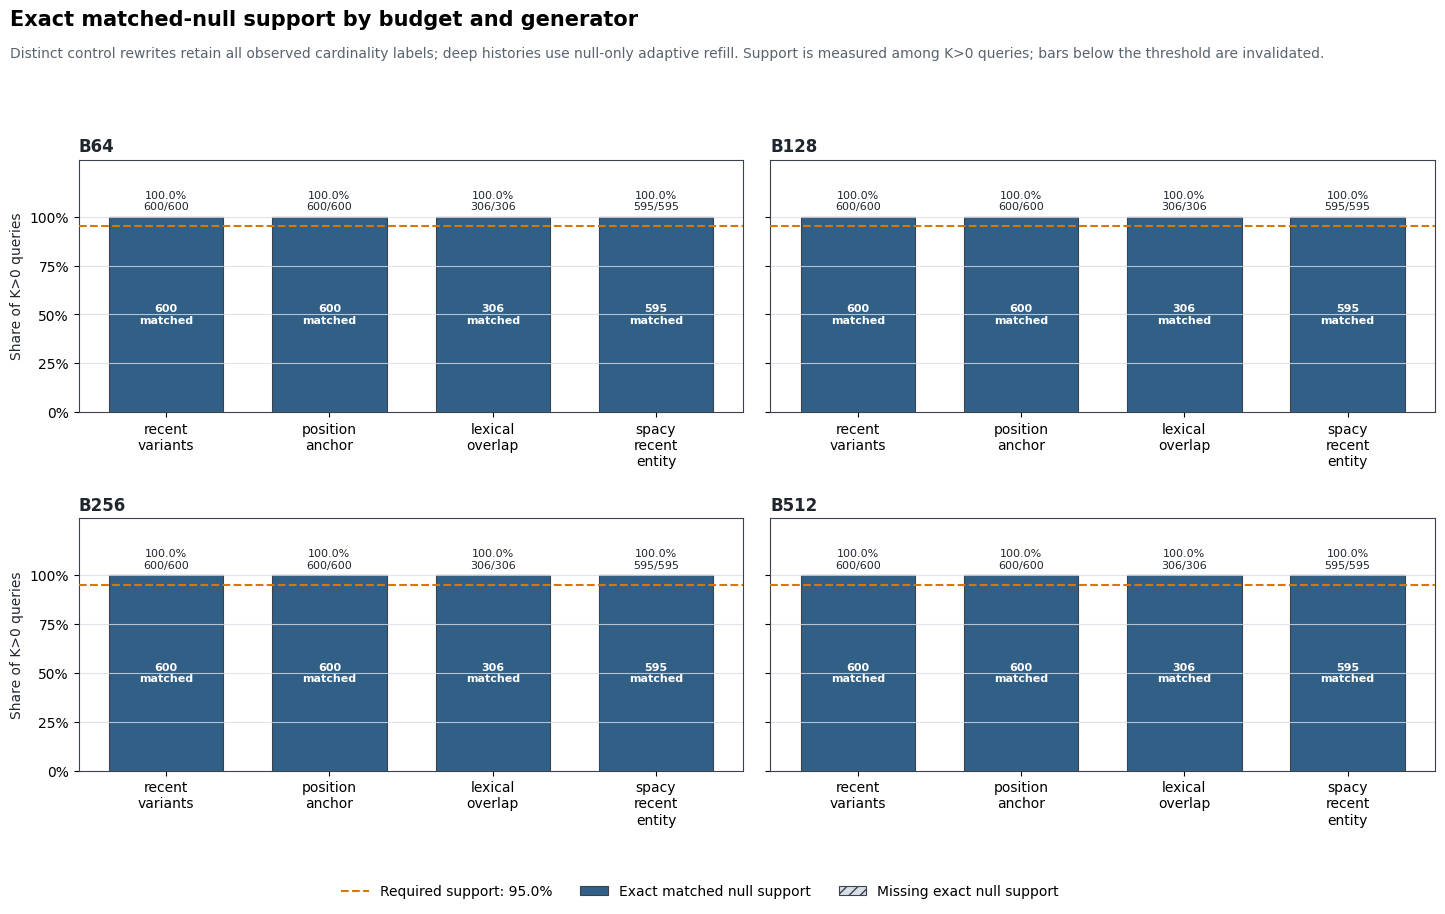

**Excess after the support check:** Only valid generator-budget pairs are shown. Excess is the observed generator headroom minus the expected exactly matched random headroom; the annotation reports the Holm-adjusted p-value.

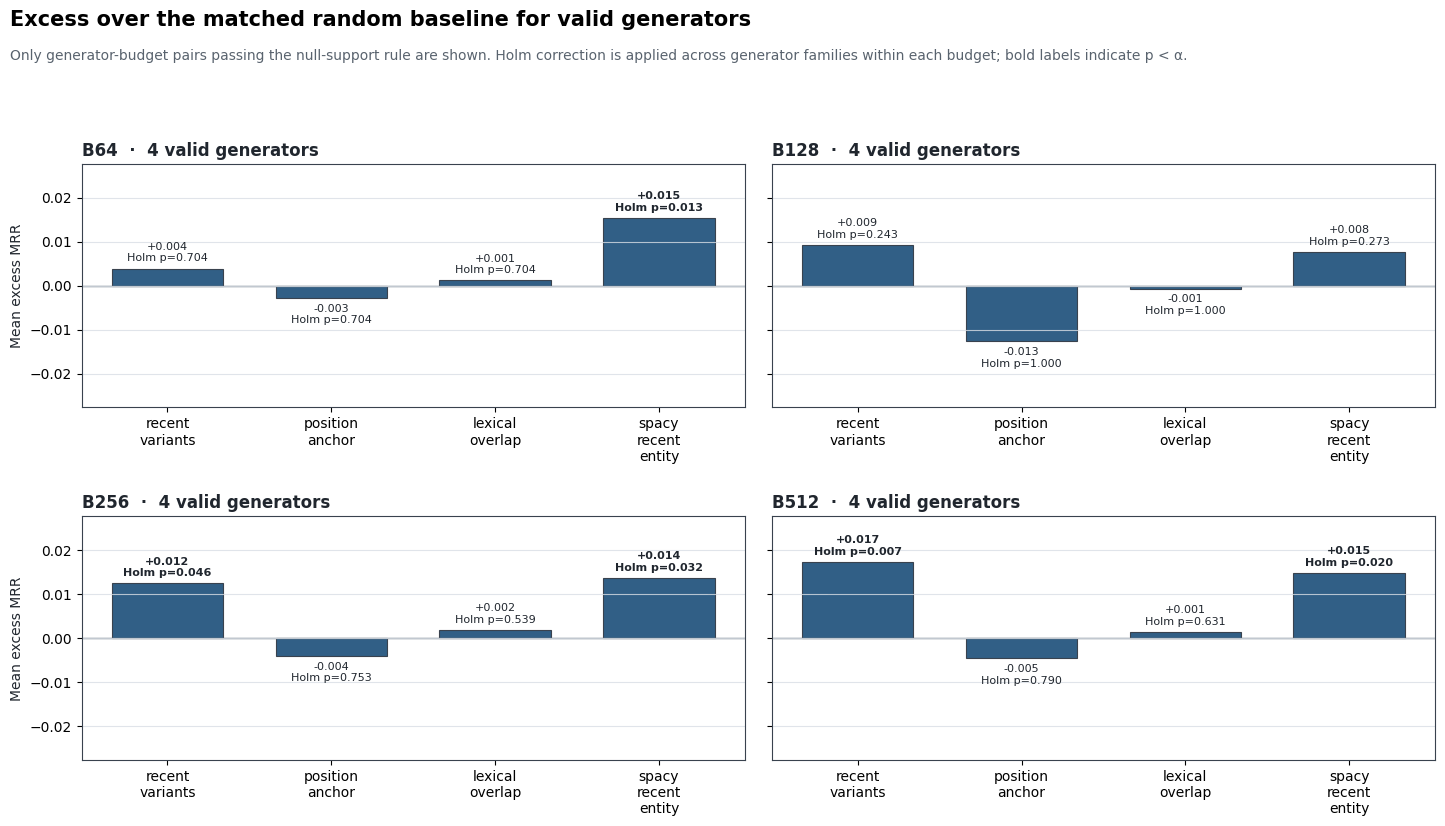

In [14]:
if REUSE_COMPLETE_ANALYSIS:
    mc_summary_all_budgets = load_result_frame("mc_summary_all_budgets")
    display(mc_summary_all_budgets.round(5))
else:
    generator_arms_all_budgets = generator_rewrites.loc[
        generator_rewrites["budget"].isin(BUDGETS)
    ].copy()
    control_pool_all_budgets = rewrite_dedup_eval.loc[
        rewrite_dedup_eval["budget"].isin(BUDGETS)
        & rewrite_dedup_eval["provenance_role"].eq("control")
        & rewrite_dedup_eval["provenance_family"].eq("mask_space")
    ].copy()
    generator_query_all_budgets = generator_query.loc[
        generator_query["budget"].isin(BUDGETS)
    ].copy()

    for frame in (
        generator_arms_all_budgets,
        control_pool_all_budgets,
        generator_query_all_budgets,
    ):
        frame["sample_id"] = frame["sample_id"].astype(str)

    generator_query_lookup_all_budgets = generator_query_all_budgets.set_index(
        ["budget", "sample_id", "generator_family"]
    )
    recency_lookup_all_budgets = {
        (int(row.budget), str(row.sample_id)): float(row.MRR)
        for row in recency_rows.loc[
            recency_rows["budget"].isin(BUDGETS)
        ].itertuples(index=False)
    }

    query_budget_family_triples = [
        (int(budget), sample_id, family)
        for budget in BUDGETS
        for sample_id in population_ids
        for family in PRIMARY_GENERATOR_FAMILIES
    ]
    support_rows: list[dict[str, Any]] = []
    control_rewards_all_budgets: dict[
        tuple[int, str, str],
        dict[int, np.ndarray],
    ] = {}
    control_rewrite_keys_all_budgets: dict[
        tuple[int, str, str],
        dict[int, list[str]],
    ] = {}
    support_bar = progress(
        query_budget_family_triples,
        total=len(query_budget_family_triples),
        desc="preflight matched null support",
        unit="budget-query-family",
    )
    for budget, sample_id, family in support_bar:
        requirements = generator_requirements_all_budgets.get(
            (budget, sample_id, family),
            {},
        )
        history_depth = history_depth_by_sample[sample_id]
        desired_counts = null_reservoir_targets(
            requirements,
            history_depth=history_depth,
        )
        records = null_control_records_all_budgets.get(
            (budget, sample_id),
            {},
        )
        pools, missing_required, missing_target = (
            allocate_unique_control_rewrites(
                records=records,
                requirements=requirements,
                desired_counts=desired_counts,
                salt=f"null:{budget}:{sample_id}:{family}",
            )
        )
        control_rewrite_keys_all_budgets[
            (budget, sample_id, family)
        ] = pools
        control_rewards_all_budgets[
            (budget, sample_id, family)
        ] = {
            cardinality: np.asarray(
                [
                    float(records[rewrite_key]["reward"])
                    for rewrite_key in rewrite_keys
                ],
                dtype=float,
            )
            for cardinality, rewrite_keys in pools.items()
        }
        support_rows.append(
            {
                "budget": budget,
                "sample_id": sample_id,
                "generator_family": family,
                "effective_k_rewrite": int(sum(requirements.values())),
                "matching_supported": not missing_required,
                "missing_by_cardinality": missing_required,
                "reservoir_target_met": not missing_target,
                "reservoir_target_shortfall": missing_target,
            }
        )
    null_support_all_budgets = pd.DataFrame(support_rows)

    shallow_support_check = null_support_all_budgets.merge(
        population_frame[
            ["sample_id", "history_depth"]
        ].assign(sample_id=lambda frame: frame["sample_id"].astype(str)),
        on="sample_id",
        how="left",
        validate="many_to_one",
    )
    assert shallow_support_check.loc[
        shallow_support_check["history_depth"].le(
            candidate_config.control_exhaustive_max_depth
        )
        & shallow_support_check["effective_k_rewrite"].gt(0),
        "matching_supported",
    ].all()

    null_support_exclusion_rate_threshold = float(
        MAX_NULL_SUPPORT_EXCLUSION_RATE
    )
    null_support_summary_rows: list[dict[str, Any]] = []
    family_status_by_budget: dict[tuple[int, str], str] = {}
    for budget in BUDGETS:
        for family in PRIMARY_GENERATOR_FAMILIES:
            family_rows = null_support_all_budgets.loc[
                null_support_all_budgets["budget"].eq(budget)
                & null_support_all_budgets["generator_family"].eq(family)
            ]
            positive_k = family_rows["effective_k_rewrite"].gt(0)
            denominator = int(positive_k.sum())
            excluded = int(
                (positive_k & ~family_rows["matching_supported"]).sum()
            )
            target_misses = int(
                (positive_k & ~family_rows["reservoir_target_met"]).sum()
            )
            exclusion_rate = excluded / denominator if denominator else np.nan
            if denominator == 0:
                status = "insufficient_coverage"
            elif exclusion_rate > null_support_exclusion_rate_threshold:
                status = "invalid_null_support"
            else:
                status = "valid"
            family_status_by_budget[(int(budget), family)] = status
            null_support_summary_rows.append(
                {
                    "budget": int(budget),
                    "generator_family": family,
                    "all_k_positive": denominator,
                    "unsupported_k_positive": excluded,
                    "reservoir_target_miss_k_positive": target_misses,
                    "null_support_exclusion_rate": exclusion_rate,
                    "null_support_status": status,
                }
            )
    null_support_summary_all_budgets = pd.DataFrame(
        null_support_summary_rows
    )


    def draw_null_headroom_chunk(
        *,
        rng: np.random.Generator,
        requirements: dict[int, int],
        pools: dict[int, np.ndarray],
        recency_rr: float,
        draws: int,
    ) -> np.ndarray:
        if not requirements:
            return np.zeros(draws, dtype=float)
        best_rr = np.full(draws, -np.inf, dtype=float)
        for cardinality, required in sorted(requirements.items()):
            rewards = np.asarray(pools[cardinality], dtype=float)
            if required > len(rewards):
                raise ValueError("Null pool does not satisfy exact matching.")
            if required == len(rewards):
                selected_best = np.full(draws, rewards.max(), dtype=float)
            elif required == 1:
                selected_best = rewards[
                    rng.integers(0, len(rewards), size=draws)
                ]
            else:
                random_scores = rng.random((draws, len(rewards)))
                indices = np.argpartition(
                    random_scores,
                    kth=required - 1,
                    axis=1,
                )[:, :required]
                selected_best = rewards[indices].max(axis=1)
            best_rr = np.maximum(best_rr, selected_best)
        return np.maximum(best_rr - float(recency_rr), 0.0)


    synthetic_rng_a = np.random.default_rng(7)
    synthetic_rng_b = np.random.default_rng(7)
    synthetic_kwargs = {
        "requirements": {2: 2},
        "pools": {2: np.array([0.1, 0.3, 0.7])},
        "recency_rr": 0.2,
        "draws": 200,
    }
    synthetic_a = draw_null_headroom_chunk(rng=synthetic_rng_a, **synthetic_kwargs)
    synthetic_b = draw_null_headroom_chunk(rng=synthetic_rng_b, **synthetic_kwargs)
    assert np.array_equal(synthetic_a, synthetic_b)
    assert synthetic_a.min() >= 0 and synthetic_a.max() <= 0.5

    valid_families_by_budget = {
        int(budget): [
            family
            for family in PRIMARY_GENERATOR_FAMILIES
            if family_status_by_budget[(int(budget), family)] == "valid"
        ]
        for budget in BUDGETS
    }
    family_test_samples_all_budgets: dict[
        tuple[int, str],
        list[str],
    ] = {}
    for budget in BUDGETS:
        for family in valid_families_by_budget[int(budget)]:
            family_rows = null_support_all_budgets.loc[
                null_support_all_budgets["budget"].eq(budget)
                & null_support_all_budgets["generator_family"].eq(family)
                & null_support_all_budgets["matching_supported"]
            ]
            family_test_samples_all_budgets[(int(budget), family)] = (
                family_rows["sample_id"].astype(str).tolist()
            )

    null_sums_all_budgets = {
        (budget, family, sample_id): 0.0
        for (budget, family), sample_ids in (
            family_test_samples_all_budgets.items()
        )
        for sample_id in sample_ids
    }
    null_sums_1000_all_budgets = {
        key: 0.0
        for key in null_sums_all_budgets
    }
    family_null_draw_means_all_budgets = {
        (budget, family): np.zeros(MC_REPLICATES, dtype=float)
        for budget, families in valid_families_by_budget.items()
        for family in families
    }

    mc_rng = np.random.default_rng(SEED + 10_000)
    mc_bar = progress(
        total=MC_REPLICATES * len(BUDGETS),
        desc="matched null Monte Carlo",
        unit="budget-draw",
    )
    for budget_value in BUDGETS:
        budget = int(budget_value)
        for start in range(0, MC_REPLICATES, MC_CHUNK_SIZE):
            end = min(start + MC_CHUNK_SIZE, MC_REPLICATES)
            draw_count = end - start
            first_1000_count = max(
                0,
                min(end, MC_ROBUST_REPLICATES) - start,
            )
            for family in valid_families_by_budget[budget]:
                family_sum = np.zeros(draw_count, dtype=float)
                sample_ids = family_test_samples_all_budgets[(budget, family)]
                for sample_id in sample_ids:
                    requirements = generator_requirements_all_budgets.get(
                        (budget, sample_id, family),
                        {},
                    )
                    pools = control_rewards_all_budgets[
                        (budget, sample_id, family)
                    ]
                    query_draws = draw_null_headroom_chunk(
                        rng=mc_rng,
                        requirements=requirements,
                        pools=pools,
                        recency_rr=recency_lookup_all_budgets[
                            (budget, sample_id)
                        ],
                        draws=draw_count,
                    )
                    key = (budget, family, sample_id)
                    null_sums_all_budgets[key] += float(query_draws.sum())
                    if first_1000_count:
                        null_sums_1000_all_budgets[key] += float(
                            query_draws[:first_1000_count].sum()
                        )
                    family_sum += query_draws
                family_null_draw_means_all_budgets[
                    (budget, family)
                ][start:end] = family_sum / len(sample_ids)
            mc_bar.update(draw_count)
    mc_bar.close()

    support_lookup_all_budgets = null_support_all_budgets.set_index(
        ["budget", "sample_id", "generator_family"]
    ).to_dict("index")
    null_query_rows: list[dict[str, Any]] = []
    finalize_bar = progress(
        query_budget_family_triples,
        total=len(query_budget_family_triples),
        desc="finalize per-query null means",
        unit="budget-query-family",
    )
    for budget, sample_id, family in finalize_bar:
        support = support_lookup_all_budgets[(budget, sample_id, family)]
        status = family_status_by_budget[(budget, family)]
        included = status == "valid" and bool(support["matching_supported"])
        if included:
            key = (budget, family, sample_id)
            null_mean = null_sums_all_budgets[key] / MC_REPLICATES
            null_mean_1000 = (
                null_sums_1000_all_budgets[key]
                / MC_ROBUST_REPLICATES
            )
        else:
            null_mean = np.nan
            null_mean_1000 = np.nan
        headroom = float(
            generator_query_lookup_all_budgets.loc[
                (budget, sample_id, family),
                "headroom",
            ]
        )
        null_query_rows.append(
            {
                "budget": budget,
                "sample_id": sample_id,
                "generator_family": family,
                "effective_k_rewrite": int(support["effective_k_rewrite"]),
                "matching_supported": bool(support["matching_supported"]),
                "included_in_null_test": included,
                "null_support_status": status,
                "headroom": headroom,
                "null_headroom_mean_qf": null_mean,
                "null_headroom_mean_qf_1000": null_mean_1000,
                "excess_qf": headroom - null_mean if included else np.nan,
            }
        )
    population_metadata = population_frame[
        [
            "sample_id",
            "conv_id",
            "history_depth",
            "depth_bin",
            "topic_switch",
        ]
    ].copy()
    population_metadata["sample_id"] = population_metadata["sample_id"].astype(str)
    null_query_means_all_budgets = (
        pd.DataFrame(null_query_rows)
        .merge(
            population_metadata,
            on="sample_id",
            how="left",
            validate="many_to_one",
        )
    )


    def holm_adjust(p_values: Sequence[float]) -> np.ndarray:
        values = np.asarray(p_values, dtype=float)
        order = np.argsort(values)
        sorted_values = values[order]
        factors = len(values) - np.arange(len(values))
        adjusted_sorted = np.maximum.accumulate(sorted_values * factors)
        adjusted_sorted = np.minimum(adjusted_sorted, 1.0)
        adjusted = np.empty_like(adjusted_sorted)
        adjusted[order] = adjusted_sorted
        return adjusted


    mc_summary_rows: list[dict[str, Any]] = []
    for budget_value in BUDGETS:
        budget = int(budget_value)
        for family in PRIMARY_GENERATOR_FAMILIES:
            support_summary = null_support_summary_all_budgets.loc[
                null_support_summary_all_budgets["budget"].eq(budget)
                & null_support_summary_all_budgets["generator_family"].eq(family)
            ].iloc[0]
            supported_ids = null_support_all_budgets.loc[
                null_support_all_budgets["budget"].eq(budget)
                & null_support_all_budgets["generator_family"].eq(family)
                & null_support_all_budgets["matching_supported"],
                "sample_id",
            ].astype(str)
            descriptive_matched = generator_query_all_budgets.loc[
                generator_query_all_budgets["budget"].eq(budget)
                & generator_query_all_budgets["generator_family"].eq(family)
                & generator_query_all_budgets["sample_id"].isin(supported_ids)
            ]
            status = family_status_by_budget[(budget, family)]
            if status == "valid":
                query_rows = null_query_means_all_budgets.loc[
                    null_query_means_all_budgets["budget"].eq(budget)
                    & null_query_means_all_budgets["generator_family"].eq(family)
                    & null_query_means_all_budgets["included_in_null_test"]
                ]
                observed = float(query_rows["headroom"].mean())
                null_mean = float(query_rows["null_headroom_mean_qf"].mean())
                excess = float(query_rows["excess_qf"].mean())
                null_draws = family_null_draw_means_all_budgets[
                    (budget, family)
                ]
                exceedances = int(np.count_nonzero(null_draws >= observed))
                p_raw = (exceedances + 1) / (MC_REPLICATES + 1)
                matched_n = len(query_rows)
            else:
                observed = (
                    float(descriptive_matched["headroom"].mean())
                    if not descriptive_matched.empty
                    else np.nan
                )
                null_mean = np.nan
                excess = np.nan
                p_raw = np.nan
                matched_n = len(descriptive_matched)
            mc_summary_rows.append(
                {
                    "budget": budget,
                    "generator_family": family,
                    "null_support_status": status,
                    "all_k_positive": int(support_summary["all_k_positive"]),
                    "unsupported_k_positive": int(
                        support_summary["unsupported_k_positive"]
                    ),
                    "reservoir_target_miss_k_positive": int(
                        support_summary["reservoir_target_miss_k_positive"]
                    ),
                    "null_support_exclusion_rate": support_summary[
                        "null_support_exclusion_rate"
                    ],
                    "matched_n": int(matched_n),
                    "headroom_matched": observed,
                    "null_headroom_mean": null_mean,
                    "excess": excess,
                    "p_raw": p_raw,
                }
            )
    mc_summary_all_budgets = pd.DataFrame(mc_summary_rows)
    mc_summary_all_budgets["p_holm"] = np.nan
    for budget_value in BUDGETS:
        budget = int(budget_value)
        selector = mc_summary_all_budgets["budget"].eq(budget)
        raw_p_values = mc_summary_all_budgets.loc[selector, "p_raw"]
        adjusted_p_values = holm_adjust(
            raw_p_values.fillna(1.0).to_numpy(dtype=float)
        )
        mc_summary_all_budgets.loc[selector, "p_holm"] = np.where(
            raw_p_values.notna().to_numpy(),
            adjusted_p_values,
            np.nan,
        )

    budget_rank = {int(budget): index for index, budget in enumerate(BUDGETS)}
    family_rank = {
        family: index
        for index, family in enumerate(PRIMARY_GENERATOR_FAMILIES)
    }
    mc_summary_all_budgets = (
        mc_summary_all_budgets.assign(
            _budget_rank=lambda frame: frame["budget"].map(budget_rank),
            _family_rank=lambda frame: frame["generator_family"].map(family_rank),
        )
        .sort_values(["_budget_rank", "_family_rank"], kind="mergesort")
        .drop(columns=["_budget_rank", "_family_rank"])
        .reset_index(drop=True)
    )

    assert len(mc_summary_all_budgets) == (
        len(BUDGETS) * len(PRIMARY_GENERATOR_FAMILIES)
    )
    assert mc_summary_all_budgets.groupby("budget", observed=True).size().eq(
        len(PRIMARY_GENERATOR_FAMILIES)
    ).all()
    assert mc_summary_all_budgets.loc[
        mc_summary_all_budgets["p_holm"].notna(),
        "p_holm",
    ].between(0, 1).all()
    assert mc_summary_all_budgets["p_holm"].isna().equals(
        mc_summary_all_budgets["p_raw"].isna()
    )

    # Backward-compatible B64 aliases for the existing downstream primary analysis.
    primary_generator_arms = generator_arms_all_budgets.loc[
        generator_arms_all_budgets["budget"].eq(PRIMARY_BUDGET)
    ].copy()
    primary_control_pool = control_pool_all_budgets.loc[
        control_pool_all_budgets["budget"].eq(PRIMARY_BUDGET)
    ].copy()
    primary_generator_query = generator_query_all_budgets.loc[
        generator_query_all_budgets["budget"].eq(PRIMARY_BUDGET)
    ].copy()
    generator_requirements = {
        (sample_id, family): requirements
        for (budget, sample_id, family), requirements in (
            generator_requirements_all_budgets.items()
        )
        if budget == PRIMARY_BUDGET
    }
    control_rewards = {
        (sample_id, family): pools
        for (budget, sample_id, family), pools in (
            control_rewards_all_budgets.items()
        )
        if budget == PRIMARY_BUDGET
    }
    primary_lookup = primary_generator_query.set_index(
        ["sample_id", "generator_family"]
    )
    recency_lookup = {
        sample_id: reward
        for (budget, sample_id), reward in recency_lookup_all_budgets.items()
        if budget == PRIMARY_BUDGET
    }
    null_support = (
        null_support_all_budgets.loc[
            null_support_all_budgets["budget"].eq(PRIMARY_BUDGET)
        ]
        .drop(columns="budget")
        .reset_index(drop=True)
    )
    null_support_summary = (
        null_support_summary_all_budgets.loc[
            null_support_summary_all_budgets["budget"].eq(PRIMARY_BUDGET)
        ]
        .drop(columns="budget")
        .reset_index(drop=True)
    )
    family_status = {
        family: family_status_by_budget[(PRIMARY_BUDGET, family)]
        for family in PRIMARY_GENERATOR_FAMILIES
    }
    valid_families = valid_families_by_budget[PRIMARY_BUDGET]
    family_test_samples = {
        family: family_test_samples_all_budgets[(PRIMARY_BUDGET, family)]
        for family in valid_families
    }
    null_sums = {
        (family, sample_id): value
        for (budget, family, sample_id), value in null_sums_all_budgets.items()
        if budget == PRIMARY_BUDGET
    }
    null_sums_1000 = {
        (family, sample_id): value
        for (budget, family, sample_id), value in (
            null_sums_1000_all_budgets.items()
        )
        if budget == PRIMARY_BUDGET
    }
    family_null_draw_means = {
        family: family_null_draw_means_all_budgets[(PRIMARY_BUDGET, family)]
        for family in valid_families
    }
    null_query_means = (
        null_query_means_all_budgets.loc[
            null_query_means_all_budgets["budget"].eq(PRIMARY_BUDGET)
        ]
        .drop(columns="budget")
        .reset_index(drop=True)
    )
    mc_summary = (
        mc_summary_all_budgets.loc[
            mc_summary_all_budgets["budget"].eq(PRIMARY_BUDGET)
        ]
        .drop(columns="budget")
        .reset_index(drop=True)
    )

    display(mc_summary_all_budgets.round(5))

    support_plot = mc_summary_all_budgets.copy()
    support_plot["matched_k_positive"] = (
        support_plot["all_k_positive"]
        - support_plot["unsupported_k_positive"]
    )
    support_plot["null_support_rate"] = np.divide(
        support_plot["matched_k_positive"],
        support_plot["all_k_positive"],
        out=np.full(len(support_plot), np.nan, dtype=float),
        where=support_plot["all_k_positive"].gt(0),
    )
    support_plot["missing_support_rate"] = (
        1.0 - support_plot["null_support_rate"]
    )
    required_null_support_rate = (
        1.0 - null_support_exclusion_rate_threshold
    )
    assert support_plot.loc[
        support_plot["all_k_positive"].gt(0),
        "null_support_rate",
    ].between(0, 1).all()
    assert support_plot["null_support_status"].eq(
        "invalid_null_support"
    ).equals(
        support_plot["null_support_rate"].lt(
            required_null_support_rate
        )
    )

    support_example = support_plot.loc[
        support_plot["budget"].eq(PRIMARY_BUDGET)
        & support_plot["generator_family"].eq("recent_variants")
    ].iloc[0]
    example_all_k_positive = int(support_example["all_k_positive"])
    example_unsupported = int(support_example["unsupported_k_positive"])
    example_matched_n = int(support_example["matched_n"])

    display(
        Markdown(
            f'**Interpretation note:** At B{PRIMARY_BUDGET}, `recent_variants` produces at least one mask candidate for each of the {example_all_k_positive} queries that yields a rewrite and remains after rewrite deduplication. For {example_unsupported} of these queries, the control space lacks enough globally distinct control rewrites after multi-label assignment and adaptive null refill to reproduce the number and cardinalities of the generator candidates within B{PRIMARY_BUDGET} exactly. For {example_matched_n} queries, enough matching control candidates are available. Thus, `all_k_positive` has a different meaning from `unsupported_k_positive` and `matched_n`. The dashed line marks the required minimum support of {required_null_support_rate:.1%}.'
        )
    )

    fig, support_axes = plt.subplots(
        2,
        2,
        figsize=(15, 9.2),
        sharey=True,
    )
    for ax, budget_value in zip(
        support_axes.flat,
        BUDGETS,
        strict=True,
    ):
        budget = int(budget_value)
        panel = (
            support_plot.loc[support_plot["budget"].eq(budget)]
            .set_index("generator_family")
            .reindex(PRIMARY_GENERATOR_FAMILIES)
            .reset_index()
        )
        x = np.arange(len(panel))
        matched_rates = panel["null_support_rate"].fillna(0).to_numpy()
        missing_rates = panel["missing_support_rate"].fillna(0).to_numpy()
        ax.bar(
            x,
            matched_rates,
            width=0.70,
            color=BLUE,
            edgecolor="#39424e",
            linewidth=0.8,
            label="Exact matched null support",
        )
        ax.bar(
            x,
            missing_rates,
            bottom=matched_rates,
            width=0.70,
            color="#d9dee5",
            edgecolor="#39424e",
            linewidth=0.8,
            hatch="///",
            label="Missing exact null support",
        )
        ax.axhline(
            required_null_support_rate,
            color=ORANGE,
            linewidth=1.5,
            linestyle="--",
            label=f"Required support: {required_null_support_rate:.1%}",
            zorder=4,
        )

        for index, row in enumerate(panel.itertuples(index=False)):
            total = int(row.all_k_positive)
            matched = int(row.matched_k_positive)
            missing = int(row.unsupported_k_positive)
            support_rate = float(row.null_support_rate)
            if total == 0 or not np.isfinite(support_rate):
                ax.text(
                    index,
                    0.04,
                    "no K>0\nqueries",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color=INK,
                )
                continue
            ax.text(
                index,
                min(max(support_rate / 2, 0.08), 0.88),
                f"{matched}\nmatched",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if support_rate >= 0.22 else INK,
                fontweight="bold",
            )
            if missing_rates[index] >= 0.10:
                ax.text(
                    index,
                    support_rate + missing_rates[index] / 2,
                    f"{missing}\nmissing",
                    ha="center",
                    va="center",
                    fontsize=7.5,
                    color=INK,
                )
            ax.text(
                index,
                1.025,
                f"{support_rate:.1%}\n{matched}/{total}",
                ha="center",
                va="bottom",
                fontsize=8,
                color=INK,
            )
            if row.null_support_status == "invalid_null_support":
                ax.text(
                    index,
                    1.165,
                    "INVALID",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color=ORANGE,
                    fontweight="bold",
                    bbox={
                        "boxstyle": "round,pad=0.2",
                        "facecolor": "white",
                        "edgecolor": ORANGE,
                        "linewidth": 1.0,
                    },
                )

        ax.set_xticks(
            x,
            [
                str(family).replace("_", "\n")
                for family in panel["generator_family"]
            ],
        )
        ax.set_ylim(0, 1.29)
        ax.set_yticks(
            np.linspace(0, 1, 5),
            ["0%", "25%", "50%", "75%", "100%"],
        )
        ax.set_title(f"B{budget}", loc="left", fontweight="bold")
        ax.grid(axis="y", alpha=0.8)
        ax.grid(axis="x", visible=False)

    for ax in support_axes[:, 0]:
        ax.set_ylabel("Share of K>0 queries")

    support_handles, support_labels = (
        support_axes.flat[0].get_legend_handles_labels()
    )
    fig.suptitle(
        "Exact matched-null support by budget and generator",
        x=0.04,
        y=0.995,
        ha="left",
        fontsize=15,
        fontweight="bold",
    )
    fig.text(
        0.04,
        0.955,
        (
            "Distinct control rewrites retain all observed cardinality labels; "
            "deep histories use null-only adaptive refill. Support is measured "
            "among K>0 queries; bars below the threshold are invalidated."
        ),
        ha="left",
        va="top",
        color="#59636e",
    )
    fig.legend(
        support_handles,
        support_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.015),
        ncol=3,
        frameon=False,
    )
    fig.tight_layout(rect=(0.03, 0.09, 1, 0.91), h_pad=2.0, w_pad=1.6)
    plt.show()

    valid_excess_plot = mc_summary_all_budgets.loc[
        mc_summary_all_budgets["null_support_status"].eq("valid")
        & mc_summary_all_budgets["excess"].notna()
        & mc_summary_all_budgets["p_holm"].notna()
    ].copy()
    assert valid_excess_plot["p_holm"].between(0, 1).all()

    display(
        Markdown(
            '**Excess after the support check:** Only valid generator-budget pairs are shown. Excess is the observed generator headroom minus the expected exactly matched random headroom; the annotation reports the Holm-adjusted p-value.'
        )
    )

    finite_excess = valid_excess_plot["excess"].to_numpy(dtype=float)
    excess_limit = max(
        0.01,
        float(np.max(np.abs(finite_excess))) * 1.60,
    )
    fig, excess_axes = plt.subplots(
        2,
        2,
        figsize=(15, 8.6),
        sharey=True,
    )
    for ax, budget_value in zip(
        excess_axes.flat,
        BUDGETS,
        strict=True,
    ):
        budget = int(budget_value)
        panel = (
            valid_excess_plot.loc[valid_excess_plot["budget"].eq(budget)]
            .set_index("generator_family")
            .reindex(PRIMARY_GENERATOR_FAMILIES)
            .dropna(subset=["excess"])
            .reset_index()
        )
        x = np.arange(len(panel))
        bars = ax.bar(
            x,
            panel["excess"].to_numpy(dtype=float),
            width=0.68,
            color=BLUE,
            edgecolor="#39424e",
            linewidth=0.8,
        )
        ax.axhline(0, color="#65727f", linewidth=1.0, zorder=1)

        for bar, row in zip(bars, panel.itertuples(index=False), strict=True):
            excess = float(row.excess)
            p_holm = float(row.p_holm)
            offset = excess_limit * 0.045
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                excess + (offset if excess >= 0 else -offset),
                f"{excess:+.3f}\nHolm p={p_holm:.3f}",
                ha="center",
                va="bottom" if excess >= 0 else "top",
                fontsize=8,
                color=INK,
                fontweight="bold" if p_holm < ALPHA else "normal",
            )

        ax.set_xticks(
            x,
            [
                str(family).replace("_", "\n")
                for family in panel["generator_family"]
            ],
        )
        ax.set_ylim(-excess_limit, excess_limit)
        ax.set_title(
            f"B{budget}  ·  {len(panel)} valid generators",
            loc="left",
            fontweight="bold",
        )
        ax.grid(axis="y", alpha=0.8)
        ax.grid(axis="x", visible=False)

    for ax in excess_axes[:, 0]:
        ax.set_ylabel("Mean excess MRR")

    fig.suptitle(
        "Excess over the matched random baseline for valid generators",
        x=0.04,
        y=0.995,
        ha="left",
        fontsize=15,
        fontweight="bold",
    )
    fig.text(
        0.04,
        0.95,
        (
            "Only generator-budget pairs passing the null-support rule are "
            "shown. Holm correction is applied across generator families "
            "within each budget; bold labels indicate p < α."
        ),
        ha="left",
        va="top",
        color="#59636e",
    )
    fig.tight_layout(rect=(0.03, 0.04, 1, 0.90), h_pad=2.2, w_pad=1.6)
    plt.show()


All 16 generator–budget combinations pass the mandatory null-support check following the preceding adaptive refill. No query with $K>0$ lacks the required number and cardinality distribution of distinct control rewrites, so the exclusion rate is zero throughout. The remaining reservoir-target misses concern only the optional buffer and do not represent exclusions.

`all_k_positive` reflects generator coverage. `lexical_overlap` produces effective candidates for 306 of 600 queries and `spacy_recent_entity` for 595. `matched_n` remains 600 because generator abstentions are retained with zero observed and zero null headroom. The reported effects are therefore query-weighted over the complete sample.

At the primary budget B64, only `spacy_recent_entity` exceeds its opportunity-matched random baseline after Holm correction (Holm, 1979). Its observed oracle headroom is 0.05795 MRR, while matched random masks provide 0.04264 expected headroom. The remaining excess is 0.01531 with $p_{\mathrm{Holm}}=0.01320$.

The large raw B64 headroom of `position_anchor` does not survive the matched comparison. Its observed headroom of 0.09328 is slightly below the random expectation of 0.09611, producing an excess of $-0.00283$. Its apparent generator-oracle advantage is therefore explained by the number and cardinality structure of its candidate opportunities. `recent_variants` and `lexical_overlap` also show no significant B64 excess.

The secondary budgets show the following pattern:

- At B128, no generator remains significant after Holm correction.
- At B256, `recent_variants` and `spacy_recent_entity` show positive excess with adjusted p-values of 0.04620 and 0.03160.
- At B512, both remain significant with adjusted p-values of 0.00720 and 0.01980.
- `position_anchor` and `lexical_overlap` show no significant excess at any budget.

Taken together, the results suggest two complementary forms of selection signal. Entity-bearing history provides the most consistent generator-specific signal across budgets. `spacy_recent_entity` has near-complete coverage and exceeds its matched random baseline at B64, B256, and B512. The heuristic itself is not query-conditioned: it selects recent turns containing suitable entities without relating those entities to the current query. The result therefore motivates a learned selector that combines entity-bearing context with semantic query conditioning. Exact entity surface-form matching is unlikely to provide this mechanism because 99.3% of sampling-eligible queries have no exact history-to-query entity anchor.

A complementary budget-dependent effect appears for `recent_variants`. Its excess increases monotonically from 0.00387 at B64 to 0.00918 at B128, 0.01244 at B256, and 0.01730 at B512. This pattern is consistent with an interaction between truncation and Recency-window length. At B64, aggressive truncation causes many nested recent-history windows to produce similar inputs and rewrites, reducing their effective diversity. At larger budgets, more of the differences between these windows are preserved. Selecting an appropriate window length can then restrict the admission of accumulated older context that may no longer be useful for the current query.

Since the null model matches the effective candidate count and cardinality distribution, the increasing excess of `recent_variants` cannot be explained solely by a larger best-of-many opportunity. In the direct paired comparison with B64, however, the increase is statistically supported only at B512. The result also does not establish that particular older turns are irrelevant. It shows that adaptive control over the amount of recent history becomes more useful when the available budget would otherwise admit more context.

Positive excess indicates that a generator contains better candidates than expected from random controls with the same effective candidate count and cardinality distribution. It does not represent deployable performance because the best candidate is selected retrospectively using retrieval outcomes.

### Query-level bootstrap uncertainty

Following Efron and Tibshirani (1993), sampling uncertainty is estimated using $N_{\mathrm{boot}}=10{,}000$ query-level percentile-bootstrap resamples, distinct from the $N_{\mathrm{MC}}$ matched-control repetitions. The query is the resampling unit because the 600-query sample is conversation-disjoint.

Recency differences are paired within each query against B512. Generator excess is the observed headroom minus the query-specific matched-null expectation. Changes across budgets are likewise calculated within each query relative to B64 before resampling. This pairing preserves query difficulty and directly estimates uncertainty in the differences.

The 95% confidence interval is formed from the empirical 2.5th and 97.5th percentiles.

paired bootstrap:   0%|          | 0/10000 [00:00<?, ?bootstrap draw/s]

paired excess deltas vs B64:   0%|          | 0/10000 [00:00<?, ?bootstrap draw/s]

,metric_type,generator_family,budget,n,mean,ci_low,ci_high
0,recency_delta,NaN,64,600,-0.04894,-0.06932,-0.02886
1,recency_delta,NaN,128,600,-0.01893,-0.03383,-0.00430
2,recency_delta,NaN,256,600,-0.00121,-0.00755,0.00487
3,recency_delta,NaN,512,600,0.00000,0.00000,0.00000
4,generator_headroom,recent_variants,64,600,0.04842,0.03474,0.06346
5,generator_headroom,position_anchor,64,600,0.09328,0.07498,0.11276
6,generator_headroom,lexical_overlap,64,600,0.01734,0.00985,0.02589
7,generator_headroom,spacy_recent_entity,64,600,0.05795,0.04289,0.07414
8,excess,recent_variants,64,600,0.00387,-0.00901,0.01744
9,excess,position_anchor,64,600,-0.00283,-0.01555,0.01037


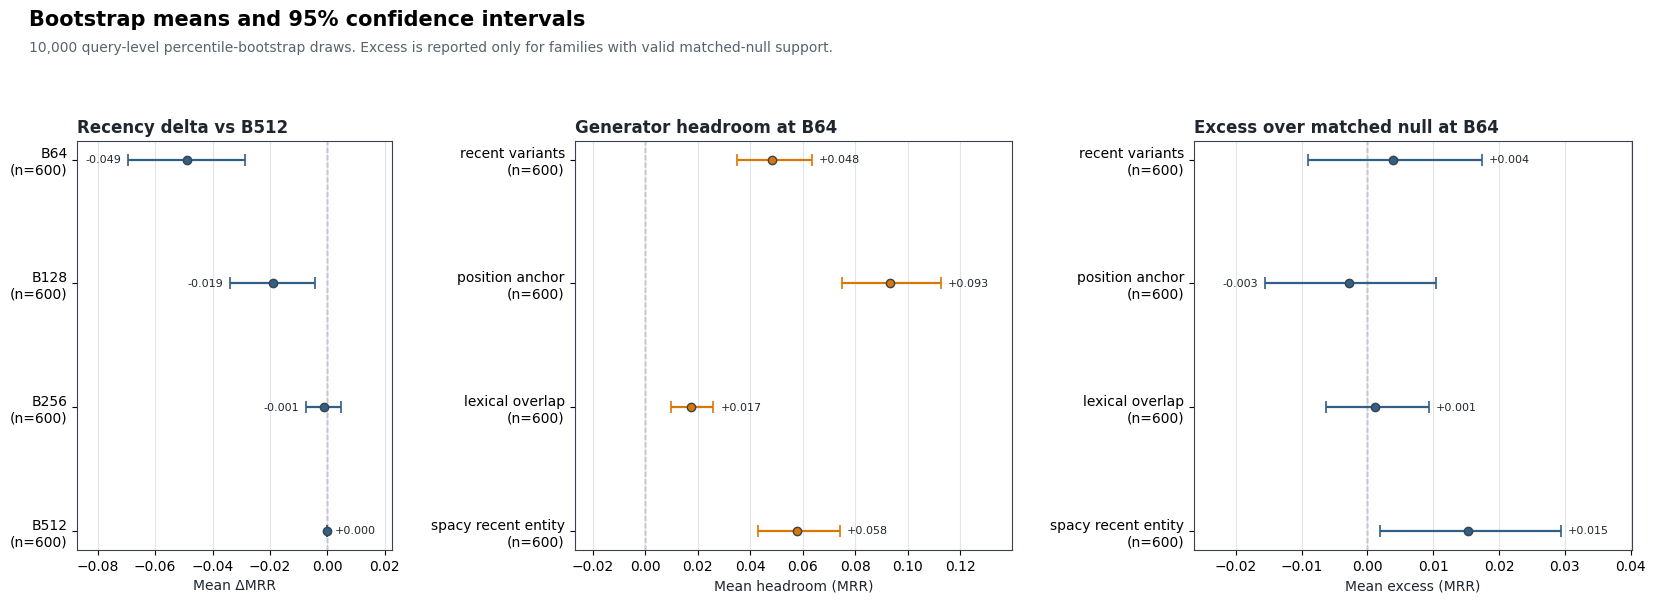

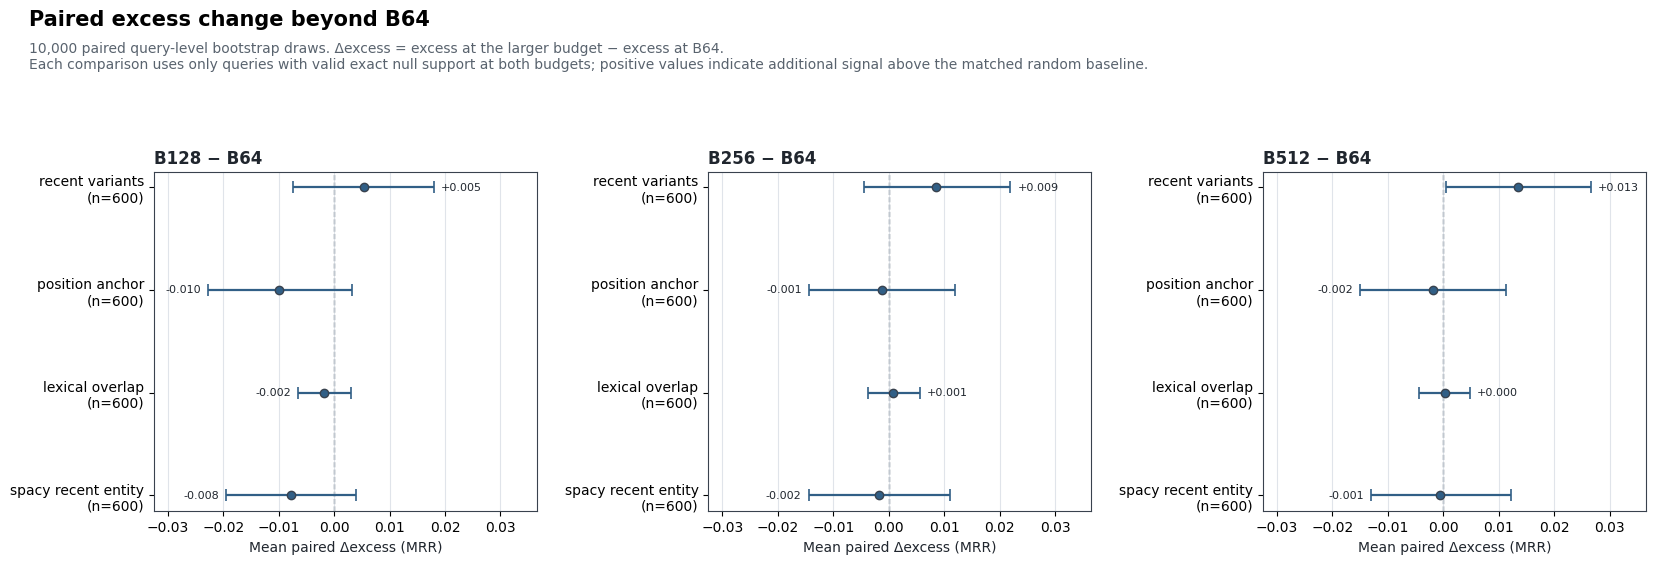

In [15]:
if REUSE_COMPLETE_ANALYSIS:
    bootstrap_summary = load_result_frame("bootstrap_summary")
    display(bootstrap_summary.round(5))
else:
    common_bootstrap_frame = pd.DataFrame({"sample_id": population_ids})
    for budget in BUDGETS:
        common_bootstrap_frame[f"recency_delta_B{budget}_vs_B512"] = (
            recency_wide.loc[population_ids, budget].to_numpy()
            - recency_wide.loc[population_ids, 512].to_numpy()
        )
    headroom_wide = (
        primary_generator_query.pivot(
            index="sample_id",
            columns="generator_family",
            values="headroom",
        )
        .reindex(index=population_ids, columns=PRIMARY_GENERATOR_FAMILIES)
    )
    for family in PRIMARY_GENERATOR_FAMILIES:
        common_bootstrap_frame[f"headroom::{family}"] = headroom_wide[
            family
        ].to_numpy()

    common_metric_columns = [
        column
        for column in common_bootstrap_frame.columns
        if column != "sample_id"
    ]
    common_values = common_bootstrap_frame[common_metric_columns].to_numpy(
        dtype=float
    )
    common_draws = {
        column: np.zeros(BOOTSTRAP_REPLICATES, dtype=float)
        for column in common_metric_columns
    }
    excess_values = {
        family: null_query_means.loc[
            null_query_means["generator_family"].eq(family)
            & null_query_means["included_in_null_test"],
            "excess_qf",
        ].to_numpy(dtype=float)
        for family in valid_families
    }
    excess_draws = {
        family: np.zeros(BOOTSTRAP_REPLICATES, dtype=float)
        for family in valid_families
    }

    comparison_budgets = [
        int(budget)
        for budget in BUDGETS
        if budget != PRIMARY_BUDGET
    ]
    primary_excess_rows = (
        null_query_means_all_budgets.loc[
            null_query_means_all_budgets["budget"].eq(PRIMARY_BUDGET)
            & null_query_means_all_budgets["included_in_null_test"],
            ["sample_id", "generator_family", "excess_qf"],
        ]
        .rename(columns={"excess_qf": "excess_primary"})
    )
    excess_budget_delta_values: dict[
        tuple[int, str],
        np.ndarray,
    ] = {}
    for budget in comparison_budgets:
        comparison_excess_rows = (
            null_query_means_all_budgets.loc[
                null_query_means_all_budgets["budget"].eq(budget)
                & null_query_means_all_budgets["included_in_null_test"],
                ["sample_id", "generator_family", "excess_qf"],
            ]
            .rename(columns={"excess_qf": "excess_comparison"})
        )
        for family in PRIMARY_GENERATOR_FAMILIES:
            paired_rows = (
                primary_excess_rows.loc[
                    primary_excess_rows["generator_family"].eq(family)
                ]
                .merge(
                    comparison_excess_rows.loc[
                        comparison_excess_rows["generator_family"].eq(family)
                    ],
                    on=["sample_id", "generator_family"],
                    how="inner",
                    validate="one_to_one",
                )
            )
            excess_budget_delta_values[(budget, family)] = (
                paired_rows["excess_comparison"]
                - paired_rows["excess_primary"]
            ).to_numpy(dtype=float)

    excess_budget_delta_draws = {
        key: np.zeros(BOOTSTRAP_REPLICATES, dtype=float)
        for key, values in excess_budget_delta_values.items()
        if len(values) > 0
    }

    bootstrap_rng = np.random.default_rng(SEED + 20_000)
    bootstrap_bar = progress(
        total=BOOTSTRAP_REPLICATES,
        desc="paired bootstrap",
        unit="bootstrap draw",
    )
    for start in range(0, BOOTSTRAP_REPLICATES, BOOTSTRAP_CHUNK_SIZE):
        end = min(start + BOOTSTRAP_CHUNK_SIZE, BOOTSTRAP_REPLICATES)
        draw_count = end - start
        common_indices = bootstrap_rng.integers(
            0,
            len(common_values),
            size=(draw_count, len(common_values)),
        )
        common_means = common_values[common_indices].mean(axis=1)
        for column_index, column in enumerate(common_metric_columns):
            common_draws[column][start:end] = common_means[:, column_index]
        for family, values in excess_values.items():
            indices = bootstrap_rng.integers(
                0,
                len(values),
                size=(draw_count, len(values)),
            )
            excess_draws[family][start:end] = values[indices].mean(axis=1)
        bootstrap_bar.update(draw_count)
    bootstrap_bar.close()

    excess_delta_rng = np.random.default_rng(SEED + 25_000)
    excess_delta_bar = progress(
        total=BOOTSTRAP_REPLICATES,
        desc=f"paired excess deltas vs B{PRIMARY_BUDGET}",
        unit="bootstrap draw",
    )
    for start in range(0, BOOTSTRAP_REPLICATES, BOOTSTRAP_CHUNK_SIZE):
        end = min(start + BOOTSTRAP_CHUNK_SIZE, BOOTSTRAP_REPLICATES)
        draw_count = end - start
        for key, draws in excess_budget_delta_draws.items():
            values = excess_budget_delta_values[key]
            indices = excess_delta_rng.integers(
                0,
                len(values),
                size=(draw_count, len(values)),
            )
            draws[start:end] = values[indices].mean(axis=1)
        excess_delta_bar.update(draw_count)
    excess_delta_bar.close()


    def percentile_interval(draws: np.ndarray) -> tuple[float, float]:
        low, high = np.quantile(draws, [ALPHA / 2, 1 - ALPHA / 2])
        return float(low), float(high)


    bootstrap_rows: list[dict[str, Any]] = []
    for column in common_metric_columns:
        low, high = percentile_interval(common_draws[column])
        if column.startswith("headroom::"):
            metric_type = "generator_headroom"
            family = column.split("::", 1)[1]
            budget = PRIMARY_BUDGET
        else:
            metric_type = "recency_delta"
            family = None
            budget = int(column.split("_B", 1)[1].split("_", 1)[0])
        bootstrap_rows.append(
            {
                "metric_type": metric_type,
                "generator_family": family,
                "budget": budget,
                "n": len(common_values),
                "mean": float(common_bootstrap_frame[column].mean()),
                "ci_low": low,
                "ci_high": high,
            }
        )
    primary_matched_n_by_family = (
        mc_summary.set_index("generator_family")["matched_n"]
        .astype(int)
        .to_dict()
    )
    for family in PRIMARY_GENERATOR_FAMILIES:
        matched_n = primary_matched_n_by_family[family]
        if family in excess_draws:
            low, high = percentile_interval(excess_draws[family])
            values = excess_values[family]
            assert len(values) == matched_n
            bootstrap_rows.append(
                {
                    "metric_type": "excess",
                    "generator_family": family,
                    "budget": PRIMARY_BUDGET,
                    "n": matched_n,
                    "mean": float(values.mean()),
                    "ci_low": low,
                    "ci_high": high,
                }
            )
        else:
            bootstrap_rows.append(
                {
                    "metric_type": "excess",
                    "generator_family": family,
                    "budget": PRIMARY_BUDGET,
                    "n": matched_n,
                    "mean": np.nan,
                    "ci_low": np.nan,
                    "ci_high": np.nan,
                }
            )

    for budget in comparison_budgets:
        for family in PRIMARY_GENERATOR_FAMILIES:
            key = (budget, family)
            values = excess_budget_delta_values[key]
            if key in excess_budget_delta_draws:
                low, high = percentile_interval(
                    excess_budget_delta_draws[key]
                )
                mean = float(values.mean())
                n = len(values)
            else:
                low = np.nan
                high = np.nan
                mean = np.nan
                n = 0
            bootstrap_rows.append(
                {
                    "metric_type": "excess_delta_vs_B64",
                    "generator_family": family,
                    "budget": budget,
                    "n": n,
                    "mean": mean,
                    "ci_low": low,
                    "ci_high": high,
                }
            )

    bootstrap_summary = pd.DataFrame(bootstrap_rows)
    assert bootstrap_summary.loc[
        bootstrap_summary["metric_type"].eq("generator_headroom"),
        "n",
    ].eq(EXPECTED_POPULATION_SIZE).all()
    display(bootstrap_summary.round(5))

    recency_interval_plot = (
        bootstrap_summary.loc[
            bootstrap_summary["metric_type"].eq("recency_delta")
        ]
        .set_index("budget")
        .reindex(BUDGETS)
        .reset_index()
    )
    headroom_interval_plot = (
        bootstrap_summary.loc[
            bootstrap_summary["metric_type"].eq("generator_headroom")
        ]
        .set_index("generator_family")
        .reindex(PRIMARY_GENERATOR_FAMILIES)
        .reset_index()
    )
    primary_null_support_plot = mc_summary[
        ["generator_family", "null_support_exclusion_rate"]
    ].copy()
    primary_null_support_plot["null_support_rate"] = (
        1.0 - primary_null_support_plot["null_support_exclusion_rate"]
    )
    primary_null_support_plot["required_null_support_rate"] = (
        1.0 - null_support_exclusion_rate_threshold
    )
    excess_interval_plot = (
        bootstrap_summary.loc[
            bootstrap_summary["metric_type"].eq("excess")
        ]
        .set_index("generator_family")
        .reindex(PRIMARY_GENERATOR_FAMILIES)
        .reset_index()
        .merge(
            primary_null_support_plot[
                [
                    "generator_family",
                    "null_support_rate",
                    "required_null_support_rate",
                ]
            ],
            on="generator_family",
            how="left",
            validate="one_to_one",
        )
    )


    def plot_bootstrap_intervals(
        ax: Any,
        frame: pd.DataFrame,
        *,
        labels: Sequence[str],
        title: str,
        xlabel: str,
        color: str,
    ) -> None:
        means = frame["mean"].to_numpy(dtype=float)
        lows = frame["ci_low"].to_numpy(dtype=float)
        highs = frame["ci_high"].to_numpy(dtype=float)
        valid = np.isfinite(means) & np.isfinite(lows) & np.isfinite(highs)
        y = np.arange(len(frame))

        ax.errorbar(
            means[valid],
            y[valid],
            xerr=np.vstack(
                [
                    means[valid] - lows[valid],
                    highs[valid] - means[valid],
                ]
            ),
            fmt="o",
            markersize=6,
            color=color,
            markerfacecolor=color,
            markeredgecolor="#39424e",
            ecolor=color,
            elinewidth=1.6,
            capsize=4,
            capthick=1.2,
            zorder=3,
        )
        ax.axvline(0, color="#65727f", linewidth=1.0, linestyle="--", zorder=1)

        finite_bounds = np.concatenate([lows[valid], highs[valid], np.array([0.0])])
        bound_min = float(finite_bounds.min())
        bound_max = float(finite_bounds.max())
        span = max(bound_max - bound_min, 0.01)
        padding = span * 0.24
        ax.set_xlim(bound_min - padding, bound_max + padding)

        for index in y[valid]:
            row = frame.iloc[index]
            if float(row["mean"]) < 0:
                x_value = float(row["ci_low"])
                x_offset = -5
                alignment = "right"
            else:
                x_value = float(row["ci_high"])
                x_offset = 5
                alignment = "left"
            ax.annotate(
                f"{float(row['mean']):+.3f}",
                xy=(x_value, index),
                xytext=(x_offset, 0),
                textcoords="offset points",
                ha=alignment,
                va="center",
                fontsize=8,
                color=INK,
            )

        for index in y[~valid]:
            row = frame.iloc[index]
            has_support_rates = (
                "null_support_rate" in frame.columns
                and "required_null_support_rate" in frame.columns
                and np.isfinite(row["null_support_rate"])
                and np.isfinite(row["required_null_support_rate"])
            )
            if has_support_rates:
                actual_support = float(row["null_support_rate"])
                required_support = float(
                    row["required_null_support_rate"]
                )
                relation = "<" if actual_support < required_support else "≥"
                unavailable_label = (
                    f"Null support: {actual_support:.1%} "
                    f"{relation} required {required_support:.1%}"
                )
            else:
                unavailable_label = "Estimate unavailable"
            ax.text(
                0.03,
                index,
                unavailable_label,
                transform=ax.get_yaxis_transform(),
                ha="left",
                va="center",
                fontsize=8,
                color="#65727f",
            )

        ax.set_yticks(y, labels)
        ax.invert_yaxis()
        ax.set_title(title, loc="left", fontweight="bold")
        ax.set_xlabel(xlabel)
        ax.grid(axis="x", alpha=0.8)
        ax.grid(axis="y", visible=False)


    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17, 6.2),
        gridspec_kw={"width_ratios": [0.9, 1.25, 1.25]},
    )
    plot_bootstrap_intervals(
        axes[0],
        recency_interval_plot,
        labels=[
            f"B{int(row.budget)}\n(n={int(row.n)})"
            for row in recency_interval_plot.itertuples(index=False)
        ],
        title="Recency delta vs B512",
        xlabel="Mean ΔMRR",
        color=BLUE,
    )
    plot_bootstrap_intervals(
        axes[1],
        headroom_interval_plot,
        labels=[
            f"{str(row.generator_family).replace('_', ' ')}\n(n={int(row.n)})"
            for row in headroom_interval_plot.itertuples(index=False)
        ],
        title=f"Generator headroom at B{PRIMARY_BUDGET}",
        xlabel="Mean headroom (MRR)",
        color=ORANGE,
    )
    plot_bootstrap_intervals(
        axes[2],
        excess_interval_plot,
        labels=[
            f"{str(row.generator_family).replace('_', ' ')}\n(n={int(row.n)})"
            for row in excess_interval_plot.itertuples(index=False)
        ],
        title=f"Excess over matched null at B{PRIMARY_BUDGET}",
        xlabel="Mean excess (MRR)",
        color=BLUE,
    )

    fig.suptitle(
        "Bootstrap means and 95% confidence intervals",
        x=0.04,
        y=0.995,
        ha="left",
        fontsize=15,
        fontweight="bold",
    )
    fig.text(
        0.04,
        0.945,
        (
            f"{BOOTSTRAP_REPLICATES:,} query-level percentile-bootstrap draws. "
            "Excess is reported only for families with valid matched-null support."
        ),
        ha="left",
        va="top",
        color="#59636e",
    )
    fig.tight_layout(rect=(0.02, 0.03, 1, 0.90), w_pad=2.2)
    plt.show()

    excess_delta_interval_plot = bootstrap_summary.loc[
        bootstrap_summary["metric_type"].eq("excess_delta_vs_B64")
    ].copy()

    fig, delta_axes = plt.subplots(
        1,
        len(comparison_budgets),
        figsize=(17, 5.8),
    )
    delta_axes = np.atleast_1d(delta_axes)
    for ax, budget in zip(
        delta_axes,
        comparison_budgets,
        strict=True,
    ):
        panel = (
            excess_delta_interval_plot.loc[
                excess_delta_interval_plot["budget"].eq(budget)
            ]
            .set_index("generator_family")
            .reindex(PRIMARY_GENERATOR_FAMILIES)
            .reset_index()
        )
        plot_bootstrap_intervals(
            ax,
            panel,
            labels=[
                (
                    f"{str(row.generator_family).replace('_', ' ')}"
                    f"\n(n={int(row.n)})"
                )
                for row in panel.itertuples(index=False)
            ],
            title=f"B{budget} − B{PRIMARY_BUDGET}",
            xlabel="Mean paired Δexcess (MRR)",
            color=BLUE,
        )

    finite_delta_bounds = excess_delta_interval_plot[
        ["ci_low", "ci_high"]
    ].to_numpy(dtype=float)
    finite_delta_bounds = finite_delta_bounds[
        np.isfinite(finite_delta_bounds)
    ]
    if finite_delta_bounds.size:
        delta_min = min(0.0, float(finite_delta_bounds.min()))
        delta_max = max(0.0, float(finite_delta_bounds.max()))
    else:
        delta_min = -0.01
        delta_max = 0.01
    delta_span = max(delta_max - delta_min, 0.01)
    delta_padding = delta_span * 0.20
    for ax in delta_axes:
        ax.set_xlim(
            delta_min - delta_padding,
            delta_max + delta_padding,
        )

    fig.suptitle(
        f"Paired excess change beyond B{PRIMARY_BUDGET}",
        x=0.04,
        y=0.995,
        ha="left",
        fontsize=15,
        fontweight="bold",
    )
    fig.text(
        0.04,
        0.94,
        (
            f"{BOOTSTRAP_REPLICATES:,} paired query-level bootstrap draws. "
            f"Δexcess = excess at the larger budget − excess at "
            f"B{PRIMARY_BUDGET}.\n"
            "Each comparison uses only queries with valid exact null support "
            "at both budgets; positive values indicate additional signal "
            "above the matched random baseline."
        ),
        ha="left",
        va="top",
        color="#59636e",
    )
    fig.tight_layout(rect=(0.02, 0.03, 1, 0.84), w_pad=2.0)
    plt.show()


Recency degrades significantly at B64 and B128 relative to B512, while B256 shows no supported difference.

At B64, only `spacy_recent_entity` retains positive excess after matched-null correction: 0.01531 MRR with a 95% CI of [0.00195, 0.02938]. Its excess does not differ significantly from B64 at the larger budgets, suggesting a comparatively stable entity-bearing signal.

The excess of `recent_variants` increases with the budget, but only B512 differs significantly from B64: +0.01343 MRR with a 95% CI of [0.00039, 0.02668]. This supports the interpretation that controlling the amount of older context becomes more important when larger budgets admit more history. Holm-adjusted Monte Carlo p-values remain the basis for family-wise inference.

### Topic-switch stratification

To examine whether retrieval effects vary with conversational topic drift, queries are grouped by their gold-derived topic-switch depth: `0`, `1`, or `2+` switches. The final bin combines deeper topic trajectories to retain sufficient observations.

Within each bin, the analysis reports Recency degradation relative to B512, raw generator headroom at B64, excess over the matched null at B64, and paired excess changes from B64 to larger budgets. Following Efron and Tibshirani (1993), each mean receives a 95% interval from 10,000 query-level percentile-bootstrap replicates with deterministic seeds.

bootstrap by topic-switch bin:   0%|          | 0/72 [00:00<?, ?group/s]

,metric_type,budget,generator_family,topic_switch_bin,n,mean,ci_low,ci_high
0,recency_delta,64,recency,0 switches,165,-0.06683,-0.10608,-0.02957
1,recency_delta,64,recency,1 switch,132,-0.02890,-0.07460,0.01680
2,recency_delta,64,recency,2+ switches,303,-0.04792,-0.07575,-0.02074
3,recency_delta,128,recency,0 switches,165,-0.03552,-0.06104,-0.01217
4,recency_delta,128,recency,1 switch,132,0.00325,-0.01522,0.02294
...,...,...,...,...,...,...,...,...
67,excess_delta_vs_B64,512,lexical_overlap,1 switch,132,-0.00711,-0.01706,0.00085
68,excess_delta_vs_B64,512,lexical_overlap,2+ switches,303,-0.00098,-0.00668,0.00488
69,excess_delta_vs_B64,512,spacy_recent_entity,0 switches,165,-0.01730,-0.03470,0.00006
70,excess_delta_vs_B64,512,spacy_recent_entity,1 switch,132,0.01585,-0.01317,0.04520


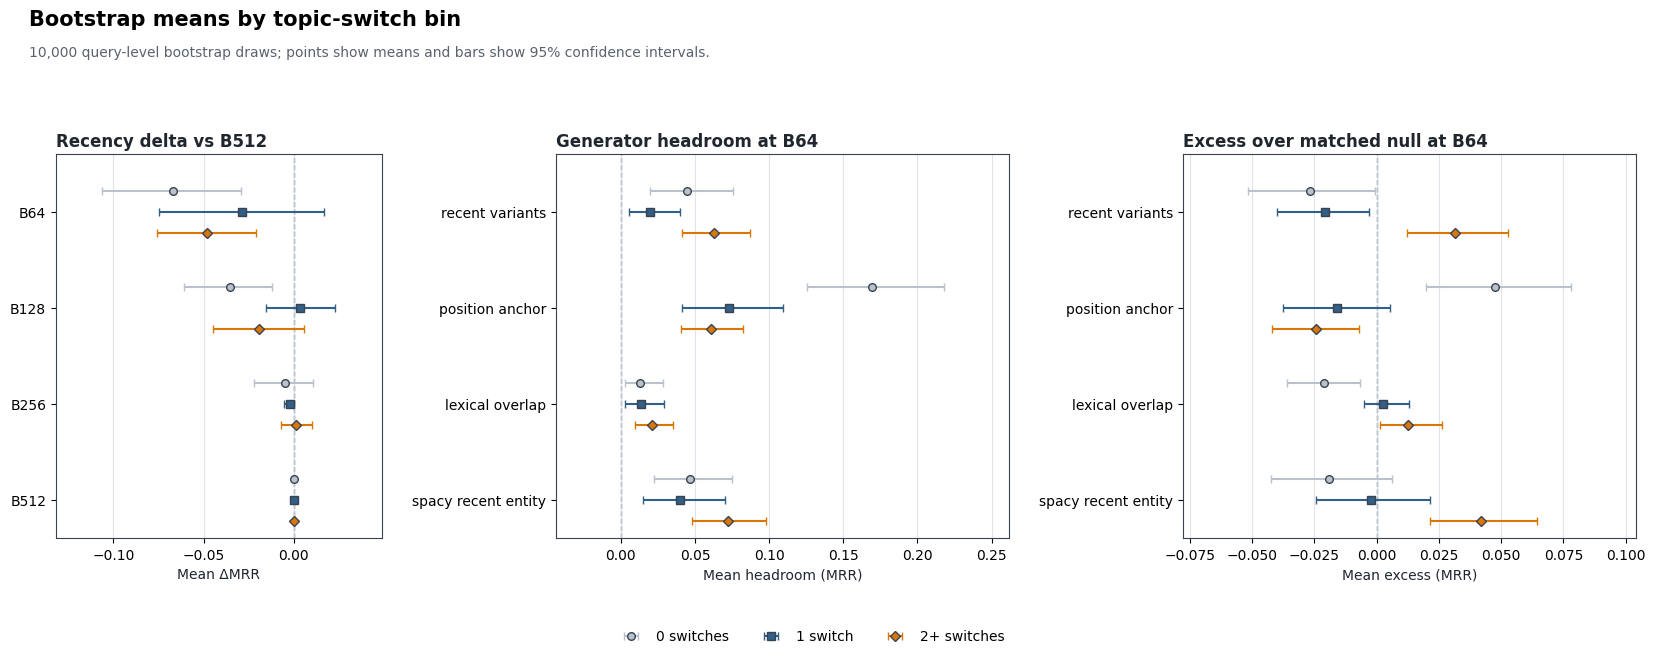

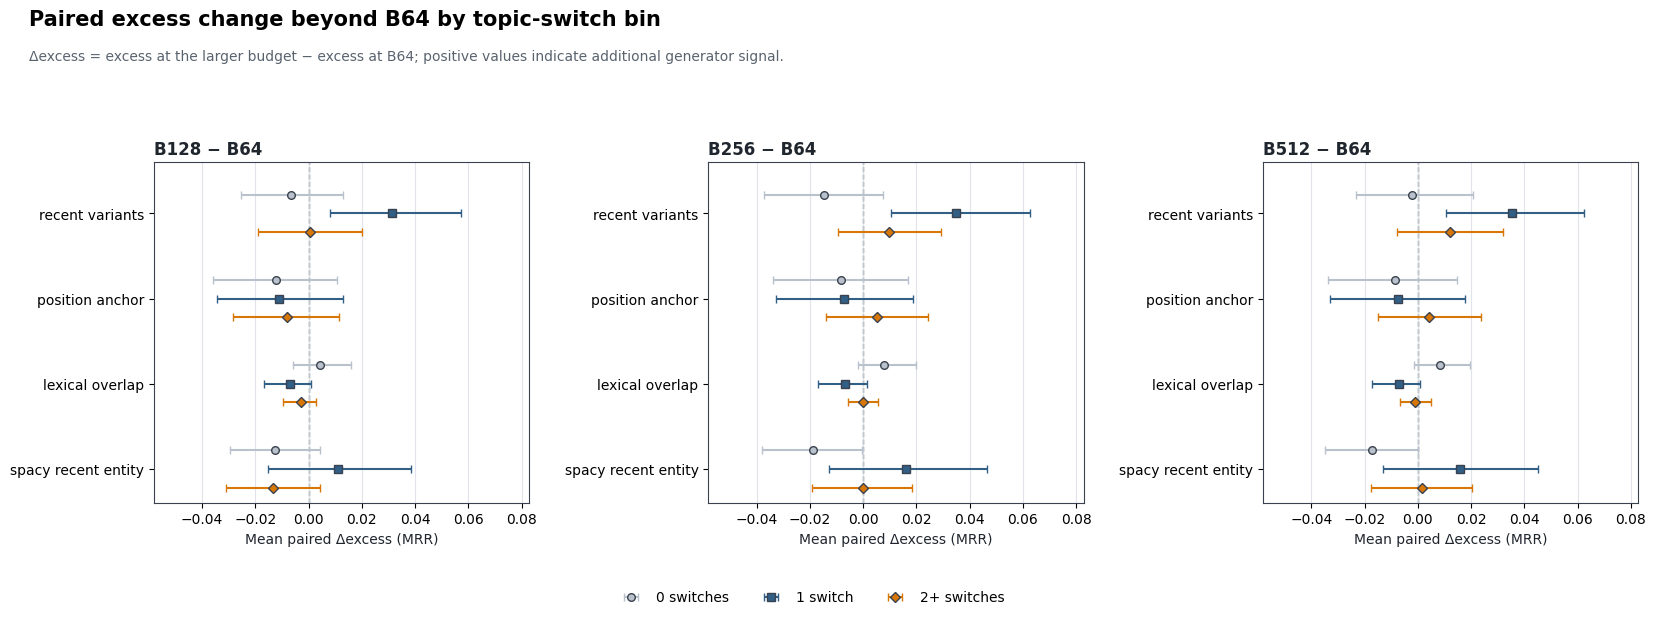

**Interpretation:** The three markers in each row represent queries with `0`, `1`, and `2+` topic switches. For excess, a value above 0 indicates generator-specific signal beyond matched randomness. For Δexcess, a value above 0 indicates that this signal increases relative to B64. The stratification is exploratory and applies no additional Holm correction across topic-switch bins.

In [16]:
if REUSE_COMPLETE_ANALYSIS:
    topic_switch_bootstrap_summary = load_result_frame(
        "topic_switch_bootstrap_summary"
    )
    display(topic_switch_bootstrap_summary.round(5))
else:
    # Bootstrap analysis across three topic-switch bins.

    assert "topic_switch_depth" in population_frame.columns

    topic_switch_bin_order = (
        "0 switches",
        "1 switch",
        "2+ switches",
    )
    topic_switch_metadata = population_frame[
        ["sample_id", "topic_switch_depth"]
    ].copy()
    topic_switch_metadata["sample_id"] = topic_switch_metadata[
        "sample_id"
    ].astype(str)
    topic_switch_metadata["topic_switch_depth"] = pd.to_numeric(
        topic_switch_metadata["topic_switch_depth"],
        errors="raise",
    ).astype(int)
    topic_switch_metadata["topic_switch_bin"] = pd.cut(
        topic_switch_metadata["topic_switch_depth"],
        bins=[-0.5, 0.5, 1.5, np.inf],
        labels=topic_switch_bin_order,
        ordered=True,
    )
    assert topic_switch_metadata["topic_switch_bin"].notna().all()

    topic_switch_metric_parts: list[pd.DataFrame] = []

    for budget_value in BUDGETS:
        budget = int(budget_value)
        recency_part = topic_switch_metadata[
            ["sample_id", "topic_switch_bin"]
        ].copy()
        recency_part["metric_type"] = "recency_delta"
        recency_part["generator_family"] = "recency"
        recency_part["budget"] = budget
        recency_part["value"] = (
            recency_wide.loc[
                recency_part["sample_id"],
                budget,
            ].to_numpy(dtype=float)
            - recency_wide.loc[
                recency_part["sample_id"],
                512,
            ].to_numpy(dtype=float)
        )
        topic_switch_metric_parts.append(recency_part)

    headroom_part = (
        primary_generator_query[
            ["sample_id", "generator_family", "headroom"]
        ]
        .assign(sample_id=lambda frame: frame["sample_id"].astype(str))
        .merge(
            topic_switch_metadata[
                ["sample_id", "topic_switch_bin"]
            ],
            on="sample_id",
            how="left",
            validate="many_to_one",
        )
        .rename(columns={"headroom": "value"})
    )
    headroom_part["metric_type"] = "generator_headroom"
    headroom_part["budget"] = int(PRIMARY_BUDGET)
    topic_switch_metric_parts.append(headroom_part)

    primary_excess_part = (
        null_query_means.loc[
            null_query_means["included_in_null_test"],
            ["sample_id", "generator_family", "excess_qf"],
        ]
        .assign(sample_id=lambda frame: frame["sample_id"].astype(str))
        .merge(
            topic_switch_metadata[
                ["sample_id", "topic_switch_bin"]
            ],
            on="sample_id",
            how="left",
            validate="many_to_one",
        )
        .rename(columns={"excess_qf": "value"})
    )
    primary_excess_part["metric_type"] = "excess"
    primary_excess_part["budget"] = int(PRIMARY_BUDGET)
    topic_switch_metric_parts.append(primary_excess_part)

    topic_switch_comparison_budgets = [
        int(budget)
        for budget in BUDGETS
        if int(budget) != int(PRIMARY_BUDGET)
    ]
    primary_excess_rows = (
        null_query_means_all_budgets.loc[
            null_query_means_all_budgets["budget"].eq(
                PRIMARY_BUDGET
            )
            & null_query_means_all_budgets[
                "included_in_null_test"
            ],
            ["sample_id", "generator_family", "excess_qf"],
        ]
        .assign(sample_id=lambda frame: frame["sample_id"].astype(str))
        .rename(columns={"excess_qf": "excess_primary"})
    )
    for budget in topic_switch_comparison_budgets:
        comparison_excess_rows = (
            null_query_means_all_budgets.loc[
                null_query_means_all_budgets["budget"].eq(budget)
                & null_query_means_all_budgets[
                    "included_in_null_test"
                ],
                ["sample_id", "generator_family", "excess_qf"],
            ]
            .assign(
                sample_id=lambda frame: frame["sample_id"].astype(str)
            )
            .rename(columns={"excess_qf": "excess_comparison"})
        )
        delta_part = (
            primary_excess_rows.merge(
                comparison_excess_rows,
                on=["sample_id", "generator_family"],
                how="inner",
                validate="one_to_one",
            )
            .merge(
                topic_switch_metadata[
                    ["sample_id", "topic_switch_bin"]
                ],
                on="sample_id",
                how="left",
                validate="many_to_one",
            )
        )
        delta_part["value"] = (
            delta_part["excess_comparison"]
            - delta_part["excess_primary"]
        )
        delta_part["metric_type"] = "excess_delta_vs_B64"
        delta_part["budget"] = budget
        topic_switch_metric_parts.append(
            delta_part[
                [
                    "sample_id",
                    "topic_switch_bin",
                    "generator_family",
                    "metric_type",
                    "budget",
                    "value",
                ]
            ]
        )

    topic_switch_metric_values = pd.concat(
        [
            part[
                [
                    "sample_id",
                    "topic_switch_bin",
                    "generator_family",
                    "metric_type",
                    "budget",
                    "value",
                ]
            ]
            for part in topic_switch_metric_parts
        ],
        ignore_index=True,
    )
    assert topic_switch_metric_values["topic_switch_bin"].notna().all()
    assert np.isfinite(
        topic_switch_metric_values["value"].to_numpy(dtype=float)
    ).all()


    def topic_switch_bootstrap_interval(
        values: np.ndarray,
        *,
        salt: str,
    ) -> tuple[float, float]:
        rng = np.random.default_rng(
            int(stable_sha1(f"{SEED}:{salt}")[:8], 16)
        )
        draws = np.zeros(BOOTSTRAP_REPLICATES, dtype=float)
        for start in range(
            0,
            BOOTSTRAP_REPLICATES,
            BOOTSTRAP_CHUNK_SIZE,
        ):
            end = min(
                start + BOOTSTRAP_CHUNK_SIZE,
                BOOTSTRAP_REPLICATES,
            )
            indices = rng.integers(
                0,
                len(values),
                size=(end - start, len(values)),
            )
            draws[start:end] = values[indices].mean(axis=1)
        return percentile_interval(draws)


    topic_switch_groups = list(
        topic_switch_metric_values.groupby(
            [
                "metric_type",
                "budget",
                "generator_family",
                "topic_switch_bin",
            ],
            observed=True,
            sort=True,
        )
    )
    topic_switch_rows: list[dict[str, Any]] = []
    topic_switch_bar = progress(
        total=len(topic_switch_groups),
        desc="bootstrap by topic-switch bin",
        unit="group",
    )
    for (
        metric_type,
        budget,
        family,
        switch_bin,
    ), group in topic_switch_groups:
        values = group["value"].to_numpy(dtype=float)
        low, high = topic_switch_bootstrap_interval(
            values,
            salt=(
                f"topic-switch:{metric_type}:{budget}:"
                f"{family}:{switch_bin}"
            ),
        )
        topic_switch_rows.append(
            {
                "metric_type": str(metric_type),
                "budget": int(budget),
                "generator_family": str(family),
                "topic_switch_bin": str(switch_bin),
                "n": len(values),
                "mean": float(values.mean()),
                "ci_low": low,
                "ci_high": high,
            }
        )
        topic_switch_bar.update(1)
    topic_switch_bar.close()

    metric_order = (
        "recency_delta",
        "generator_headroom",
        "excess",
        "excess_delta_vs_B64",
    )
    metric_rank = {
        metric: index
        for index, metric in enumerate(metric_order)
    }
    budget_rank = {
        int(budget): index
        for index, budget in enumerate(BUDGETS)
    }
    family_rank = {
        "recency": -1,
        **{
            family: index
            for index, family in enumerate(
                PRIMARY_GENERATOR_FAMILIES
            )
        },
    }
    switch_rank = {
        label: index
        for index, label in enumerate(topic_switch_bin_order)
    }
    topic_switch_bootstrap_summary = (
        pd.DataFrame(topic_switch_rows)
        .assign(
            _metric_rank=lambda frame: frame["metric_type"].map(
                metric_rank
            ),
            _budget_rank=lambda frame: frame["budget"].map(
                budget_rank
            ),
            _family_rank=lambda frame: frame[
                "generator_family"
            ].map(family_rank),
            _switch_rank=lambda frame: frame[
                "topic_switch_bin"
            ].map(switch_rank),
        )
        .sort_values(
            [
                "_metric_rank",
                "_budget_rank",
                "_family_rank",
                "_switch_rank",
            ],
            kind="mergesort",
        )
        .drop(
            columns=[
                "_metric_rank",
                "_budget_rank",
                "_family_rank",
                "_switch_rank",
            ]
        )
        .reset_index(drop=True)
    )
    display(topic_switch_bootstrap_summary.round(5))

    topic_switch_colors = {
        "0 switches": "#b9c1cc",
        "1 switch": "#315f86",
        "2+ switches": "#d97706",
    }
    topic_switch_markers = {
        "0 switches": "o",
        "1 switch": "s",
        "2+ switches": "D",
    }
    topic_switch_offsets = {
        "0 switches": -0.22,
        "1 switch": 0.0,
        "2+ switches": 0.22,
    }


    def plot_topic_switch_intervals(
        ax: Any,
        frame: pd.DataFrame,
        *,
        category_column: str,
        categories: Sequence[Any],
        labels: Sequence[str],
        title: str,
        xlabel: str,
    ) -> None:
        y = np.arange(len(categories), dtype=float)
        finite_bounds = [0.0]

        for switch_bin in topic_switch_bin_order:
            rows = (
                frame.loc[
                    frame["topic_switch_bin"].eq(switch_bin)
                ]
                .set_index(category_column)
                .reindex(categories)
            )
            means = rows["mean"].to_numpy(dtype=float)
            lows = rows["ci_low"].to_numpy(dtype=float)
            highs = rows["ci_high"].to_numpy(dtype=float)
            valid = (
                np.isfinite(means)
                & np.isfinite(lows)
                & np.isfinite(highs)
            )
            finite_bounds.extend(lows[valid])
            finite_bounds.extend(highs[valid])
            ax.errorbar(
                means[valid],
                y[valid] + topic_switch_offsets[switch_bin],
                xerr=np.vstack(
                    [
                        np.maximum(
                            means[valid] - lows[valid],
                            0,
                        ),
                        np.maximum(
                            highs[valid] - means[valid],
                            0,
                        ),
                    ]
                ),
                fmt=topic_switch_markers[switch_bin],
                markersize=5.5,
                color=topic_switch_colors[switch_bin],
                markerfacecolor=topic_switch_colors[switch_bin],
                markeredgecolor="#39424e",
                ecolor=topic_switch_colors[switch_bin],
                elinewidth=1.5,
                capsize=3,
                label=switch_bin,
                zorder=3,
            )

        bound_min = float(np.min(finite_bounds))
        bound_max = float(np.max(finite_bounds))
        span = max(bound_max - bound_min, 0.01)
        padding = span * 0.20
        ax.set_xlim(bound_min - padding, bound_max + padding)
        ax.axvline(
            0,
            color="#65727f",
            linewidth=1.0,
            linestyle="--",
            zorder=1,
        )
        ax.set_yticks(y, labels)
        ax.set_ylim(len(categories) - 0.6, -0.6)
        ax.set_title(title, loc="left", fontweight="bold")
        ax.set_xlabel(xlabel)
        ax.grid(axis="x", alpha=0.8)
        ax.grid(axis="y", visible=False)


    recency_topic_plot = topic_switch_bootstrap_summary.loc[
        topic_switch_bootstrap_summary["metric_type"].eq(
            "recency_delta"
        )
    ]
    headroom_topic_plot = topic_switch_bootstrap_summary.loc[
        topic_switch_bootstrap_summary["metric_type"].eq(
            "generator_headroom"
        )
    ]
    excess_topic_plot = topic_switch_bootstrap_summary.loc[
        topic_switch_bootstrap_summary["metric_type"].eq("excess")
    ]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17, 6.6),
        gridspec_kw={"width_ratios": [0.9, 1.25, 1.25]},
    )
    plot_topic_switch_intervals(
        axes[0],
        recency_topic_plot,
        category_column="budget",
        categories=list(map(int, BUDGETS)),
        labels=[f"B{int(budget)}" for budget in BUDGETS],
        title="Recency delta vs B512",
        xlabel="Mean ΔMRR",
    )
    plot_topic_switch_intervals(
        axes[1],
        headroom_topic_plot,
        category_column="generator_family",
        categories=list(PRIMARY_GENERATOR_FAMILIES),
        labels=[
            family.replace("_", " ")
            for family in PRIMARY_GENERATOR_FAMILIES
        ],
        title=f"Generator headroom at B{PRIMARY_BUDGET}",
        xlabel="Mean headroom (MRR)",
    )
    plot_topic_switch_intervals(
        axes[2],
        excess_topic_plot,
        category_column="generator_family",
        categories=list(PRIMARY_GENERATOR_FAMILIES),
        labels=[
            family.replace("_", " ")
            for family in PRIMARY_GENERATOR_FAMILIES
        ],
        title=f"Excess over matched null at B{PRIMARY_BUDGET}",
        xlabel="Mean excess (MRR)",
    )

    handles, labels = axes[0].get_legend_handles_labels()
    fig.suptitle(
        "Bootstrap means by topic-switch bin",
        x=0.04,
        y=0.99,
        ha="left",
        fontsize=15,
        fontweight="bold",
    )
    fig.text(
        0.04,
        0.935,
        (
            f"{BOOTSTRAP_REPLICATES:,} query-level bootstrap draws; "
            "points show means and bars show 95% confidence intervals."
        ),
        ha="left",
        va="top",
        color="#59636e",
    )
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=3,
        frameon=False,
    )
    fig.tight_layout(rect=(0.02, 0.10, 1, 0.88), w_pad=2.2)
    plt.show()

    delta_topic_plot = topic_switch_bootstrap_summary.loc[
        topic_switch_bootstrap_summary["metric_type"].eq(
            "excess_delta_vs_B64"
        )
    ]
    fig, delta_axes = plt.subplots(
        1,
        len(topic_switch_comparison_budgets),
        figsize=(17, 6.2),
    )
    delta_axes = np.atleast_1d(delta_axes)
    for ax, budget in zip(
        delta_axes,
        topic_switch_comparison_budgets,
        strict=True,
    ):
        panel = delta_topic_plot.loc[
            delta_topic_plot["budget"].eq(budget)
        ]
        plot_topic_switch_intervals(
            ax,
            panel,
            category_column="generator_family",
            categories=list(PRIMARY_GENERATOR_FAMILIES),
            labels=[
                family.replace("_", " ")
                for family in PRIMARY_GENERATOR_FAMILIES
            ],
            title=f"B{budget} − B{PRIMARY_BUDGET}",
            xlabel="Mean paired Δexcess (MRR)",
        )

    finite_delta_bounds = delta_topic_plot[
        ["ci_low", "ci_high"]
    ].to_numpy(dtype=float)
    finite_delta_bounds = finite_delta_bounds[
        np.isfinite(finite_delta_bounds)
    ]
    if finite_delta_bounds.size:
        delta_min = min(
            0.0,
            float(finite_delta_bounds.min()),
        )
        delta_max = max(
            0.0,
            float(finite_delta_bounds.max()),
        )
    else:
        delta_min = -0.01
        delta_max = 0.01
    delta_span = max(delta_max - delta_min, 0.01)
    delta_padding = delta_span * 0.20
    for ax in delta_axes:
        ax.set_xlim(
            delta_min - delta_padding,
            delta_max + delta_padding,
        )

    handles, labels = delta_axes[0].get_legend_handles_labels()
    fig.suptitle(
        (
            f"Paired excess change beyond B{PRIMARY_BUDGET} "
            "by topic-switch bin"
        ),
        x=0.04,
        y=0.99,
        ha="left",
        fontsize=15,
        fontweight="bold",
    )
    fig.text(
        0.04,
        0.925,
        (
            f"Δexcess = excess at the larger budget − excess at "
            f"B{PRIMARY_BUDGET}; positive values indicate additional "
            "generator signal."
        ),
        ha="left",
        va="top",
        color="#59636e",
    )
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=3,
        frameon=False,
    )
    fig.tight_layout(rect=(0.02, 0.10, 1, 0.86), w_pad=2.0)
    plt.show()

    display(
        Markdown(
            '**Interpretation:** The three markers in each row represent queries with `0`, `1`, and `2+` topic switches. For excess, a value above 0 indicates generator-specific signal beyond matched randomness. For Δexcess, a value above 0 indicates that this signal increases relative to B64. The stratification is exploratory and applies no additional Holm correction across topic-switch bins.'
        )
    )


### Persisted analysis results


In [17]:
if REUSE_COMPLETE_ANALYSIS:
    final_manifest = dict(existing_final_manifest)
    display(
        Markdown(
            "**NB03 restored from the verified result artifact.** "
            "Candidate generation, rewriting, retrieval, Monte Carlo, "
            "and bootstrap were not recomputed. Stored tables are "
            "displayed; figures are intentionally not persisted."
        )
    )
else:
    train_population_summary = pd.DataFrame(
        [
            {
                "rows": len(train_frame),
                "conversations": train_frame["conv_id"].nunique(),
                "raw_tokens_mean": train_frame["raw_input_length"].mean(),
                "raw_tokens_max": train_frame["raw_input_length"].max(),
            }
        ]
    )
    cache_summary = pd.DataFrame(
        [
            {
                "candidate_budget_rows": len(serialized_with_rewrite),
                "unique_inputs": cached_evaluation.unique_inputs,
                "rewrite_cache_misses": cached_evaluation.rewrite_cache_misses,
                "unique_rewrites": cached_evaluation.unique_rewrites,
                "retrieval_cache_misses": (
                    cached_evaluation.retrieval_cache_misses
                ),
                "scored_query_rewrites": (
                    cached_evaluation.scored_query_rewrites
                ),
            }
        ]
    )
    result_frames = {
        "train_population_summary": train_population_summary,
        "population": population_frame,
        "sampling_summary": sampling_summary,
        "generator_coverage": generator_coverage,
        "entity_anchor_summary": entity_anchor_summary,
        "serialization_summary": serialization_summary,
        "cache_summary": cache_summary,
        "dedup_summary": dedup_summary,
        "budget_degradation": budget_degradation,
        "space_oracle_summary": space_oracle_summary,
        "control_relation_summary": control_relation_summary,
        "control_relation_depth_summary": control_relation_depth_summary,
        "generator_summary": generator_summary,
        "adaptive_null_refill_status": adaptive_null_refill_status,
        "refill_summary": refill_summary,
        "mc_summary_all_budgets": mc_summary_all_budgets,
        "bootstrap_summary": bootstrap_summary,
        "topic_switch_bootstrap_summary": (
            topic_switch_bootstrap_summary
        ),
    }
    if set(result_frames) != set(RESULT_FRAME_PATHS):
        raise RuntimeError("NB03 result-frame registry is inconsistent.")
    for name, frame in result_frames.items():
        write_frame(RESULT_FRAME_PATHS[name], frame)
    write_population_ids(POPULATION_IDS_PATH, population_ids)

    result_files = [
        *RESULT_FRAME_PATHS.values(),
        POPULATION_IDS_PATH,
    ]
    final_manifest = {
        "schema_version": 1,
        "protocol": ANALYSIS_PROTOCOL,
        "identity": ANALYSIS_IDENTITY,
        "files": {
            str(path.relative_to(RESULT_DIR)): sha256_file(path)
            for path in result_files
        },
        "complete": True,
        "figures_persisted": False,
    }
    cached_pipeline.close()
    write_json(FINAL_MANIFEST_PATH, final_manifest)
    existing_final_manifest = final_manifest
    REUSE_COMPLETE_ANALYSIS = True
    display(
        Markdown(
            "**NB03 completed and persisted.** All tabular results are "
            "stored with verified hashes; figures remain notebook-only."
        )
    )

display(pd.DataFrame([final_manifest]))


**NB03 completed and persisted.** All tabular results are stored with verified hashes; figures remain notebook-only.

,schema_version,protocol,identity,files,complete,figures_persisted
0,1,nb03_oracle_headroom_analysis_v2,"{'schema_version': 1, 'protocol': 'nb03_oracle...",{'train_population_summary.csv': 'bab3d8d3472a...,True,False


### Conclusion

The analysis separates three questions. Paired query-level bootstrap intervals quantify the effect of the input budget. The space oracle measures the best retrieval result available within the evaluated turn-mask space. Cardinality-matched Monte Carlo tests then determine whether a generator exposes better candidates than expected from random masks with the same number and cardinality distribution of effective rewrites. Holm correction is applied across the four generator families within each budget.

**F1 — Budget degradation.** Recency MRR decreases relative to B512 at B64 and B128, with paired 95% confidence intervals excluding zero. At B256, the interval contains zero. The change from B512 to B64 is $-0.0489$ MRR, corresponding to a relative loss of $26.3\%$ with a 95% CI of $[-0.069,-0.029]$. B64 therefore represents the strongest observed budget bottleneck.

**F2 — Turn-level oracle headroom.** At B64, selecting the best evaluated turn mask retrospectively provides $+0.195$ MRR headroom in the exhaustive space up to history depth 8 and at least $+0.249$ MRR in the approximated deeper space. Across both equally sized subsets, the query-weighted mean headroom is approximately $+0.222$ MRR.

The effective-selection analysis first collapses masks that become the same serialized input under a given budget, computes the negative, neutral, and positive outcome distribution within each query, and then averages these distributions across queries. Beneficial effective selections remain a minority, while negative and neutral outcomes dominate. The results establish that substantially better masks exist, while also showing that identifying them is difficult even after truncation-induced duplicates are removed.

**F3 — Generator signal beyond matched randomness.** At B64, only `spacy_recent_entity` provides supported excess over its opportunity-matched null:

- observed headroom: $+0.0580$ MRR;
- expected matched-random headroom: $+0.0426$ MRR;
- excess: $+0.01531$ MRR;
- 95% CI: $[+0.00195,+0.02938]$;
- Holm-adjusted $p_{\mathrm{Holm}}=0.01320$.

The three other valid families cannot be distinguished from matched best-of-$K$ variation at B64. In particular, `position_anchor` has the largest raw headroom, $+0.0933$ MRR, but an excess of only $-0.00283$ with Holm-adjusted $p_{\mathrm{Holm}}=0.70373$. Its apparent advantage is therefore explained by its candidate opportunities rather than supported generator-specific structure. Raw oracle headroom alone would have identified the wrong family as the strongest signal source.

**F4 — Budget- and depth-dependent structure.** Within the respective budgets, Holm-supported excess is found for `recent_variants` at B256 and B512 and for `spacy_recent_entity` at B64, B256, and B512. The excess of `recent_variants` increases with the budget, but only its paired change from B64 to B512 is supported: $+0.0134$ MRR with a 95% CI of $[+0.0004,+0.0267]$. This pattern is consistent with larger budgets preserving distinctions between alternative recent-history windows and making the exclusion of older, potentially distracting context more consequential.

The B64 excess of `spacy_recent_entity` is concentrated in the deeper, approximated subset: $+0.029$ MRR with a 95% CI of $[+0.009,+0.051]$ for $300$ queries, compared with $+0.002$ and a 95% CI of $[-0.016,+0.020]$ for the exhaustive $h\leq8$ subset. Entity-bearing history therefore provides the most consistent signal across budgets, particularly in longer conversations.

Topic-switch strata are used only for descriptive characterization. They rely on gold-derived Wikipedia page changes that are unavailable at inference time. Their bootstrap intervals are not additionally Holm-adjusted, and no formal interaction test compares the strata. Consequently, they help locate possible heterogeneity but do not enter the main conclusions or define selector features.

**Why learned query conditioning is required.** The supported `spacy_recent_entity` heuristic selects recent history turns containing suitable entities; it does not determine whether those entities are relevant to the current query. A stricter query-conditioned entity-overlap heuristic is structurally inadequate because $99.3\%$ of sampling-eligible TopiOCQA queries contain no exact entity surface-form anchor from their own history. Follow-up questions frequently use pronouns, anaphora, paraphrases, or omitted subjects.

For example:

> **History:** “Albert Einstein married Mileva Marić and later Elsa Einstein.”  
> **Current query:** “What was his private life like?”

Exact matching cannot connect “his” to “Albert Einstein”. A learned teacher can instead evaluate the current query jointly with the conversation, resolve the reference, and select exact history spans with the five semantic roles used in Notebook 04. Notebook 05 then projects those spans onto token labels, either retaining the full taxonomy or collapsing the roles into `O`, `B-KEEP`, and `I-KEEP`. Such supervision can incorporate pronouns, omitted subjects, aliases, previous answers, discourse focus, and topic changes.

The two remaining heuristic signal sources—recent-history structure and entity-bearing context—therefore identify possible cues for weak supervision, but neither solves query-conditioned selection. At B64, the matched-control excess of `spacy_recent_entity` corresponds to only about $6.9\%$ of the measured mean space-oracle headroom:

$$
\frac{0.0153}{0.222}\approx 0.069.
$$

The results identify promising signal sources and the remaining headroom; they do not measure deployable selector performance. A `not_supported` result also does not prove the absence of signal, because nested and correlated candidate sets make the matched null conservative. The next step is therefore learned, query-conditioned token selection using a stronger label source such as an LLM teacher in Notebook 04.

## Result summary

These tables read the saved results of this notebook and display them directly, without a separate export. Rerun the preceding experiment cells first when generating new results.


In [2]:
from experiments.scripts.analysis_results import display_results

display_results(PROJECT_ROOT / "experiments", '03_oracle_headroom_analysis')


**TopiOCQA development-sample depth bins**

cohort,depth_bin,development_queries,eligible_training_queries
0,d02_04,100,10527
1,d05_06,100,6883
2,d07_08,100,6707
3,d09_10,100,5757
4,d11_14,100,6270
5,d15_plus,100,2288


**TopiOCQA training-member development, BM25: recency budget curve**

,budget,I_MRR,MRR_difference_vs_B512,relative_difference_percent,ci95_low,ci95_high
0,64,0.137017,-0.048938,-26.317209,-0.069321,-0.028863
1,128,0.167026,-0.018930,-10.179712,-0.033825,-0.004295
2,256,0.184743,-0.001213,-0.652241,-0.007545,0.004867
3,512,0.185955,0.000000,0.000000,0.000000,0.000000


**TopiOCQA training-member development, BM25: V1 selection-space oracle**

...

,population,queries,covered_queries,coverage
0,eligible TopiOCQA train population,38432,272,0.007077
1,conversation-disjoint analysis sample,600,7,0.011667


**TopiOCQA training-member development, BM25, B64: generator coverage and matched controls**

,generator,coverage,generator_oracle_MRR,random_oracle_MRR,MRR_excess,ci95_low,ci95_high,Holm_p
0,Lexical overlap,0.510000,0.154352,0.153200,0.001153,-0.006326,0.009400,0.703730
1,Position,1.000000,0.230297,0.233131,-0.002834,-0.015550,0.010374,0.703730
2,Recent turn,1.000000,0.185434,0.181569,0.003865,-0.009012,0.017442,0.703730
3,Recent entity,0.991667,0.194970,0.179658,0.015312,0.001946,0.029381,0.013199


**TopiOCQA training-member development, BM25: generator excess at larger budgets**

,budget,generator,MRR_excess,Holm_p
0,128,Recent turn,0.009182,NaN
1,128,Position,-0.012717,NaN
2,128,Lexical overlap,-0.000689,NaN
3,128,Recent entity,0.007572,NaN
4,256,Recent turn,0.012439,0.046195
5,256,Position,-0.004023,NaN
6,256,Lexical overlap,0.001855,NaN
7,256,Recent entity,0.013628,NaN
8,512,Recent turn,0.017296,0.007199
9,512,Position,-0.004632,NaN
